# Two-Space Search to Mine Insights From A Large Parameter Space

This script aims to get at the two space search problem - we have a simulation space and a survey space for parameters.
Every comparison is a node, and each node exists in the whole param space (composed of the simulation and survey params).
We wish to find trajectories through the space where one could traverse through 'the good space' i.e. JSD in the top 5% of the step.

This can be done in the following steps:
1. Load the data with the JSD's (JSD_fits_Stepk.csv) for each step k.
2. Get a set of active parameters for each step.
3. Compute top 5% of each step and create binary variable to flag if the comparison falls within it. (Add this to the saved file!)
4. Create an appropriate representation of the search space.
5. Narrow search start: Take a look at Poland, Netherlands, Turkey over the past 10~15 years. Mine for patterns there.
6. Broader search
## 1. Load Data

In [1]:
import csv
import numpy as np
import os
import pandas as pd


save_best_fit_data = False
load_best_fit_data = True


current_runs_title = "15.09.25"
steps_to_process = range(1,7)
js_fits_stepwise = []


for stepNo in steps_to_process:
    step_idx = stepNo - 1
    filename = f'JS_fits_Step{stepNo}.csv'
    full_preprocessed_data_folder_path = os.path.join("data\\preprocessed\\" + current_runs_title)
    
    file_path = os.path.join(full_preprocessed_data_folder_path, filename)
    df = pd.read_csv(file_path)
    js_fits_stepwise.append(df)

# Saving the top 5% fits in each model and plotting the best fit distributions

DEBUG MODE: Testing with limited data
Saving top percentile data for models 1-6
Percentiles to save: [5, 1]%

############################################################
PROCESSING MODEL 1
############################################################
  Loaded 984,900 comparisons for Model 1
  ✓ Saved top 5% (49,245 rows) to model_1_top_5pct.parquet
  ✓ Saved top 1% (9,849 rows) to model_1_top_1pct.parquet

############################################################
PROCESSING MODEL 2
############################################################
  Loaded 984,900 comparisons for Model 2
  ✓ Saved top 5% (49,245 rows) to model_2_top_5pct.parquet
  ✓ Saved top 1% (9,849 rows) to model_2_top_1pct.parquet

############################################################
PROCESSING MODEL 3
############################################################
  Loaded 1,407,000 comparisons for Model 3
  ✓ Saved top 5% (70,350 rows) to model_3_top_5pct.parquet
  ✓ Saved top 1% (14,070 rows) to model_3_top_1

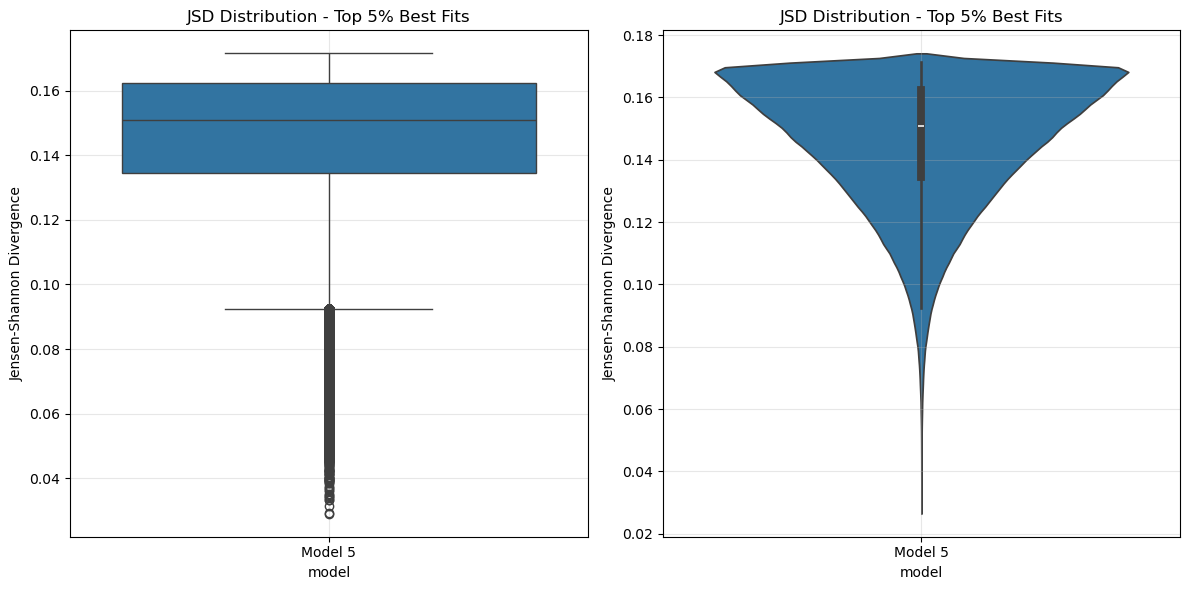


Debug successful! Running full analysis...
Starting complete percentile analysis
Models: [1, 2, 3, 4, 5, 6]
Percentiles: [5, 0.5, 0.05]
Saving top percentile data for models 1-6
Percentiles to save: [5, 0.5, 0.05]%

############################################################
PROCESSING MODEL 1
############################################################
  Loaded 984,900 comparisons for Model 1
  ✓ Saved top 5% (49,245 rows) to model_1_top_5pct.parquet
  ✓ Saved top 0.5% (4,925 rows) to model_1_top_0.5pct.parquet
  ✓ Saved top 0.05% (493 rows) to model_1_top_0.05pct.parquet

############################################################
PROCESSING MODEL 2
############################################################
  Loaded 984,900 comparisons for Model 2
  ✓ Saved top 5% (49,245 rows) to model_2_top_5pct.parquet
  ✓ Saved top 0.5% (4,925 rows) to model_2_top_0.5pct.parquet
  ✓ Saved top 0.05% (493 rows) to model_2_top_0.05pct.parquet

###################################################

C:\Users\Ashwin\AppData\Local\Temp\ipykernel_13932\3313652856.py:215: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.pointplot(data=plot_df, x='percentile', y='jsd', hue='model',



Comparison for Top 5%:
           count    mean     std     min  median     max
model                                                   
Model 1    49245  0.2641  0.0447  0.0923  0.2679  0.3376
Model 2    49245  0.1789  0.0182  0.0601  0.1837  0.2003
Model 3    70350  0.1463  0.0180  0.0417  0.1511  0.1673
Model 4    50652  0.1111  0.0155  0.0220  0.1148  0.1304
Model 5   844200  0.1461  0.0202  0.0291  0.1508  0.1715
Model 6  2917556  0.1362  0.0196  0.0269  0.1408  0.1607

Comparison for Top 0.5%:
          count    mean     std     min  median     max
model                                                  
Model 1    4925  0.1812  0.0187  0.0923  0.1862  0.2030
Model 2    4925  0.1391  0.0131  0.0601  0.1431  0.1537
Model 3    7035  0.1068  0.0123  0.0417  0.1103  0.1207
Model 4    5066  0.0780  0.0099  0.0220  0.0809  0.0892
Model 5   84420  0.1033  0.0122  0.0291  0.1067  0.1172
Model 6  291756  0.0943  0.0118  0.0269  0.0974  0.1080

Comparison for Top 0.05%:
         count    m

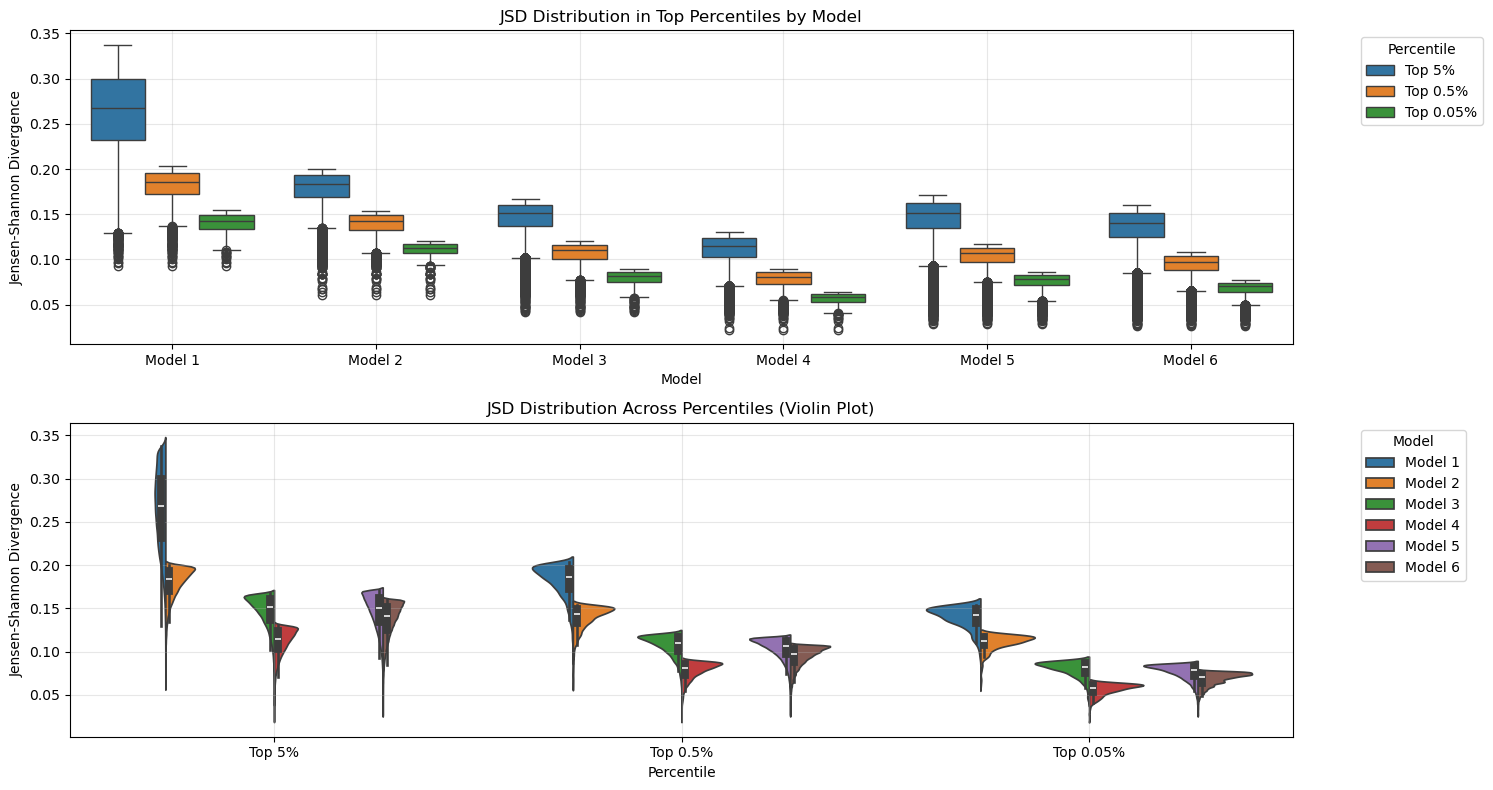

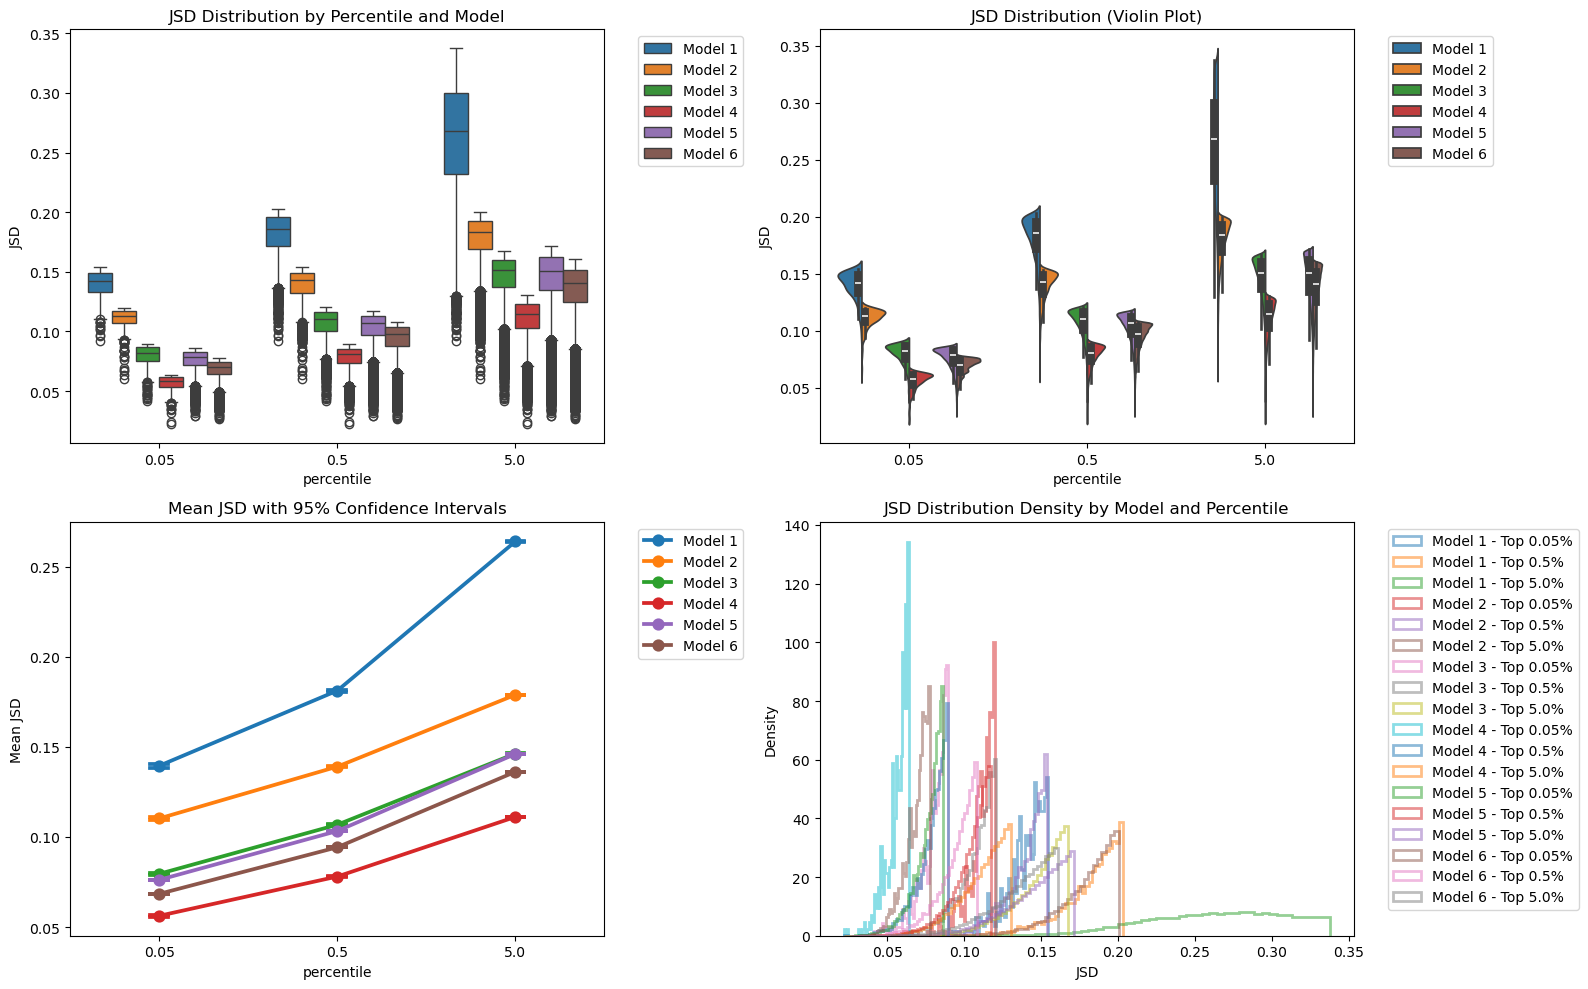

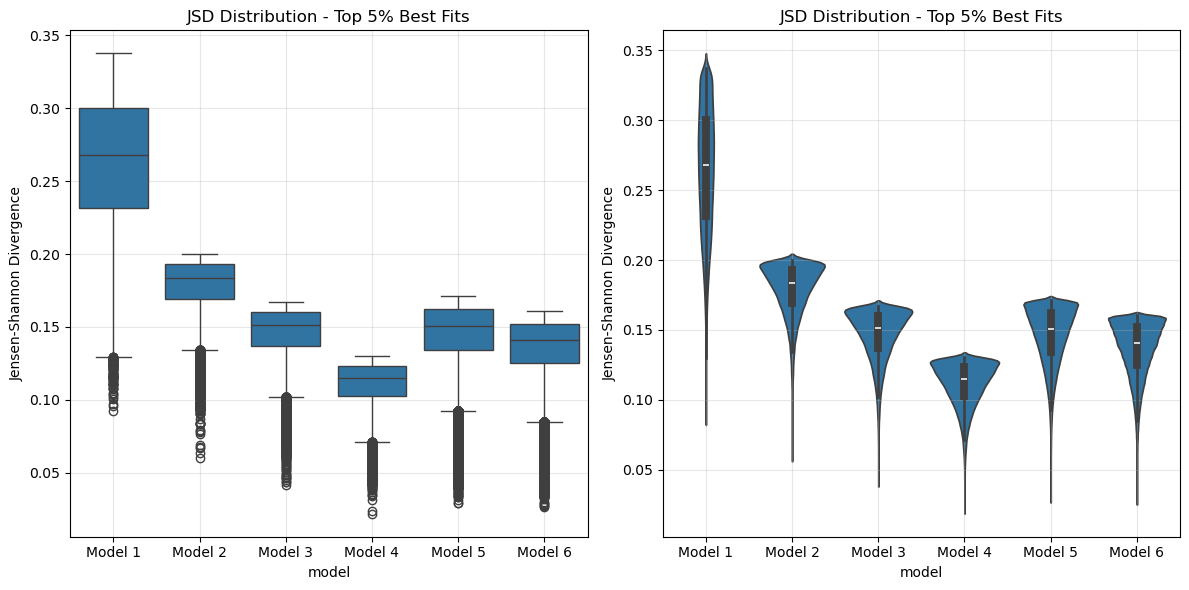

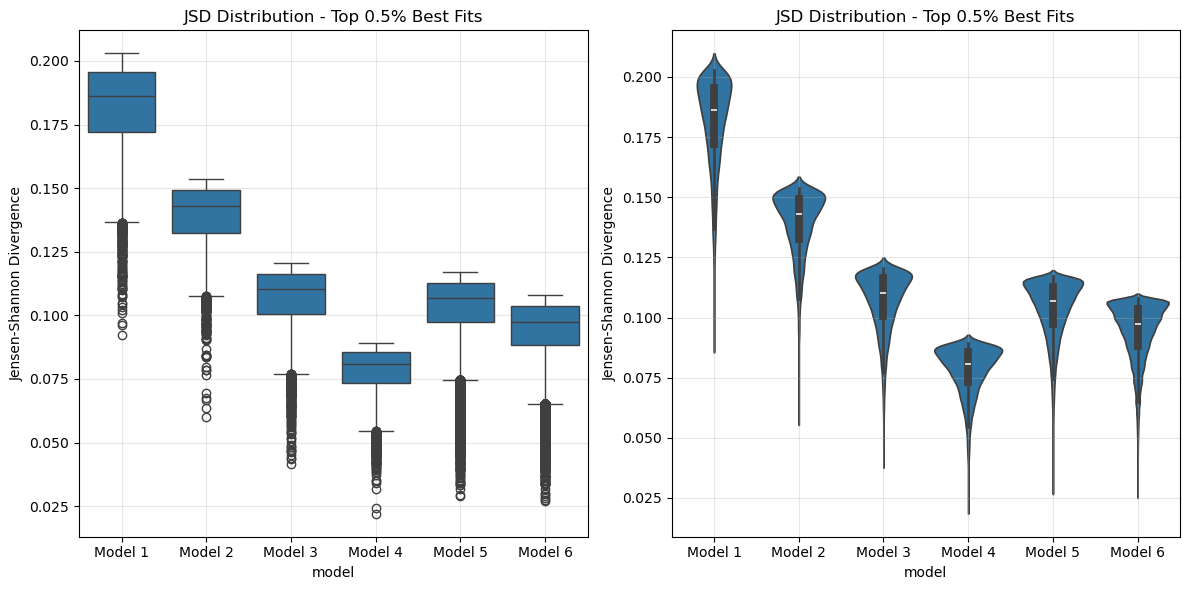

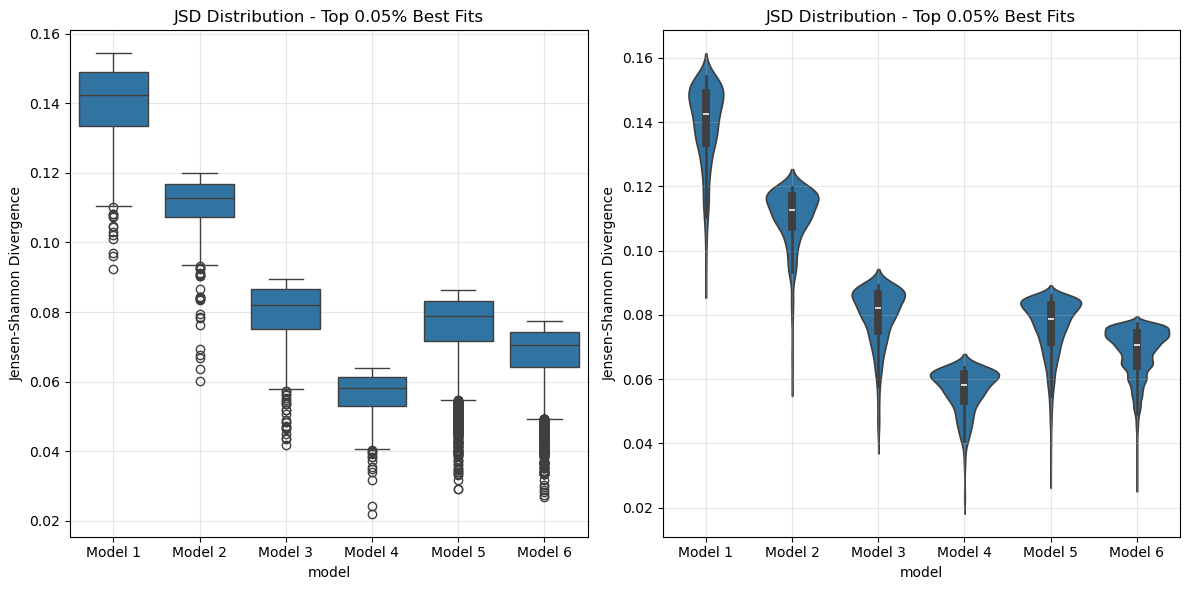

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

def save_top_percentile_data(js_fits_stepwise, percentiles_to_save=[5, 2, 1, 0.5, 0.05], base_save_path='/data/preprocessed/top_percentiles/'):
    """
    Save top percentile data for each model to separate files
    """
    # Create save directory
    os.makedirs(base_save_path, exist_ok=True)
    
    print(f"Saving top percentile data for models 1-6")
    print(f"Percentiles to save: {percentiles_to_save}%")
    
    all_models_results = {}
    
    for model_idx in range(6):  # Models 0-5 representing models 1-6
        model_number = model_idx + 1
        print(f"\n{'#'*60}")
        print(f"PROCESSING MODEL {model_number}")
        print(f"{'#'*60}")
        
        # Load the dataframe for this model
        df = js_fits_stepwise[model_idx].copy()
        print(f"  Loaded {len(df):,} comparisons for Model {model_number}")
        
        model_results = {}
        
        for percentile in percentiles_to_save:
            # Calculate threshold for this percentile
            threshold = df['distance_final'].quantile(percentile / 100)
            
            # Get top percentile data
            top_data = df[df['distance_final'] <= threshold].copy()
            
            # Add percentile information
            top_data['percentile_threshold'] = percentile
            top_data['is_top_percentile'] = True
            
            # Save to file
            filename = f"model_{model_number}_top_{percentile}pct.parquet"
            filepath = os.path.join(base_save_path, filename)
            
            try:
                top_data.to_parquet(filepath)
                print(f"  ✓ Saved top {percentile}% ({len(top_data):,} rows) to {filename}")
            except Exception as e:
                # Fallback to CSV if parquet fails
                csv_filepath = filepath.replace('.parquet', '.csv')
                top_data.to_csv(csv_filepath, index=False)
                print(f"  ✓ Saved top {percentile}% ({len(top_data):,} rows) to {csv_filepath} (CSV)")
            
            model_results[percentile] = {
                'data': top_data,
                'threshold': threshold,
                'count': len(top_data)
            }
        
        all_models_results[model_number] = model_results
    
    # Print summary
    print(f"\n{'#'*60}")
    print("SUMMARY")
    print(f"{'#'*60}")
    
    for model_number in range(1, 7):
        print(f"\nModel {model_number}:")
        for percentile in percentiles_to_save:
            count = all_models_results[model_number][percentile]['count']
            threshold = all_models_results[model_number][percentile]['threshold']
            print(f"  Top {percentile:5.2f}%: {count:>8,} rows (JSD ≤ {threshold:.4f})")
    
    return all_models_results

def load_top_percentile_data(model_numbers, percentiles, base_save_path='/data/preprocessed/top_percentiles/'):
    """
    Load pre-saved top percentile data
    """
    loaded_data = {}
    
    for model_number in model_numbers:
        model_data = {}
        
        for percentile in percentiles:
            # Try parquet first, then CSV
            parquet_path = os.path.join(base_save_path, f"model_{model_number}_top_{percentile}pct.parquet")
            csv_path = os.path.join(base_save_path, f"model_{model_number}_top_{percentile}pct.csv")
            
            if os.path.exists(parquet_path):
                data = pd.read_parquet(parquet_path)
            elif os.path.exists(csv_path):
                data = pd.read_csv(csv_path)
            else:
                print(f"Warning: No data found for Model {model_number}, {percentile}%")
                continue
            
            model_data[percentile] = data
        
        if model_data:  # Only add if we found data
            loaded_data[model_number] = model_data
    
    return loaded_data

def create_percentile_boxplots(loaded_data, percentiles, model_numbers=None, figsize=(15, 8)):
    """
    Create boxplots for multiple percentiles and models
    """
    if model_numbers is None:
        model_numbers = list(loaded_data.keys())
    
    # Prepare data for plotting
    plot_data = []
    
    for model_number in model_numbers:
        if model_number not in loaded_data:
            continue
            
        for percentile in percentiles:
            if percentile not in loaded_data[model_number]:
                continue
                
            data = loaded_data[model_number][percentile]
            
            for jsd_value in data['distance_final']:
                plot_data.append({
                    'model': f'Model {model_number}',
                    'percentile': f'Top {percentile}%',
                    'jsd': jsd_value,
                    'percentile_value': percentile,
                    'model_number': model_number
                })
    
    plot_df = pd.DataFrame(plot_data)
    
    if plot_df.empty:
        print("No data to plot! Check if files were created correctly.")
        return None, None
    
    # Create the boxplot
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=figsize)
    
    # Plot 1: Boxplot by model and percentile
    sns.boxplot(data=plot_df, x='model', y='jsd', hue='percentile', ax=ax1)
    ax1.set_title('JSD Distribution in Top Percentiles by Model')
    ax1.set_ylabel('Jensen-Shannon Divergence')
    ax1.set_xlabel('Model')
    ax1.legend(title='Percentile', bbox_to_anchor=(1.05, 1), loc='upper left')
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Violin plot for better distribution visualization
    sns.violinplot(data=plot_df, x='percentile', y='jsd', hue='model', ax=ax2, split=True)
    ax2.set_title('JSD Distribution Across Percentiles (Violin Plot)')
    ax2.set_ylabel('Jensen-Shannon Divergence')
    ax2.set_xlabel('Percentile')
    ax2.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # Print statistics
    print(f"\n{'#'*60}")
    print("BOXPLOT STATISTICS")
    print(f"{'#'*60}")
    
    stats = plot_df.groupby(['model', 'percentile'])['jsd'].agg(['count', 'mean', 'std', 'min', 'max']).round(4)
    print(stats)
    
    return fig, plot_df

def create_comparison_plots(loaded_data, percentiles, focus_model=None, figsize=(16, 10)):
    """
    Create detailed comparison plots focusing on specific aspects
    """
    # Prepare data
    plot_data = []
    
    for model_number in loaded_data.keys():
        for percentile in percentiles:
            if percentile in loaded_data[model_number]:
                data = loaded_data[model_number][percentile]
                for jsd_value in data['distance_final']:
                    plot_data.append({
                        'model': f'Model {model_number}',
                        'percentile': percentile,
                        'jsd': jsd_value
                    })
    
    plot_df = pd.DataFrame(plot_data)
    
    if plot_df.empty:
        print("No data available for comparison plots")
        return None, None
    
    # Create comprehensive figure
    fig = plt.figure(figsize=figsize)
    
    # 1. Main boxplot
    ax1 = plt.subplot(2, 2, 1)
    sns.boxplot(data=plot_df, x='percentile', y='jsd', hue='model', ax=ax1)
    ax1.set_title('JSD Distribution by Percentile and Model')
    ax1.set_ylabel('JSD')
    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # 2. Violin plot
    ax2 = plt.subplot(2, 2, 2)
    sns.violinplot(data=plot_df, x='percentile', y='jsd', hue='model', ax=ax2, split=True)
    ax2.set_title('JSD Distribution (Violin Plot)')
    ax2.set_ylabel('JSD')
    ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # 3. Point plot with confidence intervals
    ax3 = plt.subplot(2, 2, 3)
    sns.pointplot(data=plot_df, x='percentile', y='jsd', hue='model', 
                  ax=ax3, ci=95, capsize=0.1)
    ax3.set_title('Mean JSD with 95% Confidence Intervals')
    ax3.set_ylabel('Mean JSD')
    ax3.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # 4. Cumulative distribution
    ax4 = plt.subplot(2, 2, 4)
    for model in plot_df['model'].unique():
        model_data = plot_df[plot_df['model'] == model]
        for percentile in sorted(plot_df['percentile'].unique()):
            percentile_data = model_data[model_data['percentile'] == percentile]['jsd']
            if len(percentile_data) > 0:
                ax4.hist(percentile_data, bins=50, alpha=0.5, 
                        label=f'{model} - Top {percentile}%', density=True, histtype='step', linewidth=2)
    
    ax4.set_title('JSD Distribution Density by Model and Percentile')
    ax4.set_xlabel('JSD')
    ax4.set_ylabel('Density')
    ax4.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    
    return fig, plot_df

def create_single_percentile_comparison(loaded_data, percentile, figsize=(12, 6)):
    """
    Create focused comparison for a single percentile across all models
    """
    plot_data = []
    
    for model_number in loaded_data.keys():
        if percentile in loaded_data[model_number]:
            data = loaded_data[model_number][percentile]
            for jsd_value in data['distance_final']:
                plot_data.append({
                    'model': f'Model {model_number}',
                    'jsd': jsd_value
                })
    
    if not plot_data:
        print(f"No data available for percentile {percentile}%")
        return None, None
    
    plot_df = pd.DataFrame(plot_data)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    
    # Boxplot
    sns.boxplot(data=plot_df, x='model', y='jsd', ax=ax1)
    ax1.set_title(f'JSD Distribution - Top {percentile}% Best Fits')
    ax1.set_ylabel('Jensen-Shannon Divergence')
    ax1.grid(True, alpha=0.3)
    
    # Violin plot
    sns.violinplot(data=plot_df, x='model', y='jsd', ax=ax2)
    ax2.set_title(f'JSD Distribution - Top {percentile}% Best Fits')
    ax2.set_ylabel('Jensen-Shannon Divergence')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # Print comparison statistics
    stats = plot_df.groupby('model')['jsd'].agg(['count', 'mean', 'std', 'min', 'median', 'max']).round(4)
    print(f"\nComparison for Top {percentile}%:")
    print(stats)
    
    return fig, plot_df

# Main execution pipeline - FIXED VERSION
def run_complete_percentile_analysis(js_fits_stepwise, percentiles_to_save=[5, 2, 1, 0.5, 0.05], models_to_analyze=None):
    """
    Complete pipeline: save data and create visualizations
    """
    if models_to_analyze is None:
        models_to_analyze = list(range(1, 7))
    
    print(f"Starting complete percentile analysis")
    print(f"Models: {models_to_analyze}")
    print(f"Percentiles: {percentiles_to_save}")
    
    # Step 1: Save top percentile data
    saved_data = save_top_percentile_data(js_fits_stepwise, percentiles_to_save)
    
    # Step 2: Load the data back (to demonstrate the file-based approach)
    loaded_data = load_top_percentile_data(models_to_analyze, percentiles_to_save)
    
    # Step 3: Create comprehensive visualizations
    print(f"\n{'#'*60}")
    print("CREATING VISUALIZATIONS")
    print(f"{'#'*60}")
    
    results = {
        'saved_data': saved_data,
        'loaded_data': loaded_data,
        'figures': {},
        'plot_data': {}
    }
    
    # Main boxplots
    fig1, plot_df1 = create_percentile_boxplots(loaded_data, percentiles_to_save, models_to_analyze)
    if fig1 is not None:
        results['figures']['main_boxplots'] = fig1
        results['plot_data']['main'] = plot_df1
    
    # Detailed comparison
    fig2, plot_df2 = create_comparison_plots(loaded_data, percentiles_to_save)
    if fig2 is not None:
        results['figures']['comparison_plots'] = fig2
        results['plot_data']['comparison'] = plot_df2
    
    # Individual percentile comparisons
    individual_figs = {}
    for percentile in percentiles_to_save:
        fig, df = create_single_percentile_comparison(loaded_data, percentile)
        if fig is not None:
            individual_figs[percentile] = fig
    
    results['figures']['individual_percentiles'] = individual_figs
    
    return results

# Let's first test with a simpler approach to debug
def debug_save_and_plot(js_fits_stepwise, model_numbers=[5], percentiles=[5, 1]):
    """
    Simple debug function to test the pipeline
    """
    print("DEBUG MODE: Testing with limited data")
    
    # Save data
    saved_data = save_top_percentile_data(js_fits_stepwise, percentiles_to_save=percentiles)
    
    # Load data
    loaded_data = load_top_percentile_data(model_numbers, percentiles)
    
    print(f"\nLoaded data keys: {loaded_data.keys()}")
    for model in loaded_data:
        print(f"Model {model} has percentiles: {list(loaded_data[model].keys())}")
    
    # Try to create a simple plot
    if loaded_data:
        fig, df = create_single_percentile_comparison(loaded_data, percentiles[0])
        if fig is not None:
            plt.show()
        else:
            print("Could not create plot - check if data was saved correctly")
    
    return loaded_data

# Run debug first to see what's happening
debug_data = debug_save_and_plot(js_fits_stepwise, model_numbers=[5], percentiles=[5, 1])

# If debug works, then run the full analysis
if debug_data:
    print("\nDebug successful! Running full analysis...")
    results = run_complete_percentile_analysis(
        js_fits_stepwise, 
        percentiles_to_save=[5, 0.5, 0.05],
        models_to_analyze=[1, 2, 3, 4, 5, 6]
    )
else:
    print("Debug failed - check the file paths and data structure")

## Analyzing improved sims only

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

def save_improved_top_percentile_data(js_fits_stepwise, percentiles_to_save=[5, 2, 1, 0.5, 0.05], base_save_path='/data/preprocessed/improved_top_percentiles/'):
    """
    Save top percentile data for each model, filtering only improved simulations (distance_final < distance_initial)
    """
    # Create save directory
    os.makedirs(base_save_path, exist_ok=True)
    
    print(f"Saving IMPROVED top percentile data for models 1-6")
    print(f"Percentiles to save: {percentiles_to_save}%")
    print(f"Filter: Only simulations where distance_final < distance_initial")
    
    all_models_results = {}
    
    for model_idx in range(6):  # Models 0-5 representing models 1-6
        model_number = model_idx + 1
        print(f"\n{'#'*60}")
        print(f"PROCESSING MODEL {model_number}")
        print(f"{'#'*60}")
        
        # Load the dataframe for this model
        df = js_fits_stepwise[model_idx].copy()
        print(f"  Loaded {len(df):,} total comparisons")
        
        # Filter for improved simulations only
        improved_df = df[df['distance_final'] < df['distance_initial']].copy()
        print(f"  Found {len(improved_df):,} improved simulations ({len(improved_df)/len(df)*100:.1f}%)")
        
        if len(improved_df) == 0:
            print(f"  ⚠️  No improved simulations found for Model {model_number}")
            continue
        
        model_results = {}
        
        for percentile in percentiles_to_save:
            # Calculate threshold for this percentile (within improved simulations)
            threshold = improved_df['distance_final'].quantile(percentile / 100)
            
            # Get top percentile data from improved simulations
            top_data = improved_df[improved_df['distance_final'] <= threshold].copy()
            
            # Add metadata
            top_data['percentile_threshold'] = percentile
            top_data['is_top_percentile'] = True
            top_data['improvement_amount'] = top_data['distance_initial'] - top_data['distance_final']
            
            # Save to file
            filename = f"improved_model_{model_number}_top_{percentile}pct.parquet"
            filepath = os.path.join(base_save_path, filename)
            
            try:
                top_data.to_parquet(filepath)
                print(f"  ✓ Saved top {percentile}% ({len(top_data):,} rows) to {filename}")
            except Exception as e:
                # Fallback to CSV if parquet fails
                csv_filepath = filepath.replace('.parquet', '.csv')
                top_data.to_csv(csv_filepath, index=False)
                print(f"  ✓ Saved top {percentile}% ({len(top_data):,} rows) to {csv_filepath} (CSV)")
            
            model_results[percentile] = {
                'data': top_data,
                'threshold': threshold,
                'count': len(top_data),
                'improvement_count': len(improved_df)
            }
        
        all_models_results[model_number] = model_results
    
    # Print summary
    print(f"\n{'#'*60}")
    print("SUMMARY - IMPROVED SIMULATIONS ONLY")
    print(f"{'#'*60}")
    
    for model_number in range(1, 7):
        if model_number in all_models_results:
            print(f"\nModel {model_number}:")
            total_improved = all_models_results[model_number][percentiles_to_save[0]]['improvement_count']
            print(f"  Total improved simulations: {total_improved:,}")
            
            for percentile in percentiles_to_save:
                if percentile in all_models_results[model_number]:
                    count = all_models_results[model_number][percentile]['count']
                    threshold = all_models_results[model_number][percentile]['threshold']
                    print(f"  Top {percentile:5.2f}%: {count:>8,} rows (JSD ≤ {threshold:.4f})")
        else:
            print(f"\nModel {model_number}: No improved simulations found")
    
    return all_models_results

def load_improved_top_percentile_data(model_numbers, percentiles, base_save_path='/data/preprocessed/improved_top_percentiles/'):
    """
    Load pre-saved improved top percentile data
    """
    loaded_data = {}
    
    for model_number in model_numbers:
        model_data = {}
        
        for percentile in percentiles:
            # Try parquet first, then CSV
            parquet_path = os.path.join(base_save_path, f"improved_model_{model_number}_top_{percentile}pct.parquet")
            csv_path = os.path.join(base_save_path, f"improved_model_{model_number}_top_{percentile}pct.csv")
            
            if os.path.exists(parquet_path):
                data = pd.read_parquet(parquet_path)
            elif os.path.exists(csv_path):
                data = pd.read_csv(csv_path)
            else:
                print(f"Warning: No improved data found for Model {model_number}, {percentile}%")
                continue
            
            model_data[percentile] = data
        
        if model_data:  # Only add if we found data
            loaded_data[model_number] = model_data
    
    return loaded_data

# Execute the saving process
print("SAVING IMPROVED TOP PERCENTILE DATA...")
saved_improved_data = save_improved_top_percentile_data(
    js_fits_stepwise, 
    percentiles_to_save=[5, 2, 1, 0.5, 0.05]
)

SAVING IMPROVED TOP PERCENTILE DATA...
Saving IMPROVED top percentile data for models 1-6
Percentiles to save: [5, 2, 1, 0.5, 0.05]%
Filter: Only simulations where distance_final < distance_initial

############################################################
PROCESSING MODEL 1
############################################################
  Loaded 984,900 total comparisons
  Found 18,466 improved simulations (1.9%)
  ✓ Saved top 5% (924 rows) to improved_model_1_top_5pct.parquet
  ✓ Saved top 2% (370 rows) to improved_model_1_top_2pct.parquet
  ✓ Saved top 1% (185 rows) to improved_model_1_top_1pct.parquet
  ✓ Saved top 0.5% (93 rows) to improved_model_1_top_0.5pct.parquet
  ✓ Saved top 0.05% (10 rows) to improved_model_1_top_0.05pct.parquet

############################################################
PROCESSING MODEL 2
############################################################
  Loaded 984,900 total comparisons
  Found 160,926 improved simulations (16.3%)
  ✓ Saved top 5% (8,047 row

Creating individual plots for each percentile...


C:\Users\Ashwin\AppData\Local\Temp\ipykernel_29852\298649656.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='model', y='jsd', ax=ax1, palette='viridis')
C:\Users\Ashwin\AppData\Local\Temp\ipykernel_29852\298649656.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='model', y='improvement', ax=ax2, palette='plasma')



############################################################
STATISTICS - Top 5% Improved Simulations
############################################################
            jsd                                         improvement          \
          count    mean     std     min  median     max        mean     std   
model                                                                         
Model 1     924  0.1585  0.0165  0.0923  0.1627  0.1784      0.0179  0.0149   
Model 2    8047  0.1535  0.0148  0.0601  0.1574  0.1703      0.0442  0.0456   
Model 3   28453  0.1308  0.0162  0.0417  0.1351  0.1498      0.0563  0.0391   
Model 4   12373  0.0931  0.0122  0.0339  0.0962  0.1076      0.0429  0.0439   
Model 5  114211  0.1090  0.0135  0.0291  0.1124  0.1249      0.0696  0.0538   
Model 6  442783  0.1010  0.0131  0.0269  0.1044  0.1168      0.0780  0.0535   

                      
         min     max  
model                 
Model 1  0.0  0.0729  
Model 2  0.0  0.2348  
Model 3  

C:\Users\Ashwin\AppData\Local\Temp\ipykernel_29852\298649656.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='model', y='jsd', ax=ax1, palette='viridis')
C:\Users\Ashwin\AppData\Local\Temp\ipykernel_29852\298649656.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='model', y='improvement', ax=ax2, palette='plasma')



############################################################
STATISTICS - Top 2% Improved Simulations
############################################################
            jsd                                         improvement          \
          count    mean     std     min  median     max        mean     std   
model                                                                         
Model 1     370  0.1420  0.0133  0.0923  0.1458  0.1583      0.0206  0.0163   
Model 2    3219  0.1392  0.0134  0.0601  0.1433  0.1537      0.0485  0.0488   
Model 3   11382  0.1148  0.0138  0.0417  0.1185  0.1309      0.0670  0.0414   
Model 4    4949  0.0811  0.0102  0.0339  0.0838  0.0929      0.0444  0.0466   
Model 5   45685  0.0958  0.0115  0.0291  0.0989  0.1089      0.0775  0.0557   
Model 6  177126  0.0880  0.0109  0.0269  0.0909  0.1007      0.0882  0.0543   

                         
            min     max  
model                    
Model 1  0.0001  0.0729  
Model 2  0.0000  0.2

...

C:\Users\Ashwin\AppData\Local\Temp\ipykernel_29852\298649656.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='model', y='jsd', ax=ax1, palette='viridis')
C:\Users\Ashwin\AppData\Local\Temp\ipykernel_29852\298649656.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='model', y='improvement', ax=ax2, palette='plasma')



############################################################
STATISTICS - Top 0.5% Improved Simulations
############################################################
           jsd                                         improvement          \
         count    mean     std     min  median     max        mean     std   
model                                                                        
Model 1     93  0.1231  0.0108  0.0923  0.1273  0.1352      0.0197  0.0142   
Model 2    805  0.1202  0.0117  0.0601  0.1234  0.1333      0.0461  0.0521   
Model 3   2846  0.0952  0.0110  0.0417  0.0980  0.1078      0.0813  0.0440   
Model 4   1238  0.0664  0.0081  0.0339  0.0683  0.0759      0.0447  0.0508   
Model 5  11422  0.0794  0.0094  0.0291  0.0821  0.0900      0.0907  0.0560   
Model 6  44320  0.0724  0.0082  0.0269  0.0744  0.0821      0.0991  0.0532   

                         
            min     max  
model                    
Model 1  0.0004  0.0600  
Model 2  0.0000  0.1947  
M

C:\Users\Ashwin\AppData\Local\Temp\ipykernel_29852\298649656.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='model', y='jsd', ax=ax1, palette='viridis')
C:\Users\Ashwin\AppData\Local\Temp\ipykernel_29852\298649656.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='model', y='improvement', ax=ax2, palette='plasma')



############################################################
STATISTICS - Top 0.05% Improved Simulations
############################################################
          jsd                                         improvement          \
        count    mean     std     min  median     max        mean     std   
model                                                                       
Model 1    10  0.1023  0.0054  0.0923  0.1037  0.1081      0.0255  0.0158   
Model 2    81  0.0946  0.0104  0.0601  0.0970  0.1055      0.0297  0.0374   
Model 3   285  0.0710  0.0083  0.0417  0.0732  0.0798      0.0942  0.0443   
Model 4   124  0.0484  0.0049  0.0339  0.0494  0.0547      0.0311  0.0428   
Model 5  1143  0.0585  0.0067  0.0291  0.0603  0.0661      0.1099  0.0551   
Model 6  4428  0.0546  0.0048  0.0269  0.0555  0.0602      0.1100  0.0507   

                         
            min     max  
model                    
Model 1  0.0033  0.0472  
Model 2  0.0001  0.1388  
Model 3  

C:\Users\Ashwin\AppData\Local\Temp\ipykernel_29852\298649656.py:112: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='model', y='jsd', ax=ax, palette='Set2')
C:\Users\Ashwin\AppData\Local\Temp\ipykernel_29852\298649656.py:112: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='model', y='jsd', ax=ax, palette='Set2')
C:\Users\Ashwin\AppData\Local\Temp\ipykernel_29852\298649656.py:112: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='model', y='jsd', ax=ax, palette='Set2')
C:\Users\Ashwin\AppData\Local\T

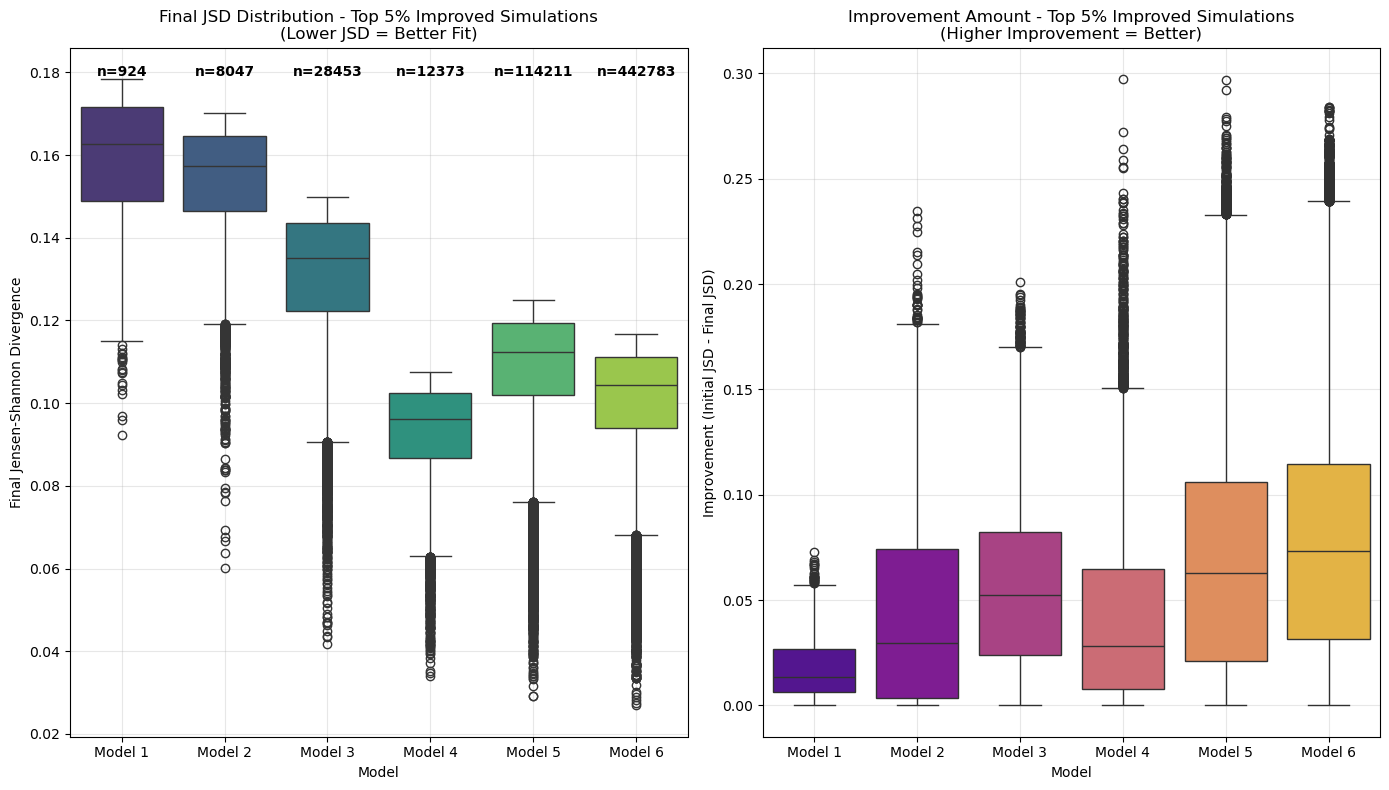

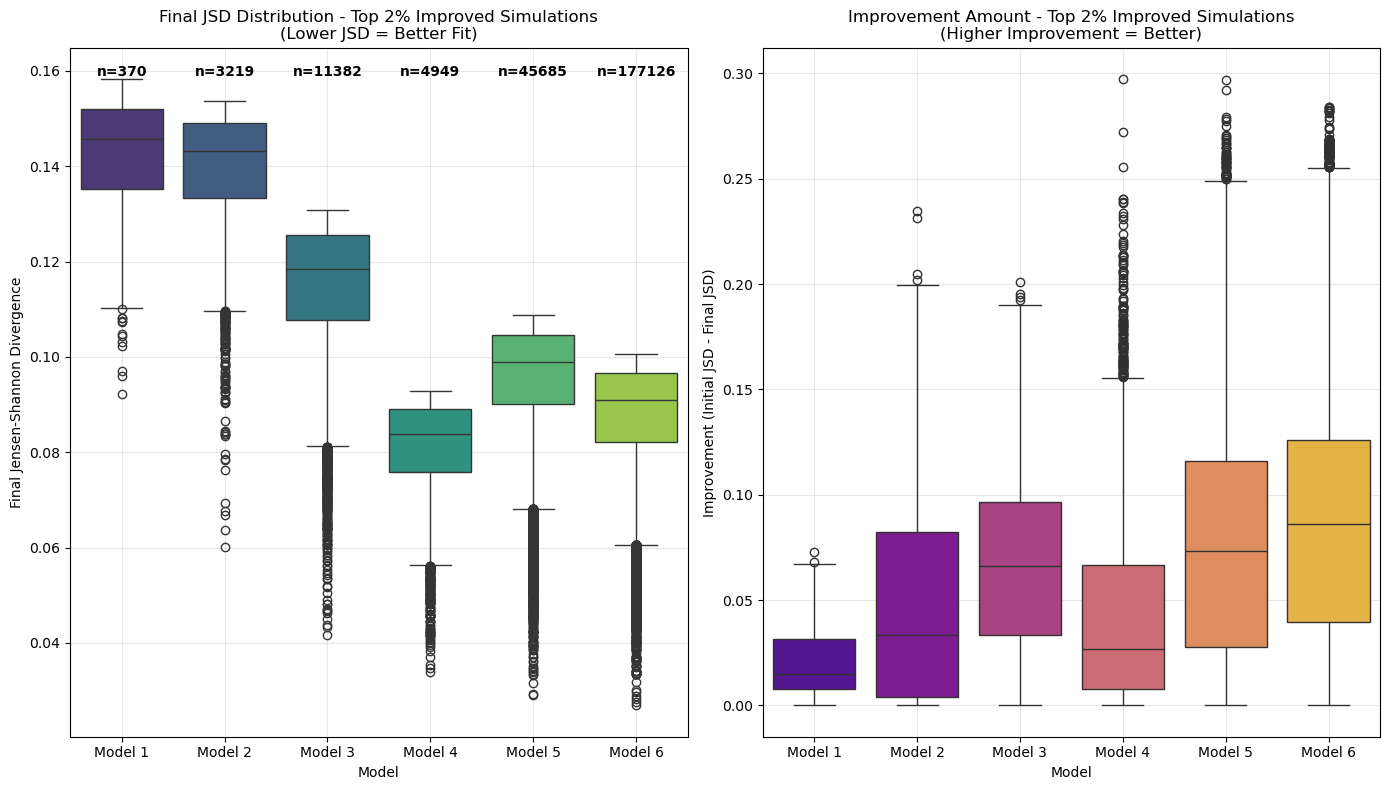

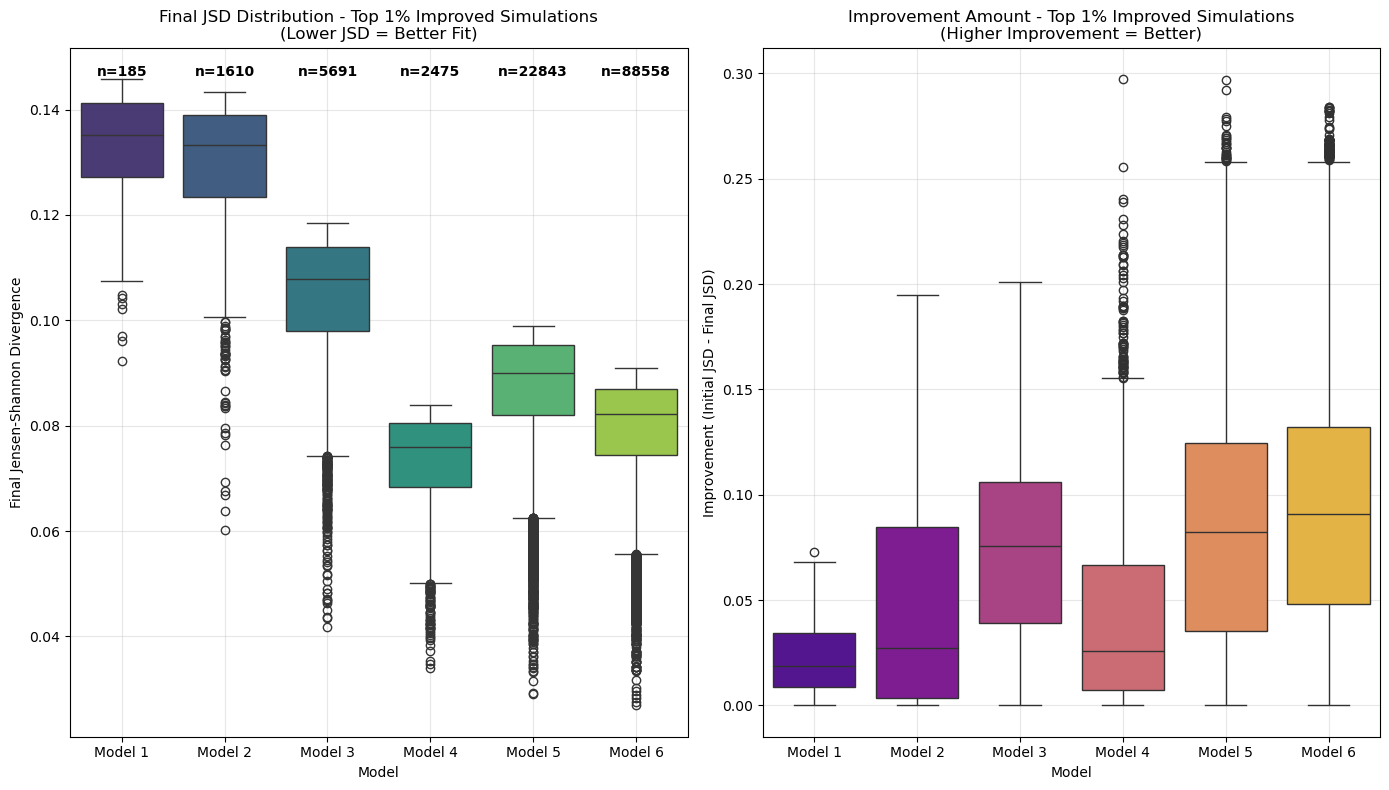

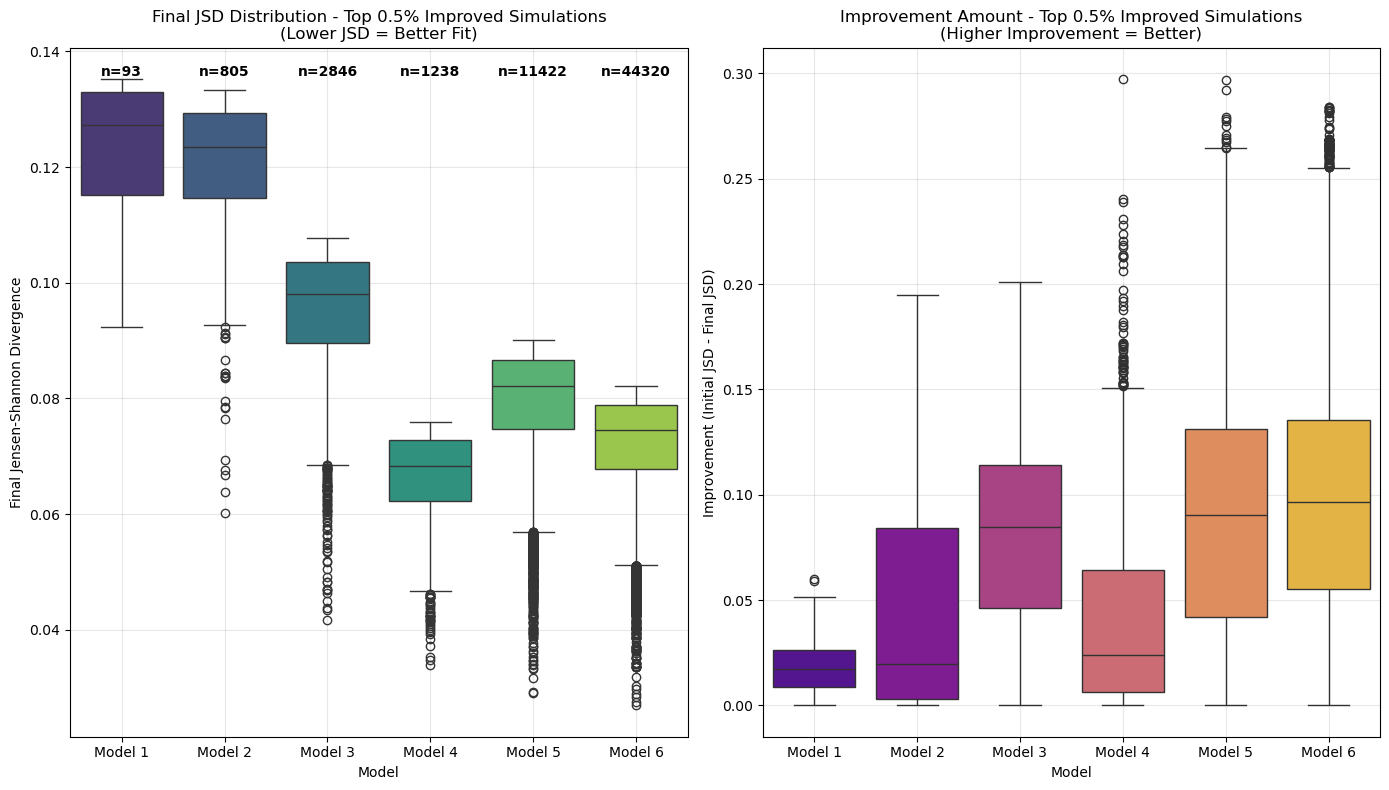

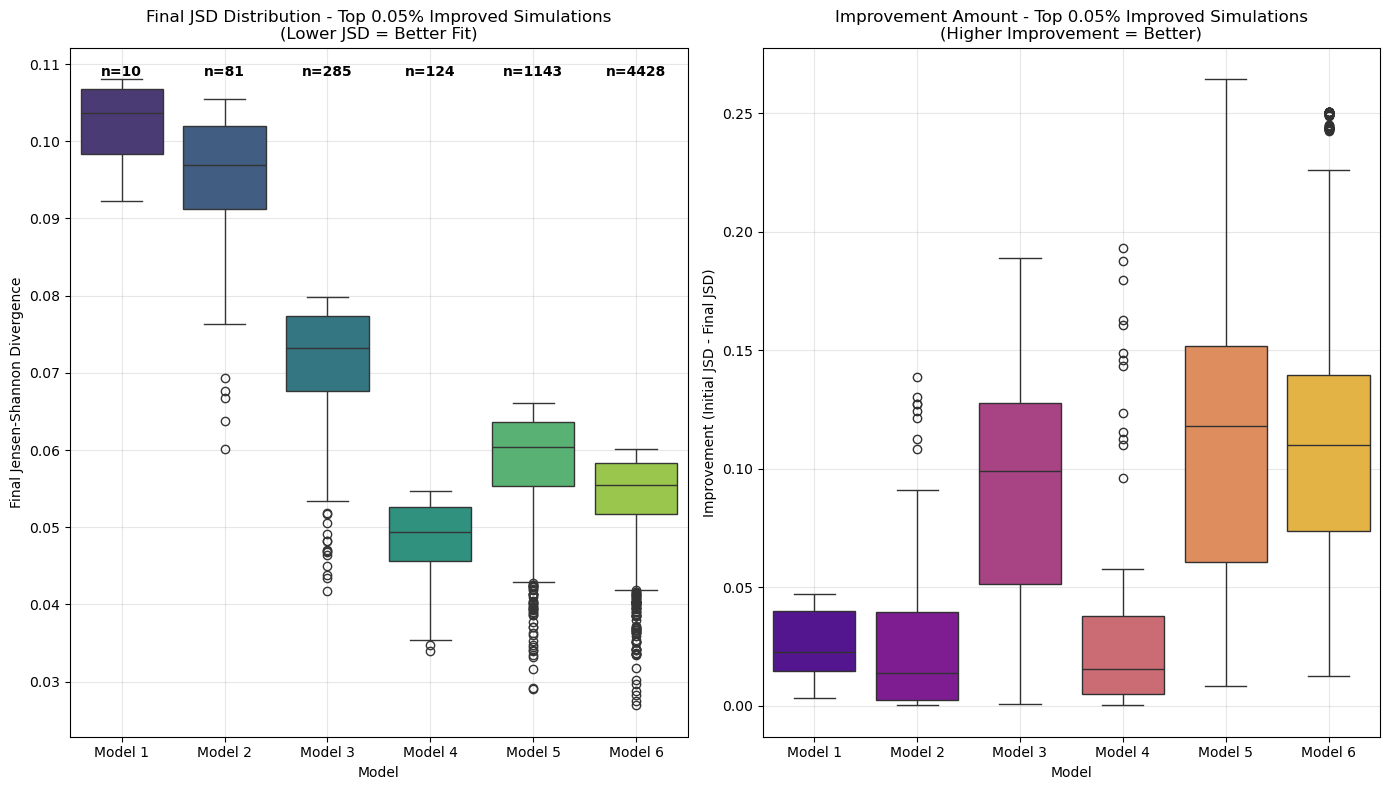

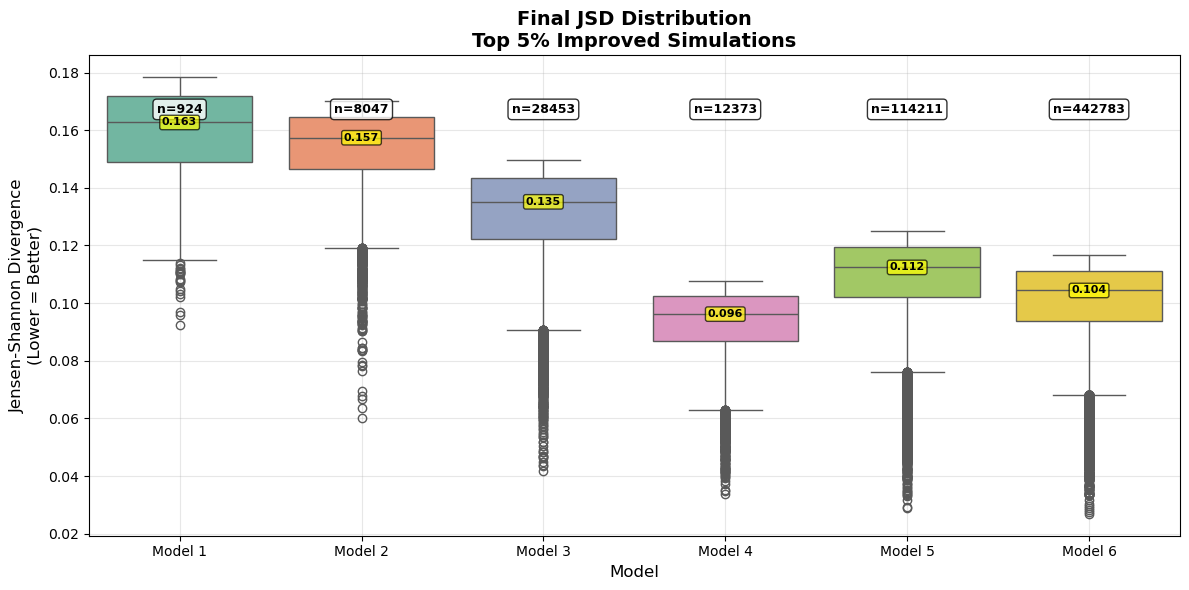

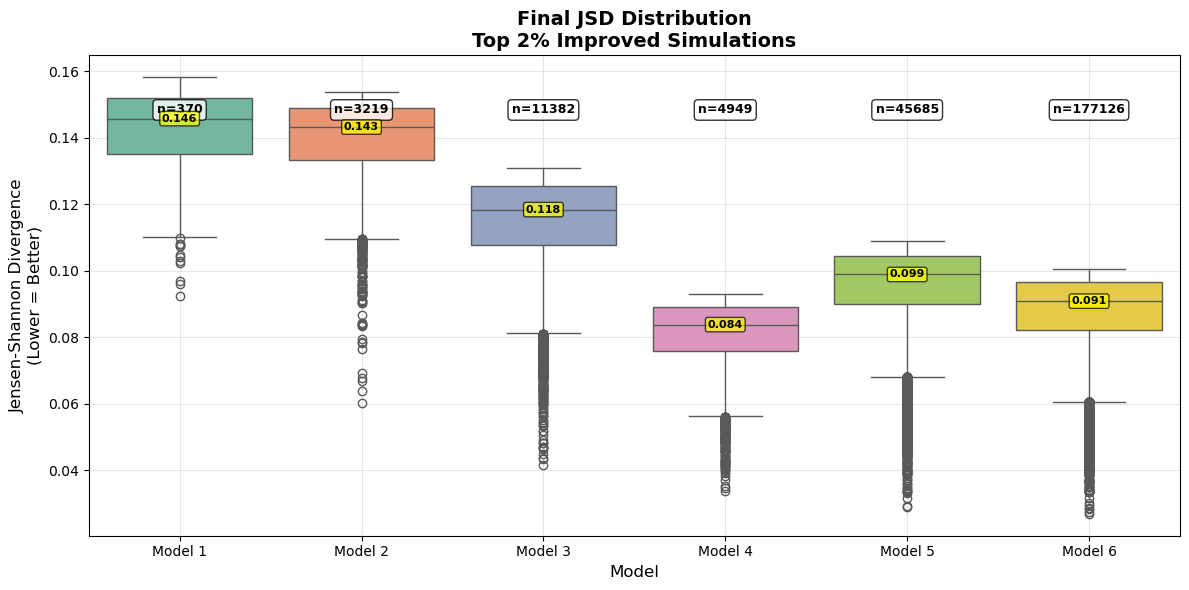

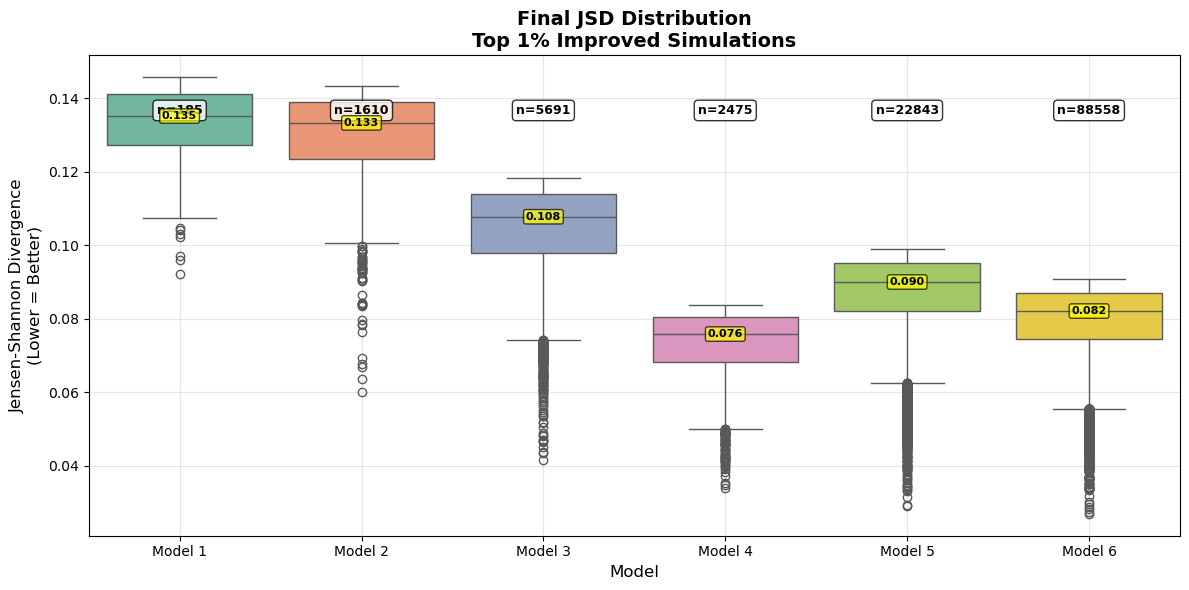

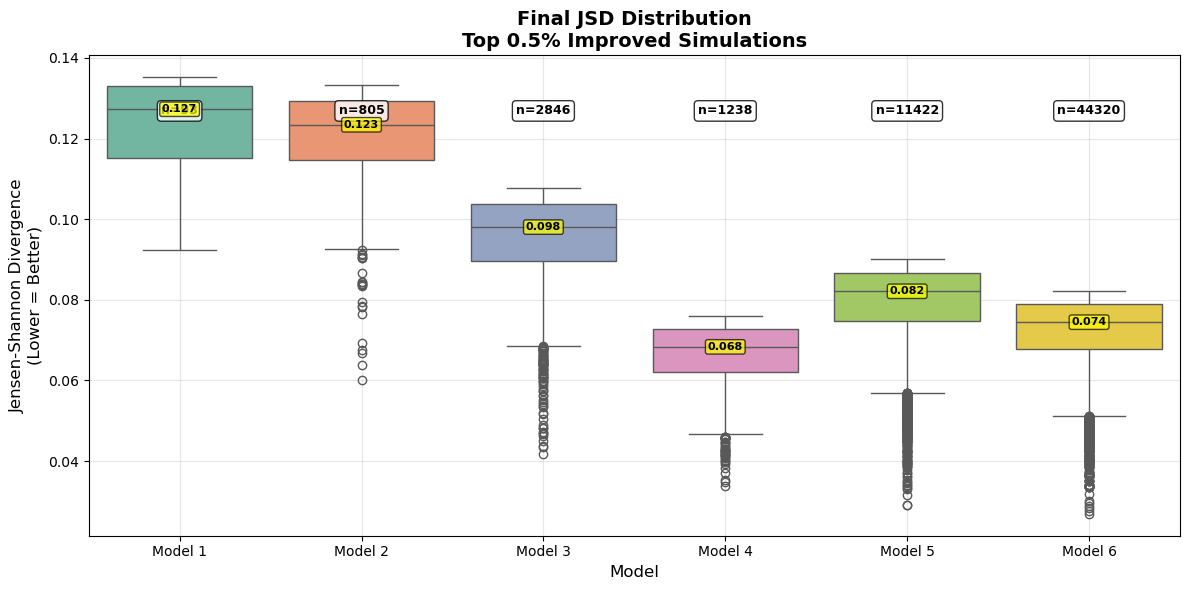

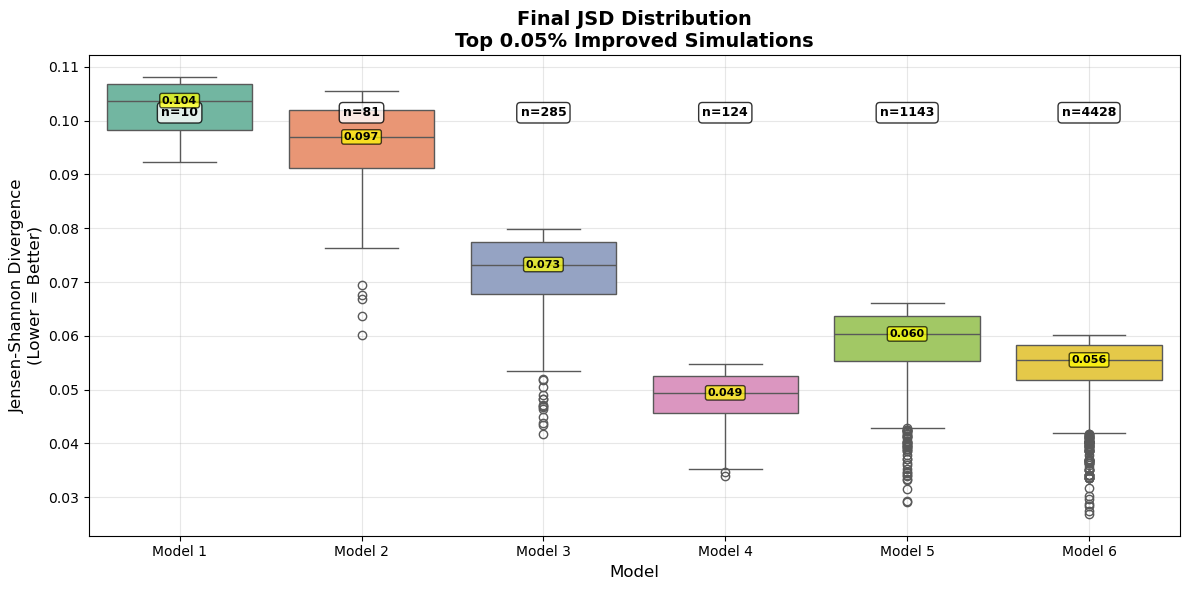

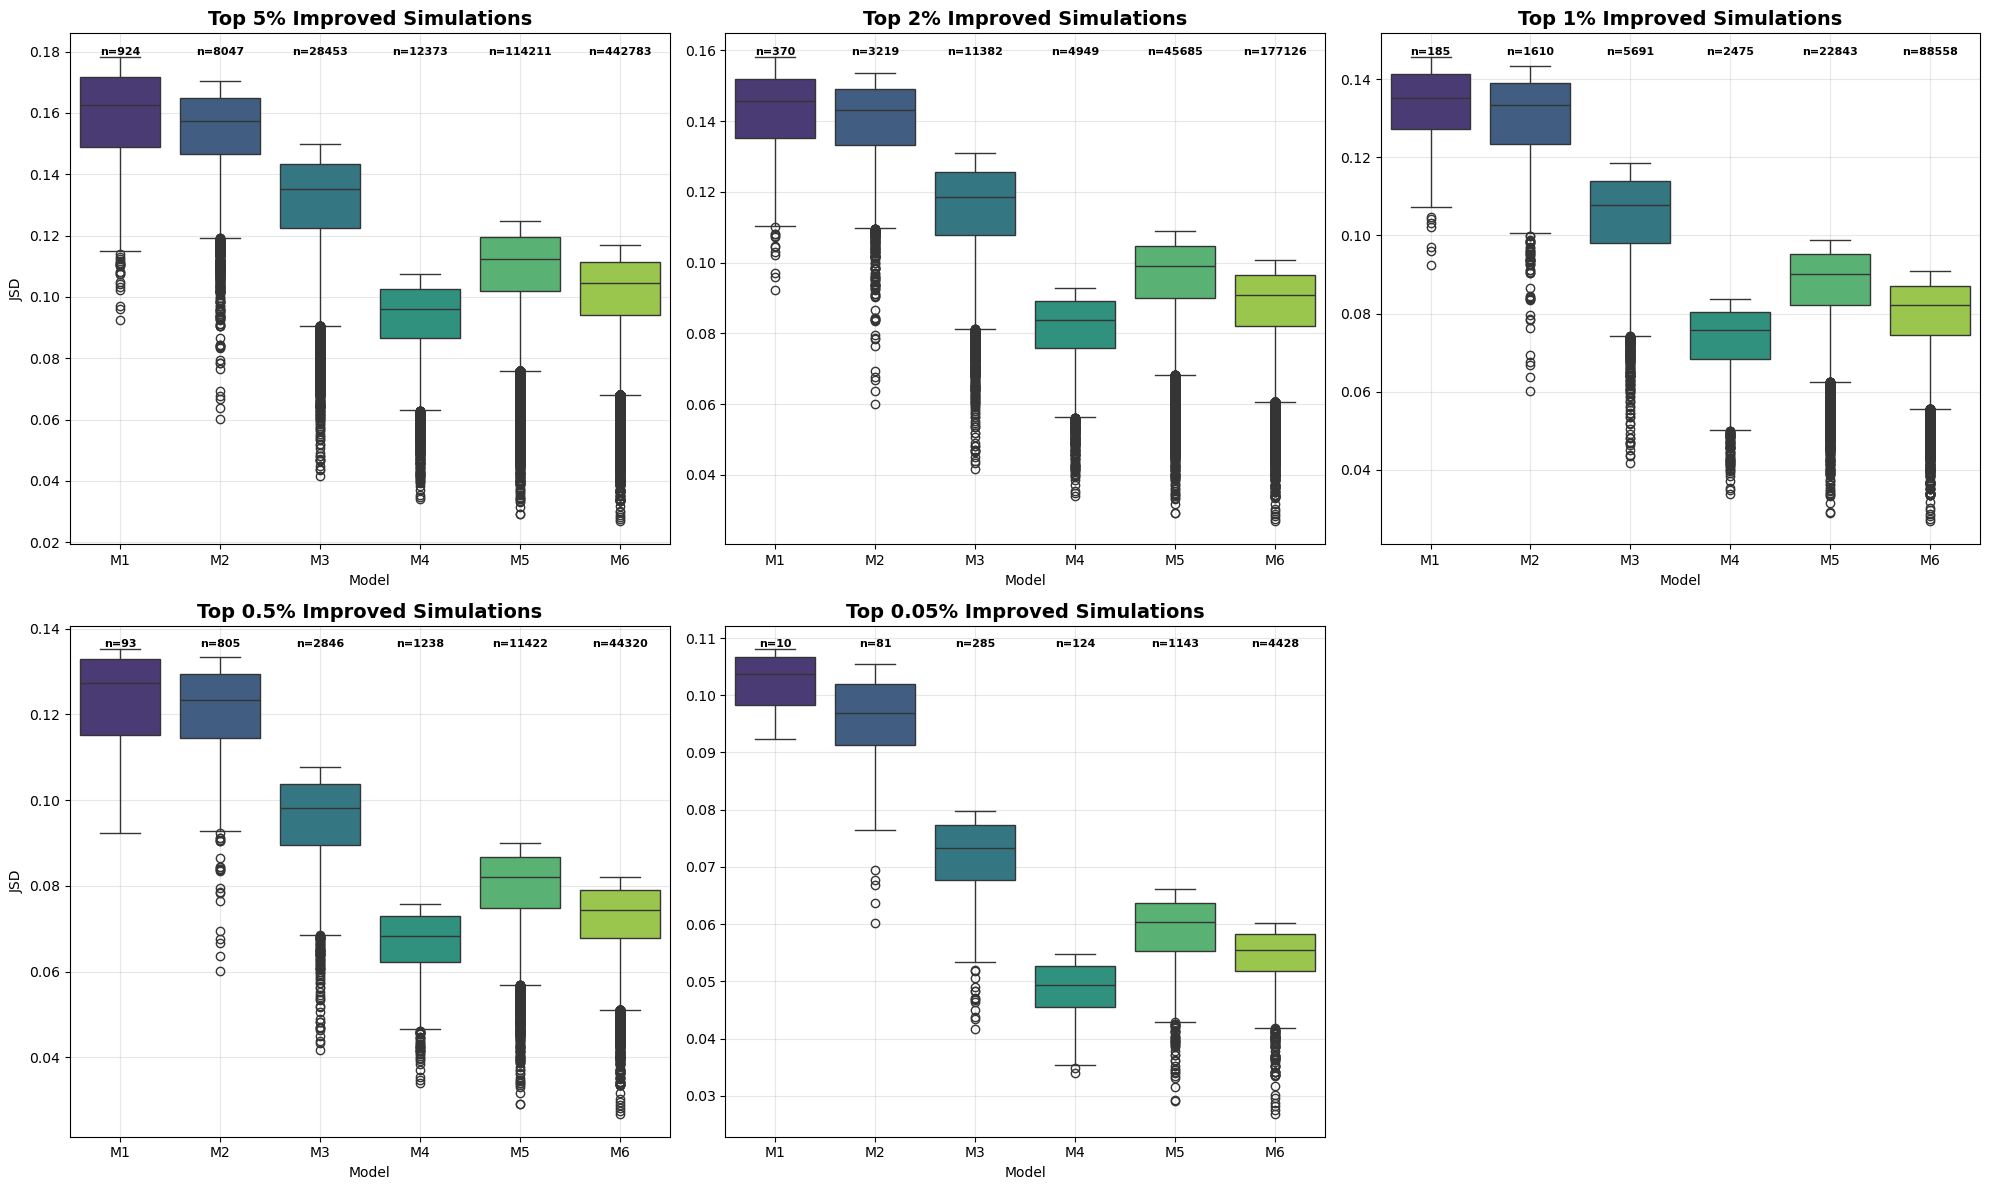

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

def create_percentile_comparison_plots(loaded_data, percentiles, models_to_plot=None, figsize=(14, 8)):
    """
    Create one plot per percentile, with all models shown side by side as boxplots
    """
    if models_to_plot is None:
        models_to_plot = list(loaded_data.keys())
    
    # Create one figure per percentile
    figures = {}
    
    for percentile in percentiles:
        # Prepare data for this specific percentile across all models
        plot_data = []
        
        for model_number in models_to_plot:
            if model_number in loaded_data and percentile in loaded_data[model_number]:
                data = loaded_data[model_number][percentile]
                
                for _, row in data.iterrows():
                    plot_data.append({
                        'model': f'Model {model_number}',
                        'jsd': row['distance_final'],
                        'improvement': row.get('improvement_amount', row['distance_initial'] - row['distance_final'])
                    })
        
        if not plot_data:
            print(f"No data available for percentile {percentile}%")
            continue
        
        plot_df = pd.DataFrame(plot_data)
        
        # Create the plot for this percentile
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
        
        # Plot 1: Final JSD distribution
        sns.boxplot(data=plot_df, x='model', y='jsd', ax=ax1, palette='viridis')
        ax1.set_title(f'Final JSD Distribution - Top {percentile}% Improved Simulations\n(Lower JSD = Better Fit)')
        ax1.set_ylabel('Final Jensen-Shannon Divergence')
        ax1.set_xlabel('Model')
        ax1.grid(True, alpha=0.3)
        
        # Add value counts on top of boxes
        for i, model in enumerate(plot_df['model'].unique()):
            count = len(plot_df[plot_df['model'] == model])
            ax1.text(i, plot_df['jsd'].max(), f'n={count}', 
                    ha='center', va='bottom', fontweight='bold', fontsize=10)
        
        # Plot 2: Improvement amount distribution
        sns.boxplot(data=plot_df, x='model', y='improvement', ax=ax2, palette='plasma')
        ax2.set_title(f'Improvement Amount - Top {percentile}% Improved Simulations\n(Higher Improvement = Better)')
        ax2.set_ylabel('Improvement (Initial JSD - Final JSD)')
        ax2.set_xlabel('Model')
        ax2.grid(True, alpha=0.3)
        
        plt.tight_layout()
        
        # Store the figure
        figures[percentile] = fig
        
        # Print statistics for this percentile
        print(f"\n{'#'*60}")
        print(f"STATISTICS - Top {percentile}% Improved Simulations")
        print(f"{'#'*60}")
        
        stats = plot_df.groupby('model').agg({
            'jsd': ['count', 'mean', 'std', 'min', 'median', 'max'],
            'improvement': ['mean', 'std', 'min', 'max']
        }).round(4)
        
        print(stats)
    
    return figures

def create_compact_percentile_plots(loaded_data, percentiles, models_to_plot=None, figsize=(12, 6)):
    """
    Create compact plots showing only final JSD for each percentile
    """
    if models_to_plot is None:
        models_to_plot = list(loaded_data.keys())
    
    figures = {}
    
    for percentile in percentiles:
        # Prepare data for this percentile
        plot_data = []
        
        for model_number in models_to_plot:
            if model_number in loaded_data and percentile in loaded_data[model_number]:
                data = loaded_data[model_number][percentile]
                
                for _, row in data.iterrows():
                    plot_data.append({
                        'model': f'Model {model_number}',
                        'jsd': row['distance_final']
                    })
        
        if not plot_data:
            continue
        
        plot_df = pd.DataFrame(plot_data)
        
        # Create compact plot
        fig, ax = plt.subplots(figsize=figsize)
        
        # Boxplot for all models
        sns.boxplot(data=plot_df, x='model', y='jsd', ax=ax, palette='Set2')
        ax.set_title(f'Final JSD Distribution\nTop {percentile}% Improved Simulations', fontsize=14, fontweight='bold')
        ax.set_ylabel('Jensen-Shannon Divergence\n(Lower = Better)', fontsize=12)
        ax.set_xlabel('Model', fontsize=12)
        ax.grid(True, alpha=0.3)
        
        # Add value counts and median values
        for i, model in enumerate(plot_df['model'].unique()):
            model_data = plot_df[plot_df['model'] == model]
            count = len(model_data)
            median_jsd = model_data['jsd'].median()
            
            # Count above the box
            ax.text(i, plot_df['jsd'].max() * 0.95, f'n={count}', 
                    ha='center', va='top', fontweight='bold', fontsize=9,
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
            
            # Median value inside the plot area
            ax.text(i, median_jsd, f'{median_jsd:.3f}', 
                    ha='center', va='center', fontweight='bold', fontsize=8,
                    bbox=dict(boxstyle="round,pad=0.2", facecolor="yellow", alpha=0.7))
        
        plt.tight_layout()
        figures[percentile] = fig
    
    return figures

def create_percentile_grid_plot(loaded_data, percentiles, models_to_plot=None, figsize=(20, 12)):
    """
    Create a grid of subplots - one subplot per percentile
    """
    if models_to_plot is None:
        models_to_plot = list(loaded_data.keys())
    
    n_percentiles = len(percentiles)
    n_cols = min(3, n_percentiles)  # Maximum 3 columns
    n_rows = (n_percentiles + n_cols - 1) // n_cols  # Ceiling division
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    
    # Handle case with single row/column
    if n_rows == 1 and n_cols == 1:
        axes = np.array([axes])
    elif n_rows == 1:
        axes = axes.reshape(1, -1)
    elif n_cols == 1:
        axes = axes.reshape(-1, 1)
    
    # Flatten axes for easy iteration
    axes_flat = axes.flatten()
    
    for idx, percentile in enumerate(percentiles):
        if idx >= len(axes_flat):
            break
            
        ax = axes_flat[idx]
        
        # Prepare data for this percentile
        plot_data = []
        for model_number in models_to_plot:
            if model_number in loaded_data and percentile in loaded_data[model_number]:
                data = loaded_data[model_number][percentile]
                for _, row in data.iterrows():
                    plot_data.append({
                        'model': f'M{model_number}',
                        'jsd': row['distance_final']
                    })
        
        if not plot_data:
            ax.text(0.5, 0.5, f'No data\n{percentile}%', 
                   ha='center', va='center', transform=ax.transAxes, fontsize=12)
            ax.set_title(f'Top {percentile}%', fontsize=14)
            continue
        
        plot_df = pd.DataFrame(plot_data)
        
        # Create boxplot for this percentile
        sns.boxplot(data=plot_df, x='model', y='jsd', ax=ax, palette='viridis')
        ax.set_title(f'Top {percentile}% Improved Simulations', fontsize=14, fontweight='bold')
        ax.set_ylabel('JSD' if idx % n_cols == 0 else '')
        ax.set_xlabel('Model')
        ax.grid(True, alpha=0.3)
        
        # Add statistics
        for i, model in enumerate(plot_df['model'].unique()):
            model_data = plot_df[plot_df['model'] == model]
            count = len(model_data)
            median_jsd = model_data['jsd'].median()
            
            ax.text(i, plot_df['jsd'].max(), f'n={count}', 
                    ha='center', va='bottom', fontweight='bold', fontsize=8)
    
    # Hide empty subplots
    for idx in range(len(percentiles), len(axes_flat)):
        axes_flat[idx].set_visible(False)
    
    plt.tight_layout()
    return fig

# Example usage of plotting functions:

# Load the data first
loaded_improved_data = load_improved_top_percentile_data(
    model_numbers=[1, 2, 3, 4, 5, 6],  # All models
    percentiles=[5, 2, 1, 0.5, 0.05]
)

# Create individual plots for each percentile
if loaded_improved_data:
    print("Creating individual plots for each percentile...")
    
    # Option 1: Detailed plots (one per percentile)
    detailed_figures = create_percentile_comparison_plots(
        loaded_improved_data, 
        percentiles=[5, 2, 1, 0.5, 0.05],
        models_to_plot=[1, 2, 3, 4, 5, 6]
    )
    
    # Option 2: Compact plots (one per percentile)
    compact_figures = create_compact_percentile_plots(
        loaded_improved_data,
        percentiles=[5, 2, 1, 0.5, 0.05],
        models_to_plot=[1, 2, 3, 4, 5, 6]
    )
    
    # Option 3: Grid plot (all percentiles in one figure)
    grid_figure = create_percentile_grid_plot(
        loaded_improved_data,
        percentiles=[5, 2, 1, 0.5, 0.05],
        models_to_plot=[1, 2, 3, 4, 5, 6]
    )
    
    # Show all plots
    plt.show()
    
else:
    print("No improved data found to plot")

# Why is Model 4 doing so well?

In [6]:
js_fits_stepwise[3]

,cumulative_simulation_index,epsM,epsSD,OpM,OpSD,MedM,RandomSeed,MedSD,MedInfF,Silence_Alpha,Silence_Tau,Silence_Delta0,SilenceByBoundary,country,year,distance_final,distance_initial,distance_delta
0,7201,0.01,0.05,0.0,0.2,0.0,1,0.3,0.5,NaN,NaN,NaN,NaN,BE,2007.0,0.257117,0.255497,0.001620
1,7201,0.01,0.05,0.0,0.2,0.0,1,0.3,0.5,NaN,NaN,NaN,NaN,BE,2010.0,0.261613,0.258906,0.002707
2,7201,0.01,0.05,0.0,0.2,0.0,1,0.3,0.5,NaN,NaN,NaN,NaN,BE,2012.0,0.258910,0.254797,0.004113
3,7201,0.01,0.05,0.0,0.2,0.0,1,0.3,0.5,NaN,NaN,NaN,NaN,BE,2014.0,0.279391,0.275593,0.003798
4,7201,0.01,0.05,0.0,0.2,0.0,1,0.3,0.5,NaN,NaN,NaN,NaN,BE,2015.0,0.260983,0.257693,0.003290
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1013035,9360,0.35,0.00,0.0,1.0,0.0,5,0.3,0.5,NaN,NaN,NaN,NaN,HR,2023.0,0.342097,0.209994,0.132103
1013036,9360,0.35,0.00,0.0,1.0,0.0,5,0.3,0.5,NaN,NaN,NaN,NaN,HR,2024.5,0.405349,0.219448,0.185901
1013037,9360,0.35,0.00,0.0,1.0,0.0,5,0.3,0.5,NaN,NaN,NaN,NaN,HR,2025.0,0.387092,0.209516,0.177576
1013038,9360,0.35,0.00,0.0,1.0,0.0,5,0.3,0.5,NaN,NaN,NaN,NaN,TR,2007.0,0.439099,0.328330,0.110770


# Active Params

In [2]:
def analyze_model_parameters(df, stepNo, param_columns=None):
    """
    Comprehensive analysis of active parameters and their characteristics
    """
    if param_columns is None:
        param_columns = ['epsM', 'epsSD', 'OpM', 'OpSD', 'MedM', 'MedSD', 
                        'MedInfF', 'Silence_Alpha', 'Silence_Tau', 
                        'Silence_Delta0', 'SilenceByBoundary']
    
    print(f"\n{'='*60}")
    print(f"MODEL {stepNo} ANALYSIS")
    print(f"{'='*60}")
    
    # Basic dataset info
    total_rows = len(df)
    unique_sim_indices = df['cumulative_simulation_index'].nunique()
    print(f"Total rows: {total_rows:,}")
    print(f"Unique simulation indices: {unique_sim_indices:,}")
    
    # Analyze RandomSeed structure
    random_seed_analysis = df.groupby('cumulative_simulation_index')['RandomSeed'].nunique()
    print(f"\nRANDOM SEED ANALYSIS:")
    print(f"Unique RandomSeed values: {df['RandomSeed'].nunique()}")
    print(f"RandomSeeds per simulation index:")
    print(f"  Min: {random_seed_analysis.min()}")
    print(f"  Max: {random_seed_analysis.max()}")
    print(f"  Mean: {random_seed_analysis.mean():.2f}")
    print(f"  Most common: {random_seed_analysis.mode().values[0]}")
    
    # Analyze active parameters
    active_params = []
    param_details = {}
    
    print(f"\nPARAMETER ANALYSIS:")
    for param in param_columns:
        unique_vals = df[param].nunique()
        val_range = (df[param].min(), df[param].max()) if unique_vals > 0 else (None, None)
        
        param_details[param] = {
            'unique_count': unique_vals,
            'range': val_range,
            'values': sorted(df[param].unique()) if unique_vals <= 10 else f"{unique_vals} values"
        }
        
        if unique_vals > 1:
            active_params.append(param)
            status = "ACTIVE"
        else:
            status = "CONSTANT"
        
        print(f"  {param:20} {status:10} Unique: {unique_vals:3} Range: {val_range}")
    
    # Analyze parameter combinations
    print(f"\nPARAMETER COMBINATIONS:")
    unique_param_combos = df[active_params].drop_duplicates()
    total_param_combos = len(unique_param_combos)
    print(f"Total unique parameter combinations: {total_param_combos:,}")
    
    # Check if RandomSeed creates additional dimension
    seeds_per_combo = df.groupby(active_params)['RandomSeed'].nunique()
    print(f"RandomSeeds per parameter combination:")
    print(f"  Min: {seeds_per_combo.min()}")
    print(f"  Max: {seeds_per_combo.max()}")
    print(f"  Mean: {seeds_per_combo.mean():.2f}")
    
    # Survey coverage analysis
    print(f"\nSURVEY COVERAGE:")
    unique_countries = df['country'].nunique()
    unique_years = df['year'].nunique()
    print(f"Countries: {unique_countries}")
    print(f"Years: {unique_years}")
    print(f"Total country-year surveys: {df[['country', 'year']].drop_duplicates().shape[0]}")
    
    # Return structured results
    results = {
        'stepNo': stepNo,
        'total_rows': total_rows,
        'unique_sim_indices': unique_sim_indices,
        'active_params': active_params,
        'param_details': param_details,
        'total_param_combos': total_param_combos,
        'random_seed_stats': {
            'unique_seeds': df['RandomSeed'].nunique(),
            'seeds_per_combo_min': seeds_per_combo.min(),
            'seeds_per_combo_max': seeds_per_combo.max(),
            'seeds_per_combo_mean': seeds_per_combo.mean()
        },
        'survey_coverage': {
            'countries': unique_countries,
            'years': unique_years,
            'total_surveys': df[['country', 'year']].drop_duplicates().shape[0]
        }
    }
    
    return results

# Main analysis loop
def comprehensive_analysis(steps_to_process, js_fits_stepwise):
    """
    Run comprehensive parameter analysis for all models
    """
    all_results = {}
    
    for stepNo in steps_to_process:
        step_idx = stepNo - 1
        df = js_fits_stepwise[step_idx]
        
        print(f"\n{'#'*80}")
        print(f"PROCESSING MODEL {stepNo}")
        print(f"{'#'*80}")
        
        results = analyze_model_parameters(df, stepNo)
        all_results[stepNo] = results
        
        # Quick JSD distribution summary
        print(f"\nJSD DISTRIBUTION (distance_final):")
        jsd_stats = df['distance_final'].describe()
        print(f"  Min:    {jsd_stats['min']:.4f}")
        print(f"  Mean:   {jsd_stats['mean']:.4f}")
        print(f"  Median: {jsd_stats['50%']:.4f}")
        print(f"  Max:    {jsd_stats['max']:.4f}")
        print(f"  Std:    {jsd_stats['std']:.4f}")
        
        # Count good fits (JSD < 0.05)
        good_fits = (df['distance_final'] < 0.05).sum()
        good_fit_pct = (good_fits / len(df)) * 100
        print(f"  Good fits (JSD < 0.05): {good_fits:,} ({good_fit_pct:.2f}%)")
    
    return all_results

# Usage example:
steps_to_process = [1, 2, 3, 4, 5, 6]  # Adjust based on what you want to process
all_results = comprehensive_analysis(steps_to_process, js_fits_stepwise)

# Create a summary table across all models
def create_summary_table(all_results):
    """Create a compact summary table for easy comparison"""
    summary_data = []
    
    for stepNo, results in all_results.items():
        summary_data.append({
            'Model': stepNo,
            'Total Rows': f"{results['total_rows']:,}",
            'Param Combinations': f"{results['total_param_combos']:,}",
            'Active Parameters': len(results['active_params']),
            'Random Seeds': results['random_seed_stats']['unique_seeds'],
            'Seeds/Combo': f"{results['random_seed_stats']['seeds_per_combo_mean']:.1f}",
            'Countries': results['survey_coverage']['countries'],
            'Years': results['survey_coverage']['years'],
            'Total Surveys': results['survey_coverage']['total_surveys']
        })
    
    return pd.DataFrame(summary_data)

# Display summary table
summary_df = create_summary_table(all_results)
print(f"\n{'#'*80}")
print("SUMMARY ACROSS ALL MODELS")
print(f"{'#'*80}")
print(summary_df.to_string(index=False))

# Also print active parameters for each model
print(f"\n{'#'*80}")
print("ACTIVE PARAMETERS BY MODEL")
print(f"{'#'*80}")
for stepNo, results in all_results.items():
    print(f"Model {stepNo}: {results['active_params']}")


################################################################################
PROCESSING MODEL 1
################################################################################

MODEL 1 ANALYSIS
Total rows: 984,900
Unique simulation indices: 2,100

RANDOM SEED ANALYSIS:
Unique RandomSeed values: 30
RandomSeeds per simulation index:
  Min: 1
  Max: 1
  Mean: 1.00
  Most common: 1

PARAMETER ANALYSIS:
  epsM                 ACTIVE     Unique:  70 Range: (0.01, 0.7)
  epsSD                CONSTANT   Unique:   1 Range: (0.0, 0.0)
  OpM                  CONSTANT   Unique:   1 Range: (0.0, 0.0)
  OpSD                 CONSTANT   Unique:   1 Range: (0.49, 0.49)
  MedM                 CONSTANT   Unique:   1 Range: (0.0, 0.0)
  MedSD                CONSTANT   Unique:   1 Range: (0.79, 0.79)
  MedInfF              CONSTANT   Unique:   1 Range: (0.91, 0.91)
  Silence_Alpha        CONSTANT   Unique:   0 Range: (None, None)
  Silence_Tau          CONSTANT   Unique:   0 Range: (None, None)
  Sil

In [3]:
list_countries = df['country'].unique()

## Computing and Saving the Success metric to the CSV

In [4]:


def add_success_metrics_direct_to_file(js_fits_stepwise, all_results, current_runs_title, top_percentile=5, chunk_size=100000):
    """
    Memory-efficient version: Process each model and write directly to disk
    """
    
    for stepNo in steps_to_process:
        step_idx = stepNo - 1
        
        print(f"\nProcessing Model {stepNo}...")
        
        # Don't copy the entire dataframe - work with the original
        df = js_fits_stepwise[step_idx]
        
        # Calculate threshold without copying
        threshold = df['distance_final'].quantile(top_percentile / 100)
        print(f"  Success threshold (JSD): {threshold:.4f}")
        
        # Calculate percentiles in chunks to save memory
        print("  Calculating percentiles...")
        df['jsd_percentile'] = df['distance_final'].rank(pct=True) * 100
        
        # Create binary success flag
        df['success_binary'] = (df['distance_final'] <= threshold).astype(int)
        
        # Count statistics
        success_rows = df['success_binary'].sum()
        success_pct = (success_rows / len(df)) * 100
        print(f"  Success rows: {success_rows:,} of {len(df):,} ({success_pct:.2f}%)")
        
        # Save this model immediately to free memory
        filename = f'JS_fits_Step{stepNo}_with_success.csv'
        full_preprocessed_data_folder_path = os.path.join("data\\preprocessed\\" + current_runs_title)
        file_path = os.path.join(full_preprocessed_data_folder_path, filename)
        
        # Create directory if it doesn't exist
        os.makedirs(full_preprocessed_data_folder_path, exist_ok=True)
        
        print(f"  Saving to {file_path}...")
        df.to_csv(file_path, index=False)
        
        # Free memory by removing this dataframe from the list
        # (we'll reload them later if needed)
        js_fits_stepwise[step_idx] = None
        
        print(f"  ✓ Model {stepNo} completed and saved")

def add_success_metrics_ultra_efficient(current_runs_title, top_percentile=5):
    """
    Ultra-efficient version: Load, process, and save each file separately
    This avoids keeping all data in memory at once
    """
    
    for stepNo in steps_to_process:
        print(f"\nProcessing Model {stepNo} (Ultra-efficient method)...")
        
        # Load the original file
        filename = f'JS_fits_Step{stepNo}.csv'
        full_preprocessed_data_folder_path = os.path.join("data\\preprocessed\\" + current_runs_title)
        file_path = os.path.join(full_preprocessed_data_folder_path, filename)
        
        if not os.path.exists(file_path):
            print(f"  File not found: {file_path}")
            continue
            
        # Load the data
        print(f"  Loading {file_path}...")
        df = pd.read_csv(file_path)
        print(f"  Loaded {len(df):,} rows")
        
        # Calculate threshold
        threshold = df['distance_final'].quantile(top_percentile / 100)
        print(f"  Success threshold (JSD): {threshold:.4f}")
        
        # Calculate percentiles (this is memory intensive but necessary)
        print("  Calculating percentiles (this may take a while for large files)...")
        df['jsd_percentile'] = df['distance_final'].rank(pct=True) * 100
        
        # Create binary success flag
        df['success_binary'] = (df['distance_final'] <= threshold).astype(int)
        
        # Count statistics
        success_rows = df['success_binary'].sum()
        success_pct = (success_rows / len(df)) * 100
        print(f"  Success rows: {success_rows:,} of {len(df):,} ({success_pct:.2f}%)")
        
        # Save the updated file
        output_filename = f'JS_fits_Step{stepNo}_with_success.csv'
        output_path = os.path.join(full_preprocessed_data_folder_path, output_filename)
        
        print(f"  Saving to {output_path}...")
        df.to_csv(output_path, index=False)
        
        # Free memory
        del df
        
        print(f"  ✓ Model {stepNo} completed")

def add_success_metrics_chunked(current_runs_title, top_percentile=5, chunk_size=1000000):
    """
    Chunked version for very large files that can't fit in memory
    """
    
    for stepNo in steps_to_process:
        print(f"\nProcessing Model {stepNo} (Chunked method)...")
        
        input_filename = f'JS_fits_Step{stepNo}.csv'
        output_filename = f'JS_fits_Step{stepNo}_with_success.csv'
        full_preprocessed_data_folder_path = os.path.join("data\\preprocessed\\" + current_runs_title)
        input_path = os.path.join(full_preprocessed_data_folder_path, input_filename)
        output_path = os.path.join(full_preprocessed_data_folder_path, output_filename)
        
        if not os.path.exists(input_path):
            print(f"  File not found: {input_path}")
            continue
        
        # First pass: calculate global threshold
        print("  First pass: Calculating global threshold...")
        reader = pd.read_csv(input_path, chunksize=chunk_size)
        
        all_jsd_values = []
        for chunk in reader:
            all_jsd_values.extend(chunk['distance_final'].values)
            if len(all_jsd_values) > 10000000:  # Limit to 10M values for threshold calculation
                break
        
        threshold = np.percentile(all_jsd_values, top_percentile)
        print(f"  Success threshold (JSD): {threshold:.4f}")
        del all_jsd_values
        
        # Second pass: process chunks and write to output
        print("  Second pass: Processing chunks and writing output...")
        reader = pd.read_csv(input_path, chunksize=chunk_size)
        
        first_chunk = True
        for chunk_idx, chunk in enumerate(reader):
            print(f"    Processing chunk {chunk_idx + 1}...")
            
            # Calculate percentiles within this chunk (approximate)
            chunk['jsd_percentile'] = chunk['distance_final'].rank(pct=True) * 100
            
            # Create binary success flag
            chunk['success_binary'] = (chunk['distance_final'] <= threshold).astype(int)
            
            # Write to file
            if first_chunk:
                chunk.to_csv(output_path, index=False)
                first_chunk = False
            else:
                chunk.to_csv(output_path, mode='a', header=False, index=False)
            
            # Show progress
            success_count = chunk['success_binary'].sum()
            print(f"      Chunk {chunk_idx + 1}: {success_count:,} successful rows")
        
        print(f"  ✓ Model {stepNo} completed")

# Choose the method based on your memory constraints:
if(save_best_fit_data):
    print(f"{'#'*80}")
    print("CHOOSING PROCESSING METHOD BASED ON MEMORY CONSTRAINTS")
    print(f"{'#'*80}")
    
    # Method 1: Try the direct method first (if you have enough memory)
    try:
        print("Attempting direct method...")
        add_success_metrics_direct_to_file(js_fits_stepwise, all_results, current_runs_title)
        print("✓ Direct method completed successfully!")
        
    except MemoryError:
        print("Direct method failed due to memory constraints.")
        print("Falling back to ultra-efficient method...")
        
        # Method 2: Ultra-efficient (load/save files individually)
        add_success_metrics_ultra_efficient(current_runs_title)
    
    except Exception as e:
        print(f"Unexpected error: {e}")
        print("Trying chunked method as last resort...")
        
        # Method 3: Chunked processing for very large files
        add_success_metrics_chunked(current_runs_title)
    
    print(f"\n{'#'*80}")
    print("PROCESSING COMPLETED!")
    print(f"{'#'*80}")
    print("All files have been saved with success metrics.")
    print("You can now reload the files with success metrics for further analysis.")



In [5]:

# Function to reload the processed files if needed
def reload_processed_files(current_runs_title):
    """Reload the processed files with success metrics"""
    processed_js_fits = []
    
    for stepNo in steps_to_process:
        filename = f'JS_fits_Step{stepNo}_with_success.csv'
        full_preprocessed_data_folder_path = os.path.join("data\\preprocessed\\" + current_runs_title)
        file_path = os.path.join(full_preprocessed_data_folder_path, filename)
        
        if os.path.exists(file_path):
            print(f"Loading Model {stepNo}...")
            df = pd.read_csv(file_path)
            processed_js_fits.append(df)
            print(f"  Loaded {len(df):,} rows")
        else:
            print(f"Warning: File not found for Model {stepNo}")
            processed_js_fits.append(None)
    
    return processed_js_fits
    
if(load_best_fit_data):
    print(f"\nReloading processed files...")
    js_fits_stepwise_with_success = reload_processed_files(current_runs_title)


Reloading processed files...
Loading Model 1...
  Loaded 984,900 rows
Loading Model 2...
  Loaded 984,900 rows
Loading Model 3...
  Loaded 1,407,000 rows
Loading Model 4...
  Loaded 1,013,040 rows
Loading Model 5...
  Loaded 16,884,000 rows
Loading Model 6...
  Loaded 58,351,104 rows


In [7]:

CONFIG = {
    # 'target_countries': countries_of_interest,
    'model_number': 6,
    'success_percentile': 1
}


# Parameter Sensitivity Analysis - Simulation Parameters


################################################################################
COMPREHENSIVE PARAMETER SENSITIVITY ANALYSIS
################################################################################

################################################################################
PARAMETER SENSITIVITY ANALYSIS
################################################################################
Analyzing 58,351,104 simulations from Model 6
Active parameters: ['epsM', 'epsSD', 'MedM', 'MedSD', 'MedInfF', 'Silence_Alpha', 'Silence_Tau', 'Silence_Delta0', 'SilenceByBoundary']
Sampled to 100,000 rows for computational feasibility

1. PARAMETER CORRELATION ANALYSIS
  Computing parameter-JSD correlations...
  Parameter-JSD relationships (sorted by strength):
    epsM            r =   0.624 (p = 0.00e+00)
    epsSD           r =  -0.140 (p = 0.00e+00)
    MedInfF         r =  -0.101 (p = 1.55e-224)
    Silence_Delta0  r =  -0.039 (p = 2.78e-34)
    MedM            r =  -0.036 (p = 9.26e-3

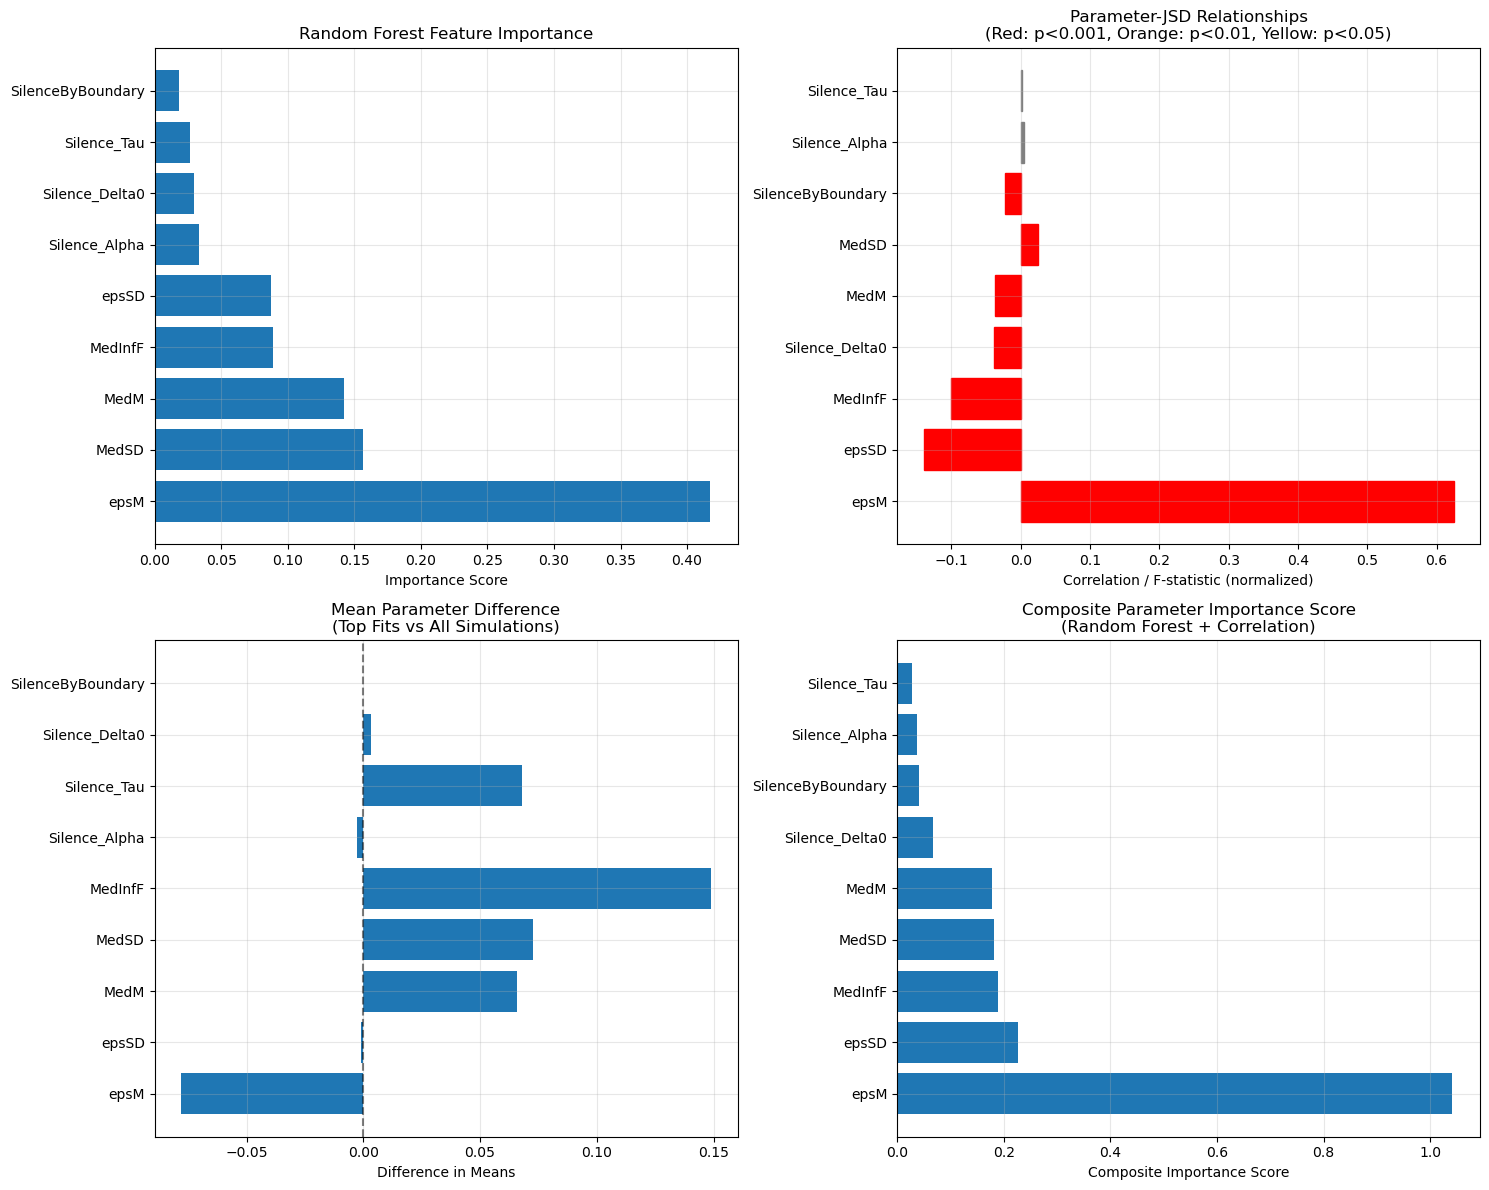

✓ Sensitivity analysis visualizations complete

################################################################################
SENSITIVITY ANALYSIS SUMMARY & RECOMMENDATIONS
################################################################################
✓ Most important parameters (Random Forest): ['epsM', 'MedSD', 'MedM']
✓ Statistically significant parameters: ['epsM', 'epsSD', 'MedInfF', 'Silence_Delta0', 'MedM', 'MedSD', 'SilenceByBoundary']
✓ Parameters with different distributions in top fits: ['epsM', 'epsSD', 'MedM', 'MedSD', 'MedInfF']

RECOMMENDATIONS:
1. Focus trajectory analysis on the most important parameters identified above
2. Consider fixing less important parameters to reduce search space complexity
3. Pay attention to parameter interactions in complex trajectory patterns


In [5]:


import statsmodels.api as sm
from statsmodels.formula.api import ols
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
import scipy.stats as spstats

CONFIG = {
    # 'target_countries': countries_of_interest,
    'model_number': 6,
    'success_percentile': 1
}

# =============================================================================
# SENSITIVITY ANALYSIS FOR MODEL PARAMETERS
# =============================================================================
def perform_parameter_sensitivity_analysis(config):
    """
    Comprehensive sensitivity analysis to identify which parameters matter most
    for achieving good fits
    """
    print(f"\n{'#'*80}")
    print("PARAMETER SENSITIVITY ANALYSIS")
    print(f"{'#'*80}")
    
    # Load the data
    model_idx = config['model_number'] - 1
    df = js_fits_stepwise_with_success[model_idx].copy()
    active_params = all_results[config['model_number']]['active_params']
    
    # Filter by SilenceByBoundary if present
    # if 'SilenceByBoundary' in df.columns:
    #     df = df[df['SilenceByBoundary'] == config['silence_by_boundary_value']]
    
    print(f"Analyzing {len(df):,} simulations from Model {config['model_number']}")
    print(f"Active parameters: {active_params}")
    
    # Sample data if too large for computational feasibility
    if len(df) > 100000:
        df_sampled = df.sample(n=100000, random_state=42)
        print(f"Sampled to 100,000 rows for computational feasibility")
    else:
        df_sampled = df.copy()
    
    results = {}
    
    # 1. Correlation Analysis
    print(f"\n1. PARAMETER CORRELATION ANALYSIS")
    results['correlations'] = analyze_parameter_correlations(df_sampled, active_params)
    
    # 2. ANOVA - Treat parameters as categorical factors
    print(f"\n2. ANOVA - PARAMETERS AS CATEGORICAL FACTORS")
    results['anova'] = perform_anova_analysis(df_sampled, active_params)
    
    # 3. Random Forest Feature Importance
    print(f"\n3. RANDOM FOREST FEATURE IMPORTANCE")
    results['random_forest'] = perform_random_forest_analysis(df_sampled, active_params)
    
    # 4. Parameter Value Distribution in Top Fits
    print(f"\n4. PARAMETER DISTRIBUTION IN TOP FITS")
    results['top_fits_analysis'] = analyze_top_fits_parameters(df_sampled, active_params, config)
    
    # 5. Pairwise Parameter Interactions
    print(f"\n5. PARAMETER INTERACTION ANALYSIS")
    results['interactions'] = analyze_parameter_interactions(df_sampled, active_params)
    
    return results

def analyze_parameter_correlations(df, active_params):
    """
    Analyze correlations between parameters and JSD (distance_final)
    """
    print("  Computing parameter-JSD correlations...")
    
    correlations = {}
    
    for param in active_params:
        if pd.api.types.is_numeric_dtype(df[param]):
            # Pearson correlation for numeric parameters
            corr, p_value = spstats.pearsonr(df[param], df['distance_final'])
            correlations[param] = {
                'correlation': corr,
                'p_value': p_value,
                'type': 'pearson'
            }
        else:
            # For categorical parameters, use ANOVA F-value as proxy
            groups = [group['distance_final'].values for name, group in df.groupby(param)]
            if len(groups) > 1:
                f_stat, p_value = spstats.f_oneway(*groups)
                correlations[param] = {
                    'f_statistic': f_stat,
                    'p_value': p_value,
                    'type': 'anova_f'
                }
    
    # Sort by absolute correlation/F-statistic
    sorted_correlations = sorted(
        [(param, stats) for param, stats in correlations.items()],
        key=lambda x: abs(x[1].get('correlation', x[1].get('f_statistic', 0))),
        reverse=True
    )
    
    print("  Parameter-JSD relationships (sorted by strength):")
    for param, stats in sorted_correlations:
        if stats['type'] == 'pearson':
            print(f"    {param:15} r = {stats['correlation']:7.3f} (p = {stats['p_value']:.2e})")
        else:
            print(f"    {param:15} F = {stats['f_statistic']:7.1f} (p = {stats['p_value']:.2e})")
    
    return dict(sorted_correlations)

def perform_anova_analysis(df, active_params):
    """
    Perform ANOVA treating parameters as categorical factors
    """
    print("  Performing ANOVA with parameters as categorical factors...")
    
    # Prepare data for ANOVA
    anova_data = df[active_params + ['distance_final']].copy()
    
    # Convert parameters to categorical
    for param in active_params:
        if pd.api.types.is_numeric_dtype(anova_data[param]):
            # For numeric parameters, create bins to treat as categorical
            unique_vals = anova_data[param].nunique()
            if unique_vals <= 10:  # If few unique values, use as-is
                anova_data[param] = anova_data[param].astype('category')
            else:  # If many values, bin them
                anova_data[param] = pd.cut(anova_data[param], bins=5).astype('category')
        else:
            anova_data[param] = anova_data[param].astype('category')
    
    # Build ANOVA formula
    formula = "distance_final ~ " + " + ".join([f"C({param})" for param in active_params])
    
    try:
        # Fit ANOVA model
        model = ols(formula, data=anova_data).fit()
        anova_table = sm.stats.anova_lm(model, typ=2)
        
        print("  ANOVA Results (Type II SS):")
        print("  " + "-" * 50)
        for param in active_params:
            if f"C({param})" in anova_table.index:
                f_value = anova_table.loc[f"C({param})", 'F']
                p_value = anova_table.loc[f"C({param})", 'PR(>F)']
                sum_sq = anova_table.loc[f"C({param})", 'sum_sq']
                
                significance = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else ""
                print(f"    {param:15} F = {f_value:7.1f} (p = {p_value:.2e}) {significance}")
        
        return anova_table
        
    except Exception as e:
        print(f"    ANOVA failed: {e}")
        return None

def perform_random_forest_analysis(df, active_params):
    """
    Use Random Forest to determine feature importance
    """
    print("  Training Random Forest for feature importance...")
    
    # Prepare features and target
    X = df[active_params].copy()
    y = df['distance_final']
    
    # Encode categorical variables
    label_encoders = {}
    for param in active_params:
        if not pd.api.types.is_numeric_dtype(X[param]):
            le = LabelEncoder()
            X[param] = le.fit_transform(X[param].astype(str))
            label_encoders[param] = le
    
    # Train Random Forest
    rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X, y)
    
    # Get feature importances
    importances = rf.feature_importances_
    feature_importance_df = pd.DataFrame({
        'parameter': active_params,
        'importance': importances
    }).sort_values('importance', ascending=False)
    
    print("  Random Forest Feature Importance:")
    for _, row in feature_importance_df.iterrows():
        print(f"    {row['parameter']:15} importance = {row['importance']:.4f}")
    
    return {
        'feature_importances': feature_importance_df,
        'random_forest': rf,
        'label_encoders': label_encoders
    }

def analyze_top_fits_parameters(df, active_params, config):
    """
    Analyze which parameter values are overrepresented in top fits
    """
    print("  Analyzing parameter distributions in top fits...")
    
    # Identify top fits (lowest JSD)
    top_percentile = config['success_percentile']
    threshold = df['distance_final'].quantile(top_percentile / 100)
    top_fits = df[df['distance_final'] <= threshold]
    all_data = df
    
    print(f"    Top {top_percentile}% fits: {len(top_fits):,} simulations")
    
    enrichment_results = {}
    
    for param in active_params:
        # For numeric parameters, compare distributions
        if pd.api.types.is_numeric_dtype(df[param]):
            ks_stat, ks_p = spstats.ks_2samp(
                top_fits[param].dropna(),
                all_data[param].dropna()
            )
            
            mean_top = top_fits[param].mean()
            mean_all = all_data[param].mean()
            
            enrichment_results[param] = {
                'ks_statistic': ks_stat,
                'ks_p_value': ks_p,
                'mean_top': mean_top,
                'mean_all': mean_all,
                'mean_difference': mean_top - mean_all,
                'type': 'numeric'
            }
        
        else:
            # For categorical parameters, compare proportions
            top_counts = top_fits[param].value_counts(normalize=True)
            all_counts = all_data[param].value_counts(normalize=True)
            
            # Calculate enrichment (overrepresentation in top fits)
            enrichment = {}
            for category in all_counts.index:
                if category in top_counts:
                    enrichment[category] = top_counts[category] / all_counts[category]
                else:
                    enrichment[category] = 0
            
            # Find most enriched category
            if enrichment:
                most_enriched = max(enrichment.items(), key=lambda x: x[1])
                enrichment_results[param] = {
                    'most_enriched_category': most_enriched[0],
                    'enrichment_ratio': most_enriched[1],
                    'all_categories': dict(enrichment),
                    'type': 'categorical'
                }
    
    # Sort by significance/effect size
    print("  Parameter enrichment in top fits:")
    for param, result in sorted(enrichment_results.items(), 
                               key=lambda x: abs(x[1].get('ks_statistic', x[1].get('enrichment_ratio', 0))), 
                               reverse=True):
        if result['type'] == 'numeric':
            direction = "lower" if result['mean_difference'] < 0 else "higher"
            print(f"    {param:15} KS = {result['ks_statistic']:.3f} (p = {result['ks_p_value']:.2e})")
            print(f"                   Mean in top fits: {result['mean_top']:.3f} ({direction} than overall)")
        else:
            print(f"    {param:15} Most enriched: '{result['most_enriched_category']}' "
                  f"(enrichment: {result['enrichment_ratio']:.2f}x)")
    
    return enrichment_results

def analyze_parameter_interactions(df, active_params):
    """
    Analyze interactions between parameters
    """
    print("  Analyzing parameter interactions...")
    
    # Focus on top 4 most important parameters to avoid combinatorial explosion
    if len(active_params) > 4:
        # Use correlation with JSD as proxy for importance
        important_params = []
        for param in active_params:
            if pd.api.types.is_numeric_dtype(df[param]):
                corr = abs(df[param].corr(df['distance_final']))
            else:
                # For categorical, use F-statistic from quick ANOVA
                groups = [group['distance_final'].values for name, group in df.groupby(param)]
                if len(groups) > 1:
                    f_stat, _ = spstats.f_oneway(*groups)
                    corr = f_stat / 100  # Rough normalization
                else:
                    corr = 0
            important_params.append((param, corr))
        
        important_params.sort(key=lambda x: x[1], reverse=True)
        analysis_params = [p[0] for p in important_params[:4]]
    else:
        analysis_params = active_params
    
    print(f"    Analyzing interactions between: {analysis_params}")
    
    interaction_results = {}
    
    # Analyze pairwise interactions
    for i, param1 in enumerate(analysis_params):
        for param2 in analysis_params[i+1:]:
            # Create interaction groups and compare JSD distributions
            interaction_groups = []
            group_labels = []
            
            for (val1, val2), group in df.groupby([param1, param2]):
                if len(group) > 10:  # Only consider groups with sufficient data
                    interaction_groups.append(group['distance_final'].values)
                    group_labels.append(f"{param1}={val1}, {param2}={val2}")
            
            if len(interaction_groups) >= 2:
                # Perform ANOVA to test interaction
                f_stat, p_value = spstats.f_oneway(*interaction_groups)
                
                if p_value < 0.05:  # Significant interaction
                    # Calculate effect size (eta squared)
                    all_data = np.concatenate(interaction_groups)
                    ss_between = sum(len(group) * (group.mean() - all_data.mean())**2 for group in interaction_groups)
                    ss_total = sum((all_data - all_data.mean())**2)
                    eta_squared = ss_between / ss_total
                    
                    interaction_results[f"{param1} × {param2}"] = {
                        'f_statistic': f_stat,
                        'p_value': p_value,
                        'eta_squared': eta_squared,
                        'n_groups': len(interaction_groups)
                    }
    
    if interaction_results:
        print("  Significant parameter interactions:")
        for interaction, stats in sorted(interaction_results.items(), 
                                       key=lambda x: x[1]['eta_squared'], 
                                       reverse=True):
            print(f"    {interaction:25} η² = {stats['eta_squared']:.3f} "
                  f"(p = {stats['p_value']:.2e})")
    else:
        print("    No significant interactions found at p < 0.05")
    
    return interaction_results

# =============================================================================
# VISUALIZATION OF SENSITIVITY RESULTS
# =============================================================================
def plot_sensitivity_results(sensitivity_results, config):
    """
    Create visualizations of sensitivity analysis results
    """
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    print(f"\n{'#'*80}")
    print("SENSITIVITY ANALYSIS VISUALIZATION")
    print(f"{'#'*80}")
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # Plot 1: Random Forest Feature Importance
    if 'random_forest' in sensitivity_results:
        rf_results = sensitivity_results['random_forest']
        importance_df = rf_results['feature_importances']
        
        axes[0, 0].barh(importance_df['parameter'], importance_df['importance'])
        axes[0, 0].set_title('Random Forest Feature Importance')
        axes[0, 0].set_xlabel('Importance Score')
        axes[0, 0].grid(True, alpha=0.3)
    
    # Plot 2: Parameter-JSD Correlations
    if 'correlations' in sensitivity_results:
        correlations = sensitivity_results['correlations']
        params = list(correlations.keys())
        corr_values = [stats.get('correlation', stats.get('f_statistic', 0)/100) 
                      for stats in correlations.values()]
        
        # Create bar plot
        bars = axes[0, 1].barh(params, corr_values)
        
        # Color bars by significance
        for i, (param, stats) in enumerate(correlations.items()):
            p_value = stats['p_value']
            if p_value < 0.001:
                bars[i].set_color('red')
            elif p_value < 0.01:
                bars[i].set_color('orange')
            elif p_value < 0.05:
                bars[i].set_color('yellow')
            else:
                bars[i].set_color('gray')
        
        axes[0, 1].set_title('Parameter-JSD Relationships\n(Red: p<0.001, Orange: p<0.01, Yellow: p<0.05)')
        axes[0, 1].set_xlabel('Correlation / F-statistic (normalized)')
        axes[0, 1].grid(True, alpha=0.3)
    
    # Plot 3: Top Fits Parameter Distribution
    if 'top_fits_analysis' in sensitivity_results:
        top_fits_results = sensitivity_results['top_fits_analysis']
        numeric_params = [p for p, r in top_fits_results.items() if r['type'] == 'numeric']
        
        if numeric_params:
            differences = [top_fits_results[p]['mean_difference'] for p in numeric_params]
            axes[1, 0].barh(numeric_params, differences)
            axes[1, 0].axvline(x=0, color='black', linestyle='--', alpha=0.5)
            axes[1, 0].set_title('Mean Parameter Difference\n(Top Fits vs All Simulations)')
            axes[1, 0].set_xlabel('Difference in Means')
            axes[1, 0].grid(True, alpha=0.3)
    
    # Plot 4: Summary Ranking
    if 'random_forest' in sensitivity_results and 'correlations' in sensitivity_results:
        # Combine rankings from different methods
        rf_ranking = {row['parameter']: row['importance'] 
                     for _, row in sensitivity_results['random_forest']['feature_importances'].iterrows()}
        
        # Create composite score
        composite_scores = {}
        for param in rf_ranking.keys():
            score = rf_ranking[param]
            if param in sensitivity_results['correlations']:
                # Add correlation strength (absolute value)
                corr_stats = sensitivity_results['correlations'][param]
                if corr_stats['type'] == 'pearson':
                    score += abs(corr_stats['correlation'])
                else:
                    score += corr_stats.get('f_statistic', 0) / 100
            
            composite_scores[param] = score
        
        # Sort and plot
        sorted_params = sorted(composite_scores.items(), key=lambda x: x[1], reverse=True)
        params_ordered = [p[0] for p in sorted_params]
        scores_ordered = [p[1] for p in sorted_params]
        
        axes[1, 1].barh(params_ordered, scores_ordered)
        axes[1, 1].set_title('Composite Parameter Importance Score\n(Random Forest + Correlation)')
        axes[1, 1].set_xlabel('Composite Importance Score')
        axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("✓ Sensitivity analysis visualizations complete")

# =============================================================================
# EXECUTE SENSITIVITY ANALYSIS
# =============================================================================
def run_comprehensive_sensitivity_analysis(config):
    """
    Run the complete sensitivity analysis pipeline
    """
    print(f"\n{'#'*80}")
    print("COMPREHENSIVE PARAMETER SENSITIVITY ANALYSIS")
    print(f"{'#'*80}")
    
    # Perform sensitivity analysis
    sensitivity_results = perform_parameter_sensitivity_analysis(config)
    
    # Create visualizations
    plot_sensitivity_results(sensitivity_results, config)
    
    # Generate summary recommendations
    print(f"\n{'#'*80}")
    print("SENSITIVITY ANALYSIS SUMMARY & RECOMMENDATIONS")
    print(f"{'#'*80}")
    
    # Extract key insights
    if 'random_forest' in sensitivity_results:
        rf_importances = sensitivity_results['random_forest']['feature_importances']
        top_params = rf_importances.head(3)['parameter'].tolist()
        print(f"✓ Most important parameters (Random Forest): {top_params}")
    
    if 'correlations' in sensitivity_results:
        significant_params = []
        for param, stats in sensitivity_results['correlations'].items():
            if stats['p_value'] < 0.05:
                significant_params.append(param)
        
        if significant_params:
            print(f"✓ Statistically significant parameters: {significant_params}")
        else:
            print("✗ No parameters show statistically significant relationship with JSD")
    
    if 'top_fits_analysis' in sensitivity_results:
        enriched_params = []
        for param, result in sensitivity_results['top_fits_analysis'].items():
            if result['type'] == 'numeric' and result['ks_p_value'] < 0.05:
                enriched_params.append(param)
        
        if enriched_params:
            print(f"✓ Parameters with different distributions in top fits: {enriched_params}")
    
    print(f"\nRECOMMENDATIONS:")
    print("1. Focus trajectory analysis on the most important parameters identified above")
    print("2. Consider fixing less important parameters to reduce search space complexity")
    print("3. Pay attention to parameter interactions in complex trajectory patterns")
    
    return sensitivity_results

# Execute the sensitivity analysis
sensitivity_results = run_comprehensive_sensitivity_analysis(CONFIG)


################################################################################
PARAMETER VALUE OPTIMIZATION ANALYSIS
################################################################################
Analyzing 58,351,104 simulations from Model 6
Active parameters: ['epsM', 'epsSD', 'MedM', 'MedSD', 'MedInfF', 'Silence_Alpha', 'Silence_Tau', 'Silence_Delta0', 'SilenceByBoundary']

################################################################################
PARAMETER VALUE OPTIMIZATION ANALYSIS
################################################################################
Sampled to 100,000 rows for computational feasibility

1. RANDOM FOREST WITH VARIANCE EXPLANATION
  Random Forest explains 0.826 (82.6%) of JSD variance
  Top parameters by importance:
    epsM            importance = 0.4450
    MedSD           importance = 0.1631
    MedM            importance = 0.1538
    epsSD           importance = 0.0917
    MedInfF         importance = 0.0916
    Silence_Delta0  importance 

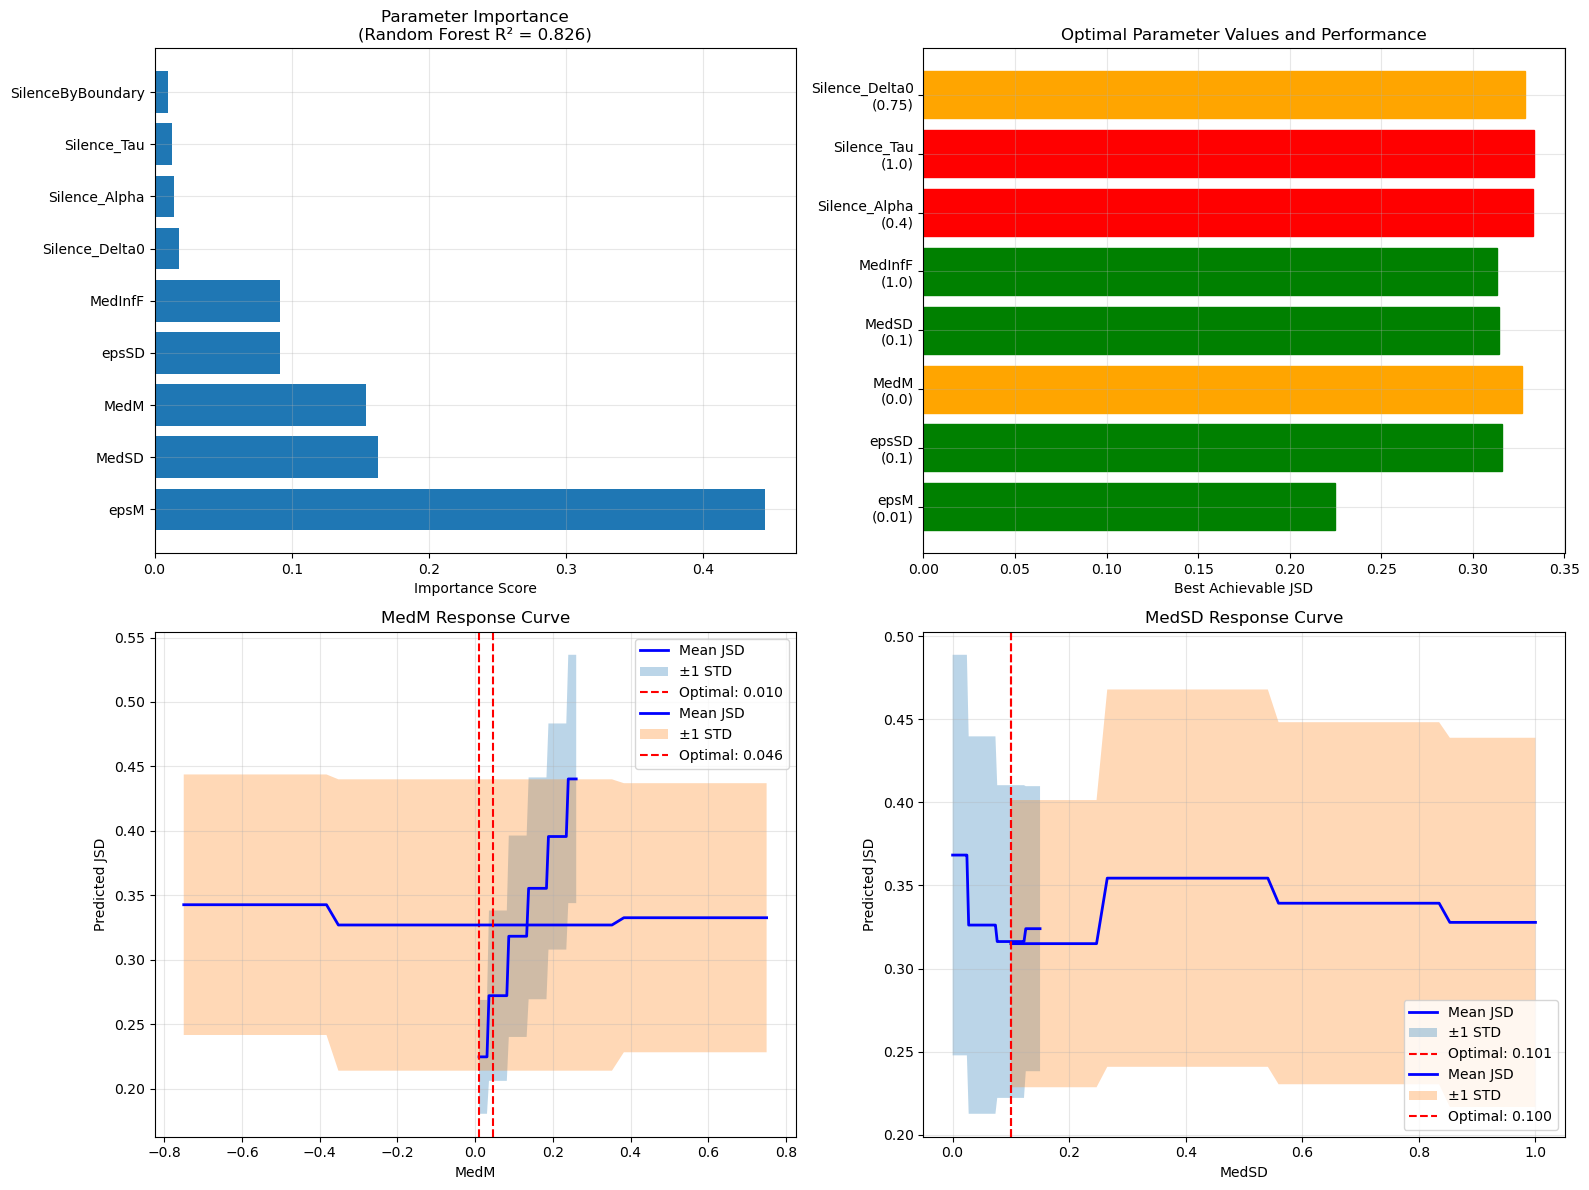


################################################################################
EXECUTIVE SUMMARY: OPTIMAL PARAMETER VALUES
################################################################################
✓ Random Forest explains 0.826 (82.6%) of JSD variance

✓ RECOMMENDED PARAMETER VALUES:
   epsM            → 0.01 (JSD: 0.2249, success rate: 15.7%)
   epsSD           → 0.1 (JSD: 0.3158, success rate: 5.2%)
   MedM            → 0.0 (JSD: 0.3268, success rate: 7.7%)
   MedSD           → 0.1 (JSD: 0.3144, success rate: 3.1%)
   MedInfF         → 1.0 (JSD: 0.3132, success rate: 8.0%)
   Silence_Alpha   → 0.4 (JSD: 0.3330, success rate: 4.8%)


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score
import scipy.stats as spstats

def analyze_optimal_parameter_values(df, active_params, config):
    """
    Deep analysis of which specific parameter values give the best JSD scores
    """
    print(f"\n{'#'*80}")
    print("PARAMETER VALUE OPTIMIZATION ANALYSIS")
    print(f"{'#'*80}")
    
    # Sample data if too large
    if len(df) > 100000:
        df_sampled = df.sample(n=100000, random_state=42)
        print(f"Sampled to 100,000 rows for computational feasibility")
    else:
        df_sampled = df.copy()
    
    results = {}
    
    # 1. Enhanced Random Forest with variance explained
    print(f"\n1. RANDOM FOREST WITH VARIANCE EXPLANATION")
    rf_results = enhanced_random_forest_optimization(df_sampled, active_params)
    results['random_forest'] = rf_results
    
    # 2. Parameter Value Performance Analysis
    print(f"\n2. PARAMETER VALUE PERFORMANCE RANKING")
    results['value_performance'] = analyze_parameter_value_performance(df_sampled, active_params, config)
    
    # 3. Optimal Parameter Combinations
    print(f"\n3. OPTIMAL PARAMETER COMBINATIONS")
    results['optimal_combinations'] = find_optimal_parameter_combinations(df_sampled, active_params, config)
    
    # 4. Parameter Response Surfaces
    print(f"\n4. PARAMETER RESPONSE ANALYSIS")
    results['response_analysis'] = analyze_parameter_responses(df_sampled, active_params, rf_results['model'])
    
    # Create comprehensive visualizations
    plot_parameter_optimization_results(results, active_params, config)
    
    return results

def enhanced_random_forest_optimization(df, active_params):
    """
    Random Forest focused on understanding parameter value effects
    """
    from sklearn.model_selection import train_test_split
    
    # Prepare features and target
    X = df[active_params].copy()
    y = df['distance_final']
    
    # Encode categorical variables
    label_encoders = {}
    for param in active_params:
        if not pd.api.types.is_numeric_dtype(X[param]):
            le = LabelEncoder()
            X[param] = le.fit_transform(X[param].astype(str))
            label_encoders[param] = le
    
    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Train optimized Random Forest
    rf = RandomForestRegressor(
        n_estimators=200,
        max_depth=20,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_train, y_train)
    
    # Calculate variance explained
    y_pred = rf.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    
    # Feature importance
    feature_importance_df = pd.DataFrame({
        'parameter': active_params,
        'importance': rf.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print(f"  Random Forest explains {r2:.3f} ({r2:.1%}) of JSD variance")
    print(f"  Top parameters by importance:")
    for _, row in feature_importance_df.head(6).iterrows():
        print(f"    {row['parameter']:15} importance = {row['importance']:.4f}")
    
    return {
        'feature_importances': feature_importance_df,
        'model': rf,
        'label_encoders': label_encoders,
        'variance_explained': r2,
        'performance': {'r2': r2}
    }

def analyze_parameter_value_performance(df, active_params, config):
    """
    Analyze which specific parameter values give the best JSD scores
    """
    print("  Analyzing performance by parameter value...")
    
    value_performance = {}
    top_percentile = config['success_percentile']
    top_threshold = df['distance_final'].quantile(top_percentile / 100)
    
    for param in active_params:
        param_results = {}
        
        if pd.api.types.is_numeric_dtype(df[param]):
            # For numeric parameters: analyze value vs JSD relationship
            unique_vals = df[param].unique()
            if len(unique_vals) > 20:  # Too many values, use bins
                df_temp = df.copy()
                df_temp[f'{param}_binned'] = pd.cut(df_temp[param], bins=10)
                binned_analysis = df_temp.groupby(f'{param}_binned')['distance_final'].agg([
                    'mean', 'std', 'count', 
                    lambda x: (x <= top_threshold).sum() / len(x)  # success rate
                ]).rename(columns={'<lambda_0>': 'success_rate'})
                
                # Find best bin
                best_bin = binned_analysis.loc[binned_analysis['mean'].idxmin()]
                best_range = binned_analysis['mean'].idxmin()
                
                param_results = {
                    'type': 'numeric_binned',
                    'best_range': best_range,
                    'best_mean_jsd': best_bin['mean'],
                    'success_rate': best_bin['success_rate'],
                    'all_bins': binned_analysis.sort_values('mean')
                }
                
                print(f"    {param:15} Best range: {best_range} "
                      f"(JSD: {best_bin['mean']:.4f}, success: {best_bin['success_rate']:.1%})")
                
            else:
                # Few unique values, analyze each
                value_stats = []
                for val in sorted(unique_vals):
                    subset = df[df[param] == val]
                    if len(subset) > 10:  # Minimum sample size
                        mean_jsd = subset['distance_final'].mean()
                        success_rate = (subset['distance_final'] <= top_threshold).mean()
                        value_stats.append({
                            'value': val,
                            'mean_jsd': mean_jsd,
                            'success_rate': success_rate,
                            'count': len(subset)
                        })
                
                if value_stats:
                    value_stats_df = pd.DataFrame(value_stats)
                    best_row = value_stats_df.loc[value_stats_df['mean_jsd'].idxmin()]
                    
                    param_results = {
                        'type': 'numeric_discrete',
                        'best_value': best_row['value'],
                        'best_mean_jsd': best_row['mean_jsd'],
                        'success_rate': best_row['success_rate'],
                        'all_values': value_stats_df.sort_values('mean_jsd')
                    }
                    
                    print(f"    {param:15} Best value: {best_row['value']} "
                          f"(JSD: {best_row['mean_jsd']:.4f}, success: {best_row['success_rate']:.1%})")
        
        else:
            # For categorical parameters
            value_stats = []
            for val in df[param].unique():
                subset = df[df[param] == val]
                if len(subset) > 10:
                    mean_jsd = subset['distance_final'].mean()
                    success_rate = (subset['distance_final'] <= top_threshold).mean()
                    value_stats.append({
                        'value': val,
                        'mean_jsd': mean_jsd,
                        'success_rate': success_rate,
                        'count': len(subset)
                    })
            
            if value_stats:
                value_stats_df = pd.DataFrame(value_stats)
                best_row = value_stats_df.loc[value_stats_df['mean_jsd'].idxmin()]
                
                param_results = {
                    'type': 'categorical',
                    'best_value': best_row['value'],
                    'best_mean_jsd': best_row['mean_jsd'],
                    'success_rate': best_row['success_rate'],
                    'all_values': value_stats_df.sort_values('mean_jsd')
                }
                
                print(f"    {param:15} Best value: '{best_row['value']}' "
                      f"(JSD: {best_row['mean_jsd']:.4f}, success: {best_row['success_rate']:.1%})")
        
        value_performance[param] = param_results
    
    return value_performance

def find_optimal_parameter_combinations(df, active_params, config):
    """
    Find combinations of parameter values that consistently yield good results
    """
    print("  Finding optimal parameter combinations...")
    
    # Focus on top 4 most important parameters to avoid combinatorial explosion
    top_params = active_params[:4] if len(active_params) >= 4 else active_params
    
    # Get top performing simulations
    top_percentile = config['success_percentile']
    top_threshold = df['distance_final'].quantile(top_percentile / 100)
    top_fits = df[df['distance_final'] <= top_threshold].copy()
    
    print(f"    Analyzing {len(top_fits):,} top simulations")
    
    # Analyze frequent parameter value combinations in top fits
    combination_analysis = {}
    
    for param in top_params:
        # Find overrepresented values in top fits
        top_value_counts = top_fits[param].value_counts(normalize=True)
        all_value_counts = df[param].value_counts(normalize=True)
        
        enrichment = {}
        for val in all_value_counts.index:
            if val in top_value_counts:
                enrichment_ratio = top_value_counts[val] / all_value_counts[val]
                enrichment[val] = {
                    'enrichment_ratio': enrichment_ratio,
                    'frequency_in_top': top_value_counts[val],
                    'frequency_overall': all_value_counts[val]
                }
        
        # Sort by enrichment ratio
        sorted_enrichment = sorted(enrichment.items(), key=lambda x: x[1]['enrichment_ratio'], reverse=True)
        combination_analysis[param] = {
            'top_enriched_values': sorted_enrichment[:3],  # Top 3 enriched values
            'all_enrichment': dict(sorted_enrichment)
        }
    
    # Print recommended combinations
    print(f"    Recommended parameter values (most enriched in top fits):")
    for param in top_params:
        if param in combination_analysis and combination_analysis[param]['top_enriched_values']:
            best_val, stats = combination_analysis[param]['top_enriched_values'][0]
            print(f"      {param:15} → {best_val} "
                  f"(enriched {stats['enrichment_ratio']:.1f}x, "
                  f"in {stats['frequency_in_top']:.1%} of top fits)")
    
    return combination_analysis

def analyze_parameter_responses(df, active_params, rf_model):
    """
    Analyze how JSD responds to changes in each parameter
    """
    print("  Analyzing parameter response patterns...")
    
    # Prepare features (matching RF preprocessing)
    X = df[active_params].copy()
    label_encoders = {}
    
    for param in active_params:
        if not pd.api.types.is_numeric_dtype(X[param]):
            le = LabelEncoder()
            X[param] = le.fit_transform(X[param].astype(str))
            label_encoders[param] = le
    
    response_analysis = {}
    
    for param in active_params[:6]:  # Analyze top 6 parameters
        if pd.api.types.is_numeric_dtype(df[param]):
            # Compute response curve
            unique_vals = np.linspace(df[param].min(), df[param].max(), 50)
            response_means = []
            response_stds = []
            
            for val in unique_vals:
                X_temp = X.copy()
                X_temp[param] = val
                predictions = rf_model.predict(X_temp)
                response_means.append(predictions.mean())
                response_stds.append(predictions.std())
            
            # Find optimal value from response curve
            optimal_idx = np.argmin(response_means)
            optimal_value = unique_vals[optimal_idx]
            optimal_jsd = response_means[optimal_idx]
            
            # Characterize response shape
            if optimal_idx == 0:
                trend = "decreasing"
            elif optimal_idx == len(unique_vals) - 1:
                trend = "increasing" 
            else:
                trend = "unimodal"
            
            response_analysis[param] = {
                'values': unique_vals,
                'means': response_means,
                'stds': response_stds,
                'optimal_value': optimal_value,
                'optimal_jsd': optimal_jsd,
                'trend': trend
            }
            
            print(f"    {param:15} Optimal: {optimal_value:.3f} "
                  f"(JSD: {optimal_jsd:.4f}), trend: {trend}")
    
    return response_analysis

def plot_parameter_optimization_results(results, active_params, config):
    """
    Create comprehensive visualizations of optimal parameter values
    """
    print(f"\n{'#'*80}")
    print("PARAMETER OPTIMIZATION VISUALIZATIONS")
    print(f"{'#'*80}")
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Plot 1: Parameter Importance with Variance Explained
    if 'random_forest' in results:
        rf_results = results['random_forest']
        importance_df = rf_results['feature_importances']
        variance_explained = rf_results['variance_explained']
        
        axes[0, 0].barh(importance_df['parameter'], importance_df['importance'])
        axes[0, 0].set_title(f'Parameter Importance\n(Random Forest R² = {variance_explained:.3f})')
        axes[0, 0].set_xlabel('Importance Score')
        axes[0, 0].grid(True, alpha=0.3)
    
    # Plot 2: Best Parameter Values
    if 'value_performance' in results:
        value_results = results['value_performance']
        
        # Extract best values and their performance
        params_plot = []
        best_values = []
        best_jsds = []
        
        for param, result in list(value_results.items())[:8]:  # Top 8 parameters
            if result:
                params_plot.append(param)
                if result['type'] in ['numeric_discrete', 'categorical']:
                    best_values.append(str(result['best_value']))
                else:
                    best_values.append(str(result['best_range']))
                best_jsds.append(result['best_mean_jsd'])
        
        # Create horizontal bar plot
        y_pos = range(len(params_plot))
        bars = axes[0, 1].barh(y_pos, best_jsds)
        axes[0, 1].set_yticks(y_pos)
        axes[0, 1].set_yticklabels([f"{p}\n({v})" for p, v in zip(params_plot, best_values)])
        axes[0, 1].set_xlabel('Best Achievable JSD')
        axes[0, 1].set_title('Optimal Parameter Values and Performance')
        axes[0, 1].grid(True, alpha=0.3)
        
        # Color bars by JSD quality
        for bar, jsd in zip(bars, best_jsds):
            if jsd < np.median(best_jsds):
                bar.set_color('green')
            elif jsd < np.percentile(best_jsds, 75):
                bar.set_color('orange')
            else:
                bar.set_color('red')
    
    # Plot 3: Parameter Response Curves
    if 'response_analysis' in results:
        response_results = results['response_analysis']
        
        for i, (param, result) in enumerate(list(response_results.items())[:4]):  # Top 4
            row = i // 2
            col = i % 2
            ax = axes[1, col] if i < 4 else None
            
            if ax:
                ax.plot(result['values'], result['means'], 'b-', linewidth=2, label='Mean JSD')
                ax.fill_between(result['values'], 
                               np.array(result['means']) - np.array(result['stds']),
                               np.array(result['means']) + np.array(result['stds']),
                               alpha=0.3, label='±1 STD')
                
                # Mark optimal value
                ax.axvline(result['optimal_value'], color='red', linestyle='--', 
                          label=f'Optimal: {result["optimal_value"]:.3f}')
                
                ax.set_xlabel(param)
                ax.set_ylabel('Predicted JSD')
                ax.set_title(f'{param} Response Curve')
                ax.legend()
                ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def run_parameter_optimization_analysis(config):
    """
    Main function to run parameter optimization analysis
    """
    print(f"\n{'#'*80}")
    print("PARAMETER VALUE OPTIMIZATION ANALYSIS")
    print(f"{'#'*80}")
    
    # Load your data
    model_idx = config['model_number'] - 1
    df = js_fits_stepwise_with_success[model_idx].copy()
    active_params = all_results[config['model_number']]['active_params']
    
    print(f"Analyzing {len(df):,} simulations from Model {config['model_number']}")
    print(f"Active parameters: {active_params}")
    
    # Run the optimization analysis
    optimization_results = analyze_optimal_parameter_values(df, active_params, config)
    
    # Print executive summary
    print(f"\n{'#'*80}")
    print("EXECUTIVE SUMMARY: OPTIMAL PARAMETER VALUES")
    print(f"{'#'*80}")
    
    if 'random_forest' in optimization_results:
        rf_info = optimization_results['random_forest']
        print(f"✓ Random Forest explains {rf_info['variance_explained']:.3f} ({rf_info['variance_explained']:.1%}) of JSD variance")
    
    if 'value_performance' in optimization_results:
        print(f"\n✓ RECOMMENDED PARAMETER VALUES:")
        value_results = optimization_results['value_performance']
        for param, result in list(value_results.items())[:6]:  # Top 6
            if result:
                if result['type'] in ['numeric_discrete', 'categorical']:
                    print(f"   {param:15} → {result['best_value']} "
                          f"(JSD: {result['best_mean_jsd']:.4f}, "
                          f"success rate: {result['success_rate']:.1%})")
                else:
                    print(f"   {param:15} → {result['best_range']} "
                          f"(JSD: {result['best_mean_jsd']:.4f}, "
                          f"success rate: {result['success_rate']:.1%})")
    
    return optimization_results

# Execute the parameter optimization analysis
optimization_results = run_parameter_optimization_analysis(CONFIG)

In [61]:

CONFIG = {
    # 'target_countries': countries_of_interest,
    'model_number': 6,
    'success_percentile': 0.05
}

## Sanity check -- is it indeed our model dynamics that's causing the fits or is it just the initial opinion distribution combining with low epsilon (less dynamic situations) that happen to match some distributions

### Let's see if there is a correlation between epsM and the change in JSD from the beginning to the end of the simulation


################################################################################
EPSM - DISTANCE_DELTA RELATIONSHIP ANALYSIS (MEMORY EFFICIENT)
CORRECTED: Negative Δ = Improvement, Positive Δ = Worse
################################################################################
Sampling 50,000 simulations from 58,351,104 total...
Analyzing 50,000 simulations from Model 6
REMEMBER: Negative delta = Improvement, Positive delta = Worse

1. BASIC CORRELATION ANALYSIS
   Pearson correlation: r = 0.5697 (p = 0.00e+00)
   ✓ Significant strong positive relationship found
   → Higher epsM associated with WORSE outcomes (positive delta)

2. QUICK EPSM BINS ANALYSIS
   epsM Range        | Avg ΔDistance | Avg Final JSD | Improv Rate | Count
   ---------------------------------------------------------------------------
   (0.00975, 0.0412]  |       0.0232 ✗ |        0.2252 |       37.8% |  8,195
   (0.0412, 0.0725]   |       0.0687 ✗ |        0.2718 |       23.3% |  8,371
   (0.104, 0.135]     |

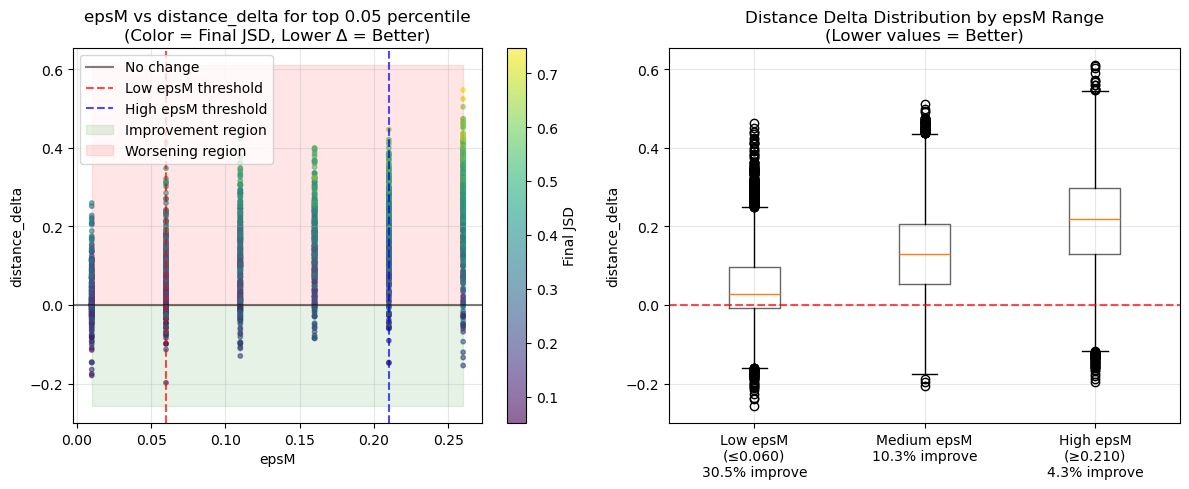


################################################################################
VALIDITY ASSESSMENT & RECOMMENDATIONS
################################################################################
KEY FINDINGS:
• Correlation: epsM ↔ distance_delta: r = 0.570
• Low epsM improvement rate: 30.5%
• High epsM improvement rate: 4.3%
• Improvement ratio (low/high): 7.06x
• Low epsM represents 11.6% of top fits
• High epsM represents 1.2% of top fits

✅ Low epsM success appears valid
   Improvement patterns support genuine opinion dynamics


In [31]:
def analyze_epsM_delta_relationship_memory_efficient(config, sample_size=50000):
    """
    Memory-efficient analysis of epsM vs distance_delta relationship
    CORRECTED INTERPRETATION: Negative delta = Improvement, Positive delta = Worse
    """
    print(f"\n{'#'*80}")
    print("EPSM - DISTANCE_DELTA RELATIONSHIP ANALYSIS (MEMORY EFFICIENT)")
    print("CORRECTED: Negative Δ = Improvement, Positive Δ = Worse")
    print(f"{'#'*80}")
    
    # Load only the columns we need to save memory
    model_idx = config['model_number'] - 1
    
    # Sample first, then copy to avoid memory issues
    full_data = js_fits_stepwise_with_success[model_idx]
    
    # If data is large, sample strategically
    if len(full_data) > sample_size:
        print(f"Sampling {sample_size:,} simulations from {len(full_data):,} total...")
        df = full_data[['epsM', 'distance_delta', 'distance_final']].sample(
            n=sample_size, random_state=42
        ).copy()
    else:
        df = full_data[['epsM', 'distance_delta', 'distance_final']].copy()
    
    print(f"Analyzing {len(df):,} simulations from Model {config['model_number']}")
    print(f"REMEMBER: Negative delta = Improvement, Positive delta = Worse")
    
    # 1. Basic correlation analysis
    print(f"\n1. BASIC CORRELATION ANALYSIS")
    corr_coef, p_value = spstats.pearsonr(df['epsM'], df['distance_delta'])
    print(f"   Pearson correlation: r = {corr_coef:.4f} (p = {p_value:.2e})")
    
    if p_value < 0.05:
        direction = "positive" if corr_coef > 0 else "negative"
        strength = "strong" if abs(corr_coef) > 0.5 else "moderate" if abs(corr_coef) > 0.3 else "weak"
        print(f"   ✓ Significant {strength} {direction} relationship found")
        
        # Interpret the correlation direction
        if corr_coef > 0:
            print(f"   → Higher epsM associated with WORSE outcomes (positive delta)")
        else:
            print(f"   → Higher epsM associated with BETTER outcomes (negative delta)")
    else:
        print(f"   ✗ No significant linear relationship")
    
    # 2. Quick bin analysis without creating new DataFrame
    print(f"\n2. QUICK EPSM BINS ANALYSIS")
    
    epsM_bins = pd.cut(df['epsM'], bins=8)
    bin_results = []
    
    for bin_range in epsM_bins.unique():
        if pd.isna(bin_range):
            continue
        mask = (epsM_bins == bin_range)
        bin_data = df[mask]
        if len(bin_data) > 10:
            # Calculate improvement metrics
            improvement_rate = (bin_data['distance_delta'] < 0).mean()
            worsening_rate = (bin_data['distance_delta'] > 0).mean()
            no_change_rate = (bin_data['distance_delta'] == 0).mean()
            
            bin_results.append({
                'epsM_range': bin_range,
                'avg_epsM': bin_data['epsM'].mean(),
                'avg_delta': bin_data['distance_delta'].mean(),
                'avg_final': bin_data['distance_final'].mean(),
                'improvement_rate': improvement_rate,
                'worsening_rate': worsening_rate,
                'no_change_rate': no_change_rate,
                'count': len(bin_data)
            })
    
    # Sort by epsM value
    bin_results.sort(key=lambda x: x['avg_epsM'])
    
    print("   epsM Range        | Avg ΔDistance | Avg Final JSD | Improv Rate | Count")
    print("   " + "-" * 75)
    for result in bin_results[:6]:  # Show first 6 bins
        epsm_range = str(result['epsM_range'])[:18]
        avg_delta = result['avg_delta']
        avg_final = result['avg_final']
        improv_rate = result['improvement_rate']
        count = result['count']
        
        # Color code the delta value
        delta_indicator = "✓" if avg_delta < 0 else "✗" if avg_delta > 0 else "○"
        
        print(f"   {epsm_range:18} | {avg_delta:12.4f} {delta_indicator} | {avg_final:13.4f} | {improv_rate:11.1%} | {count:6,}")
    
    if len(bin_results) > 6:
        print(f"   ... and {len(bin_results) - 6} more bins")
    
    # 3. Low vs High epsM analysis - CORRECTED INTERPRETATION
    print(f"\n3. LOW VS HIGH EPSM COMPARISON")
    
    low_epsM_threshold = df['epsM'].quantile(0.25)
    high_epsM_threshold = df['epsM'].quantile(0.75)
    top_fit_threshold = df['distance_final'].quantile(0.05)
    
    low_epsM_mask = (df['epsM'] <= low_epsM_threshold)
    high_epsM_mask = (df['epsM'] >= high_epsM_threshold)
    
    low_epsM_count = low_epsM_mask.sum()
    high_epsM_count = high_epsM_mask.sum()
    
    print(f"   Low epsM threshold (25th %ile): {low_epsM_threshold:.4f}")
    print(f"   High epsM threshold (75th %ile): {high_epsM_threshold:.4f}")
    print(f"   Top fit threshold (5th %ile JSD): {top_fit_threshold:.4f}")
    
    # Calculate improvement rates
    low_epsM_improvement_rate = (df.loc[low_epsM_mask, 'distance_delta'] < 0).mean()
    high_epsM_improvement_rate = (df.loc[high_epsM_mask, 'distance_delta'] < 0).mean()
    
    low_epsM_delta_mean = df.loc[low_epsM_mask, 'distance_delta'].mean()
    high_epsM_delta_mean = df.loc[high_epsM_mask, 'distance_delta'].mean()
    
    low_epsM_top_rate = (df.loc[low_epsM_mask, 'distance_final'] <= top_fit_threshold).mean()
    high_epsM_top_rate = (df.loc[high_epsM_mask, 'distance_final'] <= top_fit_threshold).mean()
    
    print(f"\n   Low epsM simulations (≤ {low_epsM_threshold:.4f}):")
    print(f"     Count: {low_epsM_count:,} ({low_epsM_count/len(df)*100:.1f}%)")
    print(f"     Avg distance_delta: {low_epsM_delta_mean:.4f} {'(IMPROVEMENT)' if low_epsM_delta_mean < 0 else '(WORSENING)' if low_epsM_delta_mean > 0 else '(NO CHANGE)'}")
    print(f"     Improvement rate: {low_epsM_improvement_rate:.1%}")
    print(f"     % in top 5% fits: {low_epsM_top_rate:.1%}")
    
    print(f"\n   High epsM simulations (≥ {high_epsM_threshold:.4f}):")
    print(f"     Count: {high_epsM_count:,} ({high_epsM_count/len(df)*100:.1f}%)")
    print(f"     Avg distance_delta: {high_epsM_delta_mean:.4f} {'(IMPROVEMENT)' if high_epsM_delta_mean < 0 else '(WORSENING)' if high_epsM_delta_mean > 0 else '(NO CHANGE)'}")
    print(f"     Improvement rate: {high_epsM_improvement_rate:.1%}")
    print(f"     % in top 5% fits: {high_epsM_top_rate:.1%}")
    
    # 4. Statistical significance test - CORRECTED INTERPRETATION
    print(f"\n4. STATISTICAL SIGNIFICANCE")
    
    low_delta_values = df.loc[low_epsM_mask, 'distance_delta'].values
    high_delta_values = df.loc[high_epsM_mask, 'distance_delta'].values
    
    if len(low_delta_values) > 30 and len(high_delta_values) > 30:
        t_stat, p_value = spstats.ttest_ind(low_delta_values, high_delta_values, equal_var=False)
        print(f"   Welch's t-test for distance_delta difference:")
        print(f"     t-statistic = {t_stat:.3f}, p-value = {p_value:.2e}")
        
        if p_value < 0.05:
            if low_epsM_delta_mean < high_epsM_delta_mean:
                print(f"     ✓ Low epsM simulations have SIGNIFICANTLY BETTER outcomes (more negative delta)")
                effect_size = (high_epsM_delta_mean - low_epsM_delta_mean) / np.sqrt(
                    (low_delta_values.var() + high_delta_values.var()) / 2
                )
                print(f"     Effect size (Cohen's d): {effect_size:.3f}")
            else:
                print(f"     ✓ High epsM simulations have SIGNIFICANTLY BETTER outcomes (more negative delta)")
        else:
            print(f"     ✗ No significant difference in outcomes")
    
    # 5. Create efficient visualization
    print(f"\n5. CREATING MEMORY-EFFICIENT VISUALIZATION")
    create_efficient_diagnostic_plot_corrected(df, low_epsM_threshold, high_epsM_threshold)
    
    # 6. Recommendations - CORRECTED INTERPRETATION
    print(f"\n{'#'*80}")
    print("VALIDITY ASSESSMENT & RECOMMENDATIONS")
    print(f"{'#'*80}")
    
    # Calculate key metrics for assessment
    improvement_ratio = low_epsM_improvement_rate / high_epsM_improvement_rate if high_epsM_improvement_rate > 0 else float('inf')
    delta_difference = low_epsM_delta_mean - high_epsM_delta_mean  # More negative = better
    
    print(f"KEY FINDINGS:")
    print(f"• Correlation: epsM ↔ distance_delta: r = {corr_coef:.3f}")
    print(f"• Low epsM improvement rate: {low_epsM_improvement_rate:.1%}")
    print(f"• High epsM improvement rate: {high_epsM_improvement_rate:.1%}")
    print(f"• Improvement ratio (low/high): {improvement_ratio:.2f}x")
    print(f"• Low epsM represents {low_epsM_top_rate:.1%} of top fits")
    print(f"• High epsM represents {high_epsM_top_rate:.1%} of top fits")
    
    # Assess validity based on improvement patterns
    if low_epsM_top_rate > high_epsM_top_rate and improvement_ratio < 0.8:
        print(f"\n🚩 HIGH CONCERN: Potential artificial 'success' with low epsM!")
        print(f"   Low epsM has {improvement_ratio:.2f}x LOWER improvement rate but better 'fits'")
        print(f"   This suggests good fits may be due to lucky initial conditions, not genuine dynamics")
        print(f"\nRECOMMENDATIONS:")
        print(f"   1. Filter out simulations with distance_delta >= 0 (no improvement)")
        print(f"   2. Require minimum improvement: distance_delta < {df['distance_delta'].quantile(0.1):.4f}")
        print(f"   3. Focus on simulations that show genuine opinion dynamics")
    elif low_epsM_top_rate > high_epsM_top_rate and improvement_ratio < 1.2:
        print(f"\n⚠️  MODERATE CONCERN: Mixed evidence for low epsM success")
        print(f"   Similar improvement rates but different success rates")
        print(f"   Some success may be artificial - consider filtering non-improving simulations")
    else:
        print(f"\n✅ Low epsM success appears valid")
        print(f"   Improvement patterns support genuine opinion dynamics")
    
    return {
        'correlation': {'r': corr_coef, 'p': p_value},
        'low_epsM_stats': {
            'threshold': low_epsM_threshold,
            'count': low_epsM_count,
            'avg_delta': low_epsM_delta_mean,
            'improvement_rate': low_epsM_improvement_rate,
            'top_performance': low_epsM_top_rate
        },
        'high_epsM_stats': {
            'threshold': high_epsM_threshold,
            'count': high_epsM_count,
            'avg_delta': high_epsM_delta_mean,
            'improvement_rate': high_epsM_improvement_rate,
            'top_performance': high_epsM_top_rate
        },
        'improvement_ratio': improvement_ratio
    }

def create_efficient_diagnostic_plot_corrected(df, low_threshold, high_threshold):
    """
    Create memory-efficient diagnostic plots with CORRECTED interpretation
    """
    import matplotlib.pyplot as plt
    
    # Use smaller sample for plotting
    plot_sample = df.sample(n=min(2000, len(df)), random_state=42)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # Plot 1: Scatter plot with sampled data - CORRECTED interpretation
    scatter = ax1.scatter(plot_sample['epsM'], plot_sample['distance_delta'], 
                         c=plot_sample['distance_final'], alpha=0.6, 
                         cmap='viridis', s=10)
    ax1.set_xlabel('epsM')
    ax1.set_ylabel('distance_delta')
    ax1.set_title(f'epsM vs distance_delta for top {CONFIG['success_percentile']} percentile\n(Color = Final JSD, Lower Δ = Better)')
    plt.colorbar(scatter, ax=ax1, label='Final JSD')
    
    # Add reference line at y=0 and threshold lines
    ax1.axhline(y=0, color='black', linestyle='-', alpha=0.5, label='No change')
    ax1.axvline(low_threshold, color='red', linestyle='--', alpha=0.7, label='Low epsM threshold')
    ax1.axvline(high_threshold, color='blue', linestyle='--', alpha=0.7, label='High epsM threshold')
    
    # Add improvement/worsening regions
    ax1.fill_between([df['epsM'].min(), df['epsM'].max()], 
                     df['distance_delta'].min(), 0, 
                     alpha=0.1, color='green', label='Improvement region')
    ax1.fill_between([df['epsM'].min(), df['epsM'].max()], 
                     0, df['distance_delta'].max(), 
                     alpha=0.1, color='red', label='Worsening region')
    
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Improvement rate by epsM range
    plot_data = []
    labels = []
    improvement_rates = []
    
    # Low epsM
    low_data = df[df['epsM'] <= low_threshold]
    if len(low_data) > 0:
        low_improvement = (low_data['distance_delta'] < 0).mean()
        improvement_rates.append(low_improvement)
        plot_data.append(low_data['distance_delta'].dropna())
        labels.append(f'Low epsM\n(≤{low_threshold:.3f})\n{low_improvement:.1%} improve')
    
    # Medium epsM  
    medium_data = df[(df['epsM'] > low_threshold) & (df['epsM'] < high_threshold)]
    if len(medium_data) > 0:
        medium_improvement = (medium_data['distance_delta'] < 0).mean()
        improvement_rates.append(medium_improvement)
        plot_data.append(medium_data['distance_delta'].dropna())
        labels.append(f'Medium epsM\n{medium_improvement:.1%} improve')
    
    # High epsM
    high_data = df[df['epsM'] >= high_threshold]
    if len(high_data) > 0:
        high_improvement = (high_data['distance_delta'] < 0).mean()
        improvement_rates.append(high_improvement)
        plot_data.append(high_data['distance_delta'].dropna())
        labels.append(f'High epsM\n(≥{high_threshold:.3f})\n{high_improvement:.1%} improve')
    
    if plot_data:
        boxes = ax2.boxplot(plot_data, labels=labels)
        ax2.set_ylabel('distance_delta')
        ax2.set_title('Distance Delta Distribution by epsM Range\n(Lower values = Better)')
        ax2.axhline(y=0, color='red', linestyle='--', alpha=0.7, label='No change line')
        ax2.grid(True, alpha=0.3)
        
        # Color boxes by improvement rate
        for i, (box, improvement) in enumerate(zip(boxes['boxes'], improvement_rates)):
            color = 'green' if improvement > 0.5 else 'yellow' if improvement > 0.3 else 'red'
            # box.set_facecolor(color)
            box.set_alpha(0.6)
    
    plt.tight_layout()
    plt.show()

# Run the memory-efficient analysis
try:
    epsM_analysis_results = analyze_epsM_delta_relationship_memory_efficient(CONFIG, sample_size=50000)
except MemoryError:
    print("Still too much memory - trying with smaller sample...")
    epsM_analysis_results = analyze_epsM_delta_relationship_memory_efficient(CONFIG, sample_size=10000)

## Welp! There may be an effect. Let's dig deeper. 

In [22]:
def analyze_low_epsM_dynamics_corrected(config, target_epsM=0.01):
    """
    CORRECTED analysis of whether low epsM success represents meaningful improvement
    """
    print(f"\n{'#'*80}")
    print(f"LOW EPSM ({target_epsM}) DYNAMICS ANALYSIS - CORRECTED INTERPRETATION")
    print(f"{'#'*80}")
    
    # Load data efficiently
    model_idx = config['model_number'] - 1
    full_data = js_fits_stepwise_with_success[model_idx]
    
    # Filter for target epsM value
    epsM_target_data = full_data[full_data['epsM'] == target_epsM].copy()
    
    if len(epsM_target_data) == 0:
        unique_epsM = full_data['epsM'].unique()
        closest_epsM = min(unique_epsM, key=lambda x: abs(x - target_epsM))
        print(f"Using closest epsM value: {closest_epsM}")
        epsM_target_data = full_data[full_data['epsM'] == closest_epsM].copy()
        target_epsM = closest_epsM
    
    print(f"Analyzing {len(epsM_target_data):,} simulations with epsM = {target_epsM}")
    print(f"REMEMBER: Negative delta = Improvement, Positive delta = Worse")
    
    # 1. Basic statistics for distance_delta
    print(f"\n1. DISTANCE_DELTA STATISTICS FOR EPSM = {target_epsM}")
    
    delta_negative = (epsM_target_data['distance_delta'] < 0).sum()  # IMPROVEMENT
    delta_zero = (epsM_target_data['distance_delta'] == 0).sum()     # NO CHANGE
    delta_positive = (epsM_target_data['distance_delta'] > 0).sum()  # WORSENING
    delta_total = len(epsM_target_data)
    
    print(f"   NEGATIVE delta (IMPROVEMENT): {delta_negative:,} ({delta_negative/delta_total*100:.1f}%)")
    print(f"   Zero delta (NO CHANGE):       {delta_zero:,} ({delta_zero/delta_total*100:.1f}%)")
    print(f"   POSITIVE delta (WORSENING):   {delta_positive:,} ({delta_positive/delta_total*100:.1f}%)")
    
    # Statistical test for negative mean (improvement)
    delta_values = epsM_target_data['distance_delta'].dropna()
    if len(delta_values) > 0:
        t_stat, p_value = spstats.ttest_1samp(delta_values, 0, alternative='less')  # Testing if mean < 0
        print(f"\n   One-sample t-test (mean < 0 → overall improvement):")
        print(f"   t-statistic = {t_stat:.3f}, p-value = {p_value:.2e}")
        
        if p_value < 0.05:
            print(f"   ✓ SIGNIFICANT: Overall IMPROVEMENT (mean delta < 0)")
        else:
            print(f"   ✗ NOT SIGNIFICANT: No overall improvement")
        
        print(f"   Mean distance_delta: {delta_values.mean():.6f}")
        print(f"   Median distance_delta: {delta_values.median():.6f}")
    
    # 2. Analysis of top-performing simulations
    print(f"\n2. TOP-PERFORMING SIMULATIONS ANALYSIS")
    
    success_percentile = config['success_percentile']
    
    if 'jsd_percentile' in epsM_target_data.columns:
        top_simulations = epsM_target_data[epsM_target_data['jsd_percentile'] <= success_percentile]
        print(f"   Using jsd_percentile column")
    else:
        top_jsd_threshold = epsM_target_data['distance_final'].quantile(success_percentile / 100)
        top_simulations = epsM_target_data[epsM_target_data['distance_final'] <= top_jsd_threshold]
        print(f"   Top {success_percentile}% threshold JSD: {top_jsd_threshold:.4f}")
    
    print(f"   Number of top simulations: {len(top_simulations):,}")
    
    if len(top_simulations) > 0:
        # Critical analysis: how many top simulations actually showed improvement?
        top_negative = (top_simulations['distance_delta'] < 0).sum()  # IMPROVED
        top_zero = (top_simulations['distance_delta'] == 0).sum()     # NO CHANGE
        top_positive = (top_simulations['distance_delta'] > 0).sum()  # WORSENED
        
        print(f"\n   TOP {success_percentile}% SIMULATIONS - Delta Analysis:")
        print(f"     NEGATIVE delta (IMPROVED):    {top_negative:,} ({top_negative/len(top_simulations)*100:.1f}%)")
        print(f"     Zero delta (NO CHANGE):       {top_zero:,} ({top_zero/len(top_simulations)*100:.1f}%)")
        print(f"     POSITIVE delta (WORSENED):    {top_positive:,} ({top_positive/len(top_simulations)*100:.1f}%)")
        
        # KEY METRIC: % of top simulations that actually improved
        percent_improved = top_negative / len(top_simulations) * 100
        percent_no_change = top_zero / len(top_simulations) * 100
        percent_worsened = top_positive / len(top_simulations) * 100
        
        print(f"\n   💡 CRITICAL INSIGHTS:")
        print(f"     • {percent_improved:.1f}% of top simulations achieved GENUINE IMPROVEMENT")
        print(f"     • {percent_no_change:.1f}% of top simulations had NO OPINION DYNAMICS")
        print(f"     • {percent_worsened:.1f}% of top simulations got WORSE but still ended up good")
        
        # Compare with overall population
        overall_improved_rate = delta_negative / delta_total
        top_improved_rate = top_negative / len(top_simulations)
        
        print(f"\n   Comparison with all epsM={target_epsM} simulations:")
        print(f"     Overall improvement rate: {overall_improved_rate:.1%}")
        print(f"     Top simulations improvement rate: {top_improved_rate:.1%}")
        
        if top_improved_rate > overall_improved_rate:
            print(f"     ✓ Top simulations are MORE LIKELY to show genuine improvement")
        else:
            print(f"     ✗ Top simulations are NOT more likely to show genuine improvement")
    
    # 3. Analyze the "no dynamics" scenario
    print(f"\n3. NO-DYNAMICS SCENARIO ANALYSIS")
    
    # Simulations with near-zero change (within tolerance)
    tolerance = 1e-6
    no_change_sims = epsM_target_data[abs(epsM_target_data['distance_delta']) <= tolerance]
    
    if len(no_change_sims) > 0:
        no_change_in_top = no_change_sims[no_change_sims['jsd_percentile'] <= success_percentile] if 'jsd_percentile' in no_change_sims.columns else \
                          no_change_sims[no_change_sims['distance_final'] <= top_simulations['distance_final'].max()]
        
        print(f"   Simulations with essentially NO CHANGE (|delta| ≤ {tolerance}): {len(no_change_sims):,}")
        print(f"   No-change simulations in top {success_percentile}%: {len(no_change_in_top):,} "
              f"({len(no_change_in_top)/len(no_change_sims)*100:.1f}% of no-change sims)")
        print(f"   No-change simulations represent {len(no_change_in_top)/len(top_simulations)*100:.1f}% of top simulations")
    
    # 4. Final assessment
    print(f"\n{'#'*80}")
    print(f"FINAL ASSESSMENT: EPSM = {target_epsM}")
    print(f"{'#'*80}")
    
    if 'percent_improved' in locals():
        if percent_improved > 70:
            print(f"✅ STRONG VALIDITY: {percent_improved:.1f}% of top simulations show GENUINE IMPROVEMENT")
            print(f"   Low epsM success appears to represent meaningful opinion dynamics")
        elif percent_improved > 40:
            print(f"⚠️  MODERATE CONCERN: {percent_improved:.1f}% of top simulations show genuine improvement")
            print(f"   Mixed results - some success may be due to lucky initial conditions")
        elif percent_improved > 20:
            print(f"🚩 HIGH CONCERN: Only {percent_improved:.1f}% of top simulations show genuine improvement")
            print(f"   Most 'success' appears to be from lucky initial conditions, not dynamics")
        else:
            print(f"🚨 CRITICAL CONCERN: Only {percent_improved:.1f}% of top simulations show genuine improvement")
            print(f"   Nearly all 'success' is artificial - strongly recommend filtering")
            
        if 'percent_no_change' in locals() and percent_no_change > 50:
            print(f"   🔥 EXTREME CONCERN: Majority ({percent_no_change:.1f}%) of top simulations had NO DYNAMICS")
    
    return {
        'target_epsM': target_epsM,
        'total_simulations': len(epsM_target_data),
        'improvement_rate': delta_negative / delta_total if delta_total > 0 else 0,
        'top_improvement_rate': top_negative / len(top_simulations) if len(top_simulations) > 0 else 0,
        'percent_no_change_in_top': percent_no_change if 'percent_no_change' in locals() else None
    }

# Run the corrected analysis
low_epsM_results_corrected = analyze_low_epsM_dynamics_corrected(CONFIG, target_epsM=0.01)


################################################################################
LOW EPSM (0.01) DYNAMICS ANALYSIS - CORRECTED INTERPRETATION
################################################################################
Analyzing 9,725,184 simulations with epsM = 0.01
REMEMBER: Negative delta = Improvement, Positive delta = Worse

1. DISTANCE_DELTA STATISTICS FOR EPSM = 0.01
   NEGATIVE delta (IMPROVEMENT): 3,689,117 (37.9%)
   Zero delta (NO CHANGE):       320,796 (3.3%)
   POSITIVE delta (WORSENING):   5,715,271 (58.8%)

   One-sample t-test (mean < 0 → overall improvement):
   t-statistic = 1010.890, p-value = 1.00e+00
   ✗ NOT SIGNIFICANT: No overall improvement
   Mean distance_delta: 0.021655
   Median distance_delta: 0.006584

2. TOP-PERFORMING SIMULATIONS ANALYSIS
   Using jsd_percentile column
   Number of top simulations: 1,523,577

   TOP 5% SIMULATIONS - Delta Analysis:
     NEGATIVE delta (IMPROVED):    1,139,364 (74.8%)
     Zero delta (NO CHANGE):       54,612 (3.6%)

## Another Overall Sanity Check -- Plotting success percentile against improvement


################################################################################
IMPROVEMENT RATE VS SUCCESS PERCENTILE ANALYSIS
################################################################################
Analyzing ALL 58,351,104 simulations from Model 6
Negative delta = Improvement, Positive delta = Worsening

1. IMPROVEMENT RATES ACROSS SUCCESS PERCENTILES
   Percentile | Threshold JSD | Total Sims | Improved | Improv Rate | Worse Rate | No Change
   -----------------------------------------------------------------------------------------------
   Top 0.05%   |       0.0775 |     29,178 |   28,968 |       99.3% |       0.7% |      0.0%
   Top 1%      |       0.1205 |    583,519 |  526,998 |       90.3% |       8.1% |      1.6%
   Top 2%      |       0.1355 |  1,167,026 |  999,378 |       85.6% |      12.6% |      1.7%
   Top 5%      |       0.1607 |  2,917,556 | 2,263,411 |       77.6% |      20.5% |      1.9%
   Top 10%     |       0.1873 |  5,835,122 | 4,079,629 |       69.9%

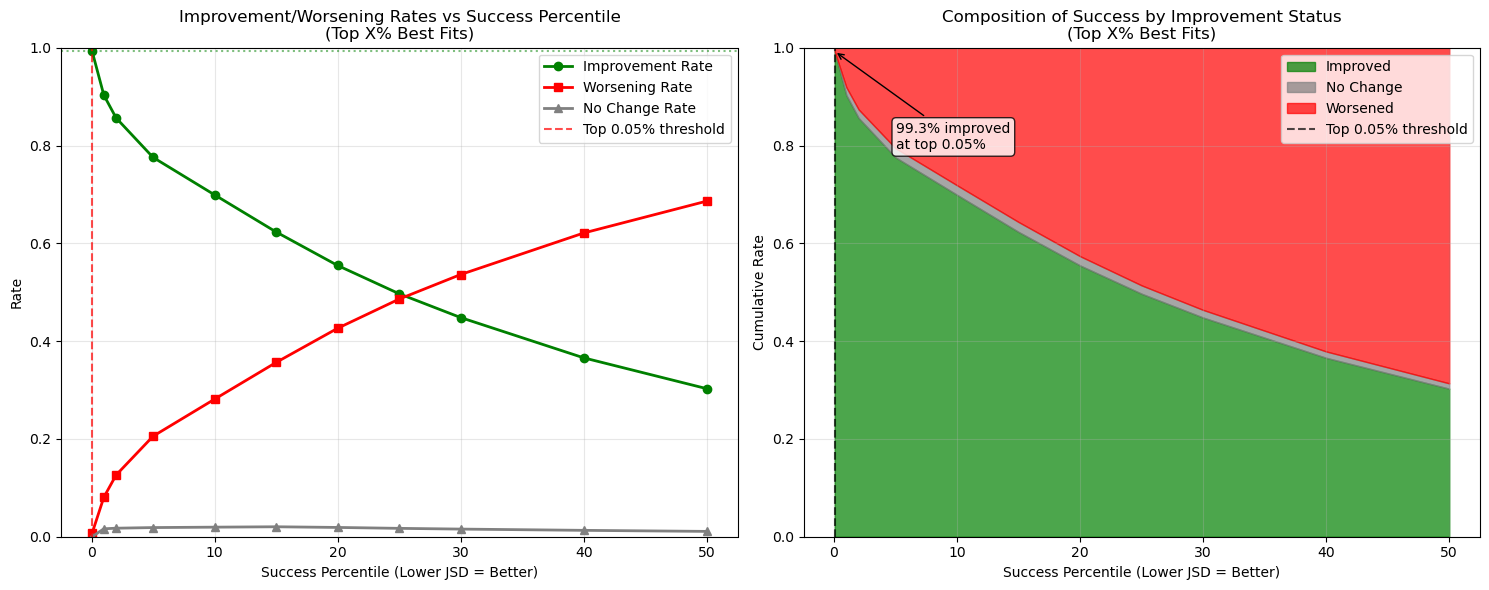

   Visualization insights:
   • Shows how improvement rates change across success levels
   • Green area = genuine improvement, Red area = worsening
   • Look for whether top fits have higher improvement rates

################################################################################
CRITICAL ASSESSMENT
################################################################################
TOP 0.05% SIMULATIONS:
• 99.3% at 0.05% show GENUINE IMPROVEMENT
• 0.7% actually WORSENED
• 0.0% had NO CHANGE

✅ ACCEPTABLE: 99.3% of top simulations show genuine improvement
   Success appears to be driven by meaningful dynamics


In [37]:
def analyze_improvement_vs_success(config):
    """
    Analyze the percentage of improved simulations across different success percentiles
    Without sampling to get accurate results
    """
    print(f"\n{'#'*80}")
    print("IMPROVEMENT RATE VS SUCCESS PERCENTILE ANALYSIS")
    print(f"{'#'*80}")
    
    # Load data efficiently - only needed columns
    model_idx = config['model_number'] - 1
    df = js_fits_stepwise_with_success[model_idx][['epsM', 'distance_delta', 'distance_final']].copy()
    
    print(f"Analyzing ALL {len(df):,} simulations from Model {config['model_number']}")
    print(f"Negative delta = Improvement, Positive delta = Worsening")
    
    # Get success_percentile from config (convert to int if needed)
    success_percentile = (config['success_percentile'])  # Ensure it's an integer
    
    # Define percentiles to analyze - include the success_percentile
    percentiles = [1, 2, 5, 10, 15, 20, 25, 30, 40, 50, 60, 70, 80, 90, 95, 99]
    
    # Make sure our success_percentile is in the list
    if success_percentile not in percentiles:
        percentiles.append(success_percentile)
        percentiles.sort()
    
    results = []
    
    print(f"\n1. IMPROVEMENT RATES ACROSS SUCCESS PERCENTILES")
    print("   Percentile | Threshold JSD | Total Sims | Improved | Improv Rate | Worse Rate | No Change")
    print("   " + "-" * 95)
    
    for percentile in percentiles:
        # Calculate threshold for this percentile
        if percentile <= 50:
            # For top percentiles, use lower quantile
            threshold = df['distance_final'].quantile(percentile / 100)
            top_sims = df[df['distance_final'] <= threshold]
            description = f"Top {percentile}%"
        else:
            # For bottom percentiles, use upper quantile  
            threshold = df['distance_final'].quantile(percentile / 100)
            top_sims = df[df['distance_final'] >= threshold]
            description = f"Bottom {100-percentile}%"
        
        # Calculate improvement metrics
        total_sims = len(top_sims)
        improved = (top_sims['distance_delta'] < 0).sum()
        worsened = (top_sims['distance_delta'] > 0).sum()
        no_change = (top_sims['distance_delta'] == 0).sum()
        
        improvement_rate = improved / total_sims if total_sims > 0 else 0
        worsening_rate = worsened / total_sims if total_sims > 0 else 0
        no_change_rate = no_change / total_sims if total_sims > 0 else 0
        
        results.append({
            'percentile': percentile,
            'description': description,
            'threshold_jsd': threshold,
            'total_sims': total_sims,
            'improved': improved,
            'improvement_rate': improvement_rate,
            'worsening_rate': worsening_rate,
            'no_change_rate': no_change_rate
        })
        
        # Print all percentiles since we have a manageable number
        print(f"   {description:11} | {threshold:12.4f} | {total_sims:10,} | {improved:8,} | {improvement_rate:11.1%} | {worsening_rate:10.1%} | {no_change_rate:9.1%}")
    
    # 2. Focus on the critical success_percentile threshold
    print(f"\n2. DETAILED ANALYSIS OF TOP {success_percentile}%")
    
    success_threshold = df['distance_final'].quantile(success_percentile / 100)
    top_success_sims = df[df['distance_final'] <= success_threshold]
    
    print(f"   Top {success_percentile}% threshold JSD: {success_threshold:.4f}")
    print(f"   Simulations in top {success_percentile}%: {len(top_success_sims):,}")
    
    # Detailed breakdown
    improved_detail = top_success_sims[top_success_sims['distance_delta'] < 0]
    worsened_detail = top_success_sims[top_success_sims['distance_delta'] > 0]
    no_change_detail = top_success_sims[top_success_sims['distance_delta'] == 0]
    
    print(f"\n   Detailed breakdown:")
    print(f"   • Improved (negative delta):   {len(improved_detail):,} ({(len(improved_detail)/len(top_success_sims))*100:.1f}%)")
    print(f"   • Worsened (positive delta):   {len(worsened_detail):,} ({(len(worsened_detail)/len(top_success_sims))*100:.1f}%)")
    print(f"   • No change (zero delta):      {len(no_change_detail):,} ({(len(no_change_detail)/len(top_success_sims))*100:.1f}%)")
    
    # 3. Compare with overall population
    print(f"\n3. COMPARISON WITH OVERALL POPULATION")
    
    overall_improvement = (df['distance_delta'] < 0).mean()
    overall_worsening = (df['distance_delta'] > 0).mean()
    overall_no_change = (df['distance_delta'] == 0).mean()
    
    top_improvement = (top_success_sims['distance_delta'] < 0).mean()
    
    print(f"   Overall population:")
    print(f"   • Improvement rate: {overall_improvement:.1%}")
    print(f"   • Worsening rate:   {overall_worsening:.1%}")
    print(f"   • No change rate:   {overall_no_change:.1%}")
    
    print(f"\n   Top {success_percentile}% simulations:")
    print(f"   • Improvement rate: {top_improvement:.1%}")
    
    if top_improvement > overall_improvement:
        print(f"   ✓ Top simulations have HIGHER improvement rate than overall")
    else:
        print(f"   ✗ Top simulations have LOWER improvement rate than overall")
    
    # 4. Create visualization
    print(f"\n4. CREATING VISUALIZATION")
    create_improvement_vs_percentile_plot(results, success_percentile)
    
    # 5. Critical assessment
    print(f"\n{'#'*80}")
    print("CRITICAL ASSESSMENT")
    print(f"{'#'*80}")
    
    top_result = next(r for r in results if r['percentile'] == success_percentile)
    improvement_rate_top = top_result['improvement_rate']
    worsening_rate_top = top_result['worsening_rate']
    
    print(f"TOP {success_percentile}% SIMULATIONS:")
    print(f"• {improvement_rate_top:.1%} at {success_percentile}% show GENUINE IMPROVEMENT")
    print(f"• {worsening_rate_top:.1%} actually WORSENED")
    print(f"• {top_result['no_change_rate']:.1%} had NO CHANGE")
    
    if improvement_rate_top < 0.3:
        print(f"\n🚨 CRITICAL CONCERN: Only {improvement_rate_top:.1%} of top simulations show genuine improvement!")
        print(f"   Majority of 'success' appears to be from lucky initial conditions")
        print(f"   STRONGLY recommend filtering out non-improving simulations")
    elif improvement_rate_top < 0.5:
        print(f"\n🚩 HIGH CONCERN: Only {improvement_rate_top:.1%} of top simulations show genuine improvement")
        print(f"   Significant portion of success may be artificial")
        print(f"   Recommend filtering simulations with delta >= 0")
    elif improvement_rate_top < 0.7:
        print(f"\n⚠️  MODERATE CONCERN: {improvement_rate_top:.1%} of top simulations show genuine improvement")
        print(f"   Some artificial success likely present")
    else:
        print(f"\n✅ ACCEPTABLE: {improvement_rate_top:.1%} of top simulations show genuine improvement")
        print(f"   Success appears to be driven by meaningful dynamics")
    
    # Check if worsening rate is concerning
    if worsening_rate_top > 0.3:
        print(f"\n🔴 ADDITIONAL CONCERN: {worsening_rate_top:.1%} of top simulations actually WORSENED")
        print(f"   These simulations got worse but still ended up in top {success_percentile}%")
        print(f"   This suggests very lucky initial conditions")
    
    return {
        'results': results,
        'top_details': {
            'threshold': success_threshold,
            'total_sims': len(top_success_sims),
            'improved': len(improved_detail),
            'worsened': len(worsened_detail),
            'no_change': len(no_change_detail),
            'improvement_rate': improvement_rate_top,
            'worsening_rate': worsening_rate_top
        },
        'overall_rates': {
            'improvement': overall_improvement,
            'worsening': overall_worsening,
            'no_change': overall_no_change
        }
    }

def create_improvement_vs_percentile_plot(results, success_percentile):
    """
    Create visualization of improvement rates across percentiles
    """
    import matplotlib.pyplot as plt
    
    # Filter for top percentiles only (up to 50%)
    top_results = [r for r in results if r['percentile'] <= 50]
    
    # Sort by percentile
    top_results.sort(key=lambda x: x['percentile'])
    
    percentiles = [r['percentile'] for r in top_results]
    improvement_rates = [r['improvement_rate'] for r in top_results]
    worsening_rates = [r['worsening_rate'] for r in top_results]
    no_change_rates = [r['no_change_rate'] for r in top_results]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Plot 1: Improvement rate vs percentile
    ax1.plot(percentiles, improvement_rates, 'g-', linewidth=2, label='Improvement Rate', marker='o')
    ax1.plot(percentiles, worsening_rates, 'r-', linewidth=2, label='Worsening Rate', marker='s')
    ax1.plot(percentiles, no_change_rates, 'gray', linewidth=2, label='No Change Rate', marker='^')
    
    # Highlight the success_percentile threshold
    if success_percentile in percentiles:
        success_idx = percentiles.index(success_percentile)
        ax1.axvline(x=success_percentile, color='red', linestyle='--', alpha=0.7, 
                    label=f'Top {success_percentile}% threshold')
        ax1.axhline(y=improvement_rates[success_idx], color='green', linestyle=':', alpha=0.5)
    
    ax1.set_xlabel('Success Percentile (Lower JSD = Better)')
    ax1.set_ylabel('Rate')
    ax1.set_title('Improvement/Worsening Rates vs Success Percentile\n(Top X% Best Fits)')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim(0, 1)
    
    # Plot 2: Stacked area chart
    x = percentiles
    y1 = improvement_rates
    y2 = no_change_rates
    y3 = worsening_rates
    
    ax2.fill_between(x, 0, y1, alpha=0.7, label='Improved', color='green')
    ax2.fill_between(x, y1, [y1[i] + y2[i] for i in range(len(y1))], alpha=0.7, label='No Change', color='gray')
    ax2.fill_between(x, [y1[i] + y2[i] for i in range(len(y1))], 1, alpha=0.7, label='Worsened', color='red')
    
    if success_percentile in percentiles:
        ax2.axvline(x=success_percentile, color='black', linestyle='--', alpha=0.7, 
                    label=f'Top {success_percentile}% threshold')
    
    ax2.set_xlabel('Success Percentile (Lower JSD = Better)')
    ax2.set_ylabel('Cumulative Rate')
    ax2.set_title('Composition of Success by Improvement Status\n(Top X% Best Fits)')
    ax2.legend(loc='upper right')
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim(0, 1)
    
    # Add annotation for the success_percentile point
    if success_percentile in percentiles:
        success_idx = percentiles.index(success_percentile)
        improvement_at_target = improvement_rates[success_idx]
        ax2.annotate(f'{improvement_at_target:.1%} improved\nat top {success_percentile}%',
                    xy=(success_percentile, improvement_at_target),
                    xytext=(success_percentile + 5, improvement_at_target - 0.2),
                    arrowprops=dict(arrowstyle='->', color='black'),
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
    
    plt.tight_layout()
    plt.show()
    
    # Print key insights from the plot
    print(f"   Visualization insights:")
    print(f"   • Shows how improvement rates change across success levels")
    print(f"   • Green area = genuine improvement, Red area = worsening")
    print(f"   • Look for whether top fits have higher improvement rates")

# Run the analysis
improvement_analysis_results = analyze_improvement_vs_success(CONFIG)

## Understanding Silence By Boundary
This is a design choice parameter. We would like to know whetehr we get better fits when the silence criteria is same is the HK criteria (TRUE) or using a signed interpretation of opinion.
If this variable is true, it means that agents exhibit silence in response to a lot of incoming opinions from beyond their HK boundary.
If this is false, it means that agents exhibit silence in response to a lot of incoming opinions from the opposite signage.

The design choice has implications on how one interprets the opinions fundamentally -- in particular the focus on signage in the False variant implies that opinions are binary on some level (the magnitude may be interpeted as confidence of some sort).

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def analyze_silence_by_boundary_effect(model_number=6):
    """
    Analyze the effect of SilenceByBoundary parameter on model performance
    """
    print(f"Analyzing SilenceByBoundary effect for Model {model_number}")
    
    # Load the model data
    model_idx = model_number - 1
    df = js_fits_stepwise_with_success[model_idx].copy()
    
    # Check if SilenceByBoundary exists in this model
    if 'SilenceByBoundary' not in df.columns:
        print("SilenceByBoundary not found in model data")
        return
    
    # Convert to boolean if needed
    df['SilenceByBoundary'] = df['SilenceByBoundary'].astype(bool)
    
    print(f"Total rows: {len(df):,}")
    print(f"SilenceByBoundary distribution:")
    print(df['SilenceByBoundary'].value_counts())
    
    # Plot 1: Overall JSD distributions
    plt.figure(figsize=(12, 5))
    
    # Subplot 1: Histogram of JSD distributions
    plt.subplot(1, 2, 1)
    
    # Get data for both conditions
    jsd_true = df[df['SilenceByBoundary'] == True]['distance_final']
    jsd_false = df[df['SilenceByBoundary'] == False]['distance_final']
    
    # Plot histograms
    plt.hist(jsd_true, bins=50, alpha=0.7, label='SilenceByBoundary=True', 
             color='skyblue', density=True)
    plt.hist(jsd_false, bins=50, alpha=0.7, label='SilenceByBoundary=False', 
             color='lightcoral', density=True)
    
    # Add mean lines
    mean_true = jsd_true.mean()
    mean_false = jsd_false.mean()
    plt.axvline(mean_true, color='blue', linestyle='--', alpha=0.8, 
                label=f'True mean: {mean_true:.3f}')
    plt.axvline(mean_false, color='red', linestyle='--', alpha=0.8, 
                label=f'False mean: {mean_false:.3f}')
    
    plt.xlabel('Jensen-Shannon Divergence (JSD)')
    plt.ylabel('Density')
    plt.title('JSD Distribution by SilenceByBoundary\n(Model 6)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Subplot 2: Success rates at different percentiles
    plt.subplot(1, 2, 2)
    
    # Define success percentiles to test
    percentiles = [0.1, 0.5, 1, 2, 5, 10, 15, 20, 25]
    success_rates_true = []
    success_rates_false = []
    
    for percentile in percentiles:
        # Calculate threshold for this percentile
        threshold = df['distance_final'].quantile(percentile / 100)
        
        # Calculate success rates
        success_true = (df[df['SilenceByBoundary'] == True]['distance_final'] <= threshold).mean() * 100
        success_false = (df[df['SilenceByBoundary'] == False]['distance_final'] <= threshold).mean() * 100
        
        success_rates_true.append(success_true)
        success_rates_false.append(success_false)
    
    # Plot success rates
    plt.plot(percentiles, success_rates_true, 'o-', label='SilenceByBoundary=True', 
             color='blue', linewidth=2, markersize=6)
    plt.plot(percentiles, success_rates_false, 'o-', label='SilenceByBoundary=False', 
             color='red', linewidth=2, markersize=6)
    
    plt.xlabel('Success Percentile Threshold (%)')
    plt.ylabel('Success Rate (%)')
    plt.title('Success Rate vs Percentile Threshold\n(Model 6)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Add some annotations for key percentiles
    for i, p in enumerate([1, 5, 10]):
        plt.annotate(f'{success_rates_true[i]:.1f}%', 
                    (percentiles[i], success_rates_true[i]), 
                    textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)
        plt.annotate(f'{success_rates_false[i]:.1f}%', 
                    (percentiles[i], success_rates_false[i]), 
                    textcoords="offset points", xytext=(0,-15), ha='center', fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    # Print statistical summary
    print(f"\nSTATISTICAL SUMMARY:")
    print(f"SilenceByBoundary=True:")
    print(f"  Count: {len(jsd_true):,}")
    print(f"  Mean JSD: {mean_true:.4f}")
    print(f"  Std JSD: {jsd_true.std():.4f}")
    print(f"  Median JSD: {jsd_true.median():.4f}")
    
    print(f"SilenceByBoundary=False:")
    print(f"  Count: {len(jsd_false):,}")
    print(f"  Mean JSD: {mean_false:.4f}")
    print(f"  Std JSD: {jsd_false.std():.4f}")
    print(f"  Median JSD: {jsd_false.median():.4f}")
    
    # Statistical test
    from scipy import stats as spstats
    t_stat, p_value = spstats.ttest_ind(jsd_true, jsd_false, equal_var=False)
    print(f"\nStatistical Test (Welch's t-test):")
    print(f"  t-statistic: {t_stat:.4f}")
    print(f"  p-value: {p_value:.4f}")
    print(f"  Significant difference: {'YES' if p_value < 0.05 else 'NO'}")
    
    # Success rate comparison at key percentiles
    print(f"\nSUCCESS RATE COMPARISON:")
    key_percentiles = [1, 5, 10]
    for p in key_percentiles:
        threshold = df['distance_final'].quantile(p / 100)
        success_true = (jsd_true <= threshold).mean() * 100
        success_false = (jsd_false <= threshold).mean() * 100
        advantage = success_true - success_false
        
        print(f"  Top {p}%:")
        print(f"    True: {success_true:.2f}%")
        print(f"    False: {success_false:.2f}%")
        print(f"    Advantage: {advantage:+.2f}%")
    
    return {
        'jsd_true': jsd_true,
        'jsd_false': jsd_false,
        'success_rates_true': success_rates_true,
        'success_rates_false': success_rates_false,
        'percentiles': percentiles
    }

# Run the analysis
results = analyze_silence_by_boundary_effect(6)

# Additional analysis: Country-specific effects
def analyze_silence_by_boundary_by_country(model_number=6, top_countries=10):
    """
    Analyze SilenceByBoundary effect across different countries
    """
    print(f"\n{'#'*80}")
    print("COUNTRY-SPECIFIC ANALYSIS")
    print(f"{'#'*80}")
    
    model_idx = model_number - 1
    df = js_fits_stepwise_with_success[model_idx].copy()
    df['SilenceByBoundary'] = df['SilenceByBoundary'].astype(bool)
    
    # Get countries with sufficient data
    country_counts = df['country'].value_counts()
    countries_to_analyze = country_counts.head(top_countries).index
    
    country_results = []
    
    for country in countries_to_analyze:
        country_data = df[df['country'] == country]
        if len(country_data) < 100:  # Minimum data threshold
            continue
            
        jsd_true = country_data[country_data['SilenceByBoundary'] == True]['distance_final']
        jsd_false = country_data[country_data['SilenceByBoundary'] == False]['distance_final']
        
        if len(jsd_true) < 10 or len(jsd_false) < 10:
            continue
            
        mean_true = jsd_true.mean()
        mean_false = jsd_false.mean()
        advantage = mean_false - mean_true  # Positive means True is better (lower JSD)
        
        # Success rate at 5% threshold
        threshold = country_data['distance_final'].quantile(0.05)
        success_true = (jsd_true <= threshold).mean() * 100 if len(jsd_true) > 0 else 0
        success_false = (jsd_false <= threshold).mean() * 100 if len(jsd_false) > 0 else 0
        success_advantage = success_true - success_false
        
        country_results.append({
            'country': country,
            'samples': len(country_data),
            'mean_true': mean_true,
            'mean_false': mean_false,
            'advantage': advantage,
            'success_true': success_true,
            'success_false': success_false,
            'success_advantage': success_advantage
        })
    
    # Sort by advantage
    country_results.sort(key=lambda x: x['advantage'], reverse=True)
    
    print(f"Country-specific performance (sorted by JSD advantage):")
    print(f"{'Country':<10} {'Samples':<8} {'Mean_True':<10} {'Mean_False':<10} {'Advantage':<10} {'Success_T':<10} {'Success_F':<10} {'S_Advantage':<10}")
    print("-" * 90)
    
    for result in country_results:
        print(f"{result['country']:<10} {result['samples']:<8} {result['mean_true']:.4f}    {result['mean_false']:.4f}    {result['advantage']:+.4f}    "
              f"{result['success_true']:.1f}%      {result['success_false']:.1f}%      {result['success_advantage']:+.1f}%")
    
    # Plot country comparison
    plt.figure(figsize=(12, 6))
    
    countries = [r['country'] for r in country_results]
    advantages = [r['advantage'] for r in country_results]
    
    colors = ['green' if adv > 0 else 'red' for adv in advantages]
    
    plt.bar(countries, advantages, color=colors, alpha=0.7)
    plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
    plt.xlabel('Country')
    plt.ylabel('JSD Advantage (False - True)')
    plt.title('SilenceByBoundary Advantage by Country\n(Positive = True performs better)')
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    
    # Add value labels on bars
    for i, v in enumerate(advantages):
        plt.text(i, v + (0.001 if v >= 0 else -0.003), f'{v:.4f}', 
                ha='center', va='bottom' if v >= 0 else 'top', fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    return country_results

# Run country-specific analysis
country_results = analyze_silence_by_boundary_by_country(6)

print(f"\n{'#'*80}")
print("RECOMMENDATION SUMMARY")
print(f"{'#'*80}")

# Overall recommendation
overall_advantage = results['jsd_false'].mean() - results['jsd_true'].mean()
if overall_advantage > 0:
    print("✓ RECOMMENDATION: Use SilenceByBoundary = True")
    print(f"  Reason: Overall JSD advantage of {overall_advantage:.4f}")
else:
    print("✓ RECOMMENDATION: Use SilenceByBoundary = False") 
    print(f"  Reason: Overall JSD advantage of {-overall_advantage:.4f}")

# Check consistency across countries
consistent_countries = sum(1 for r in country_results if r['advantage'] * overall_advantage > 0)
total_countries = len(country_results)
consistency = consistent_countries / total_countries * 100

print(f"  Consistency across countries: {consistency:.1f}% ({consistent_countries}/{total_countries})")

# Another Detour -- MDS Analysis with our survey data

We have thus far established that:
1. Our model can fit the data very well in some subspaces of our parameter space.
2. (haven't shown this yet tbh) that this 'good space' is largely contiguous.
3. Some of our model parameters are more important than others in determining fit. Some don't seem to matter at all.
4. Fitting isn't driven by initial opinion distribution even when epsilon is low, our simulation matters!

The main questions we aim to answer now are:
1. Is our model capable of producing a variety of realistic distributions -- what is its coverage like across the survey data MDS?
2. How much does the diversity in the good simulation parameter space matter? Do large distances in the survey space map to large distances in the simulation spaces that simulate them well?

## First save the best fits for each survey for easy access


In [14]:
def save_best_fits_simple(config, n_best=10):
    """
    Simple version that saves to current working directory
    """
    save_path = '.'  # Current directory
    
    for model_number in range(1, 7):
        print(f"Processing Model {model_number}...")
        
        try:
            config['model_number'] = model_number
            model_idx = model_number - 1
            
            fits_df = js_fits_stepwise_with_success[model_idx].copy()
            
            # Simple processing
            country_col = 'country'
            year_col = 'year'
            
            unique_combinations = fits_df[[country_col, year_col]].drop_duplicates()
            best_fits_list = []
            
            for _, combo in unique_combinations.iterrows():
                country = combo[country_col]
                year = combo[year_col]
                
                mask = (fits_df[country_col] == country) & (fits_df[year_col] == year)
                country_year_fits = fits_df[mask].sort_values('distance_final').head(n_best).copy()
                
                if len(country_year_fits) > 0:
                    country_year_fits['model_number'] = model_number
                    country_year_fits['country'] = country
                    country_year_fits['year'] = year
                    country_year_fits['rank_within_country_year'] = range(1, len(country_year_fits) + 1)
                    best_fits_list.append(country_year_fits)
            
            if best_fits_list:
                model_best_fits = pd.concat(best_fits_list, ignore_index=True)
                
                # Save as CSV (more reliable than parquet)
                filename = f"best_fits_model_{model_number}_top_{n_best}.csv"
                model_best_fits.to_csv(filename, index=False)
                print(f"✓ Saved {len(model_best_fits)} rows to {filename}")
        
        except Exception as e:
            print(f"✗ Error with Model {model_number}: {e}")
    
    # List all created files
    print(f"\nCreated files:")
    for f in os.listdir('.'):
        if f.startswith('best_fits') and f.endswith('.csv'):
            print(f"  {f}")

# Try the simple version
save_best_fits_simple(CONFIG, n_best=10)

Processing Model 1...
✓ Saved 4550 rows to best_fits_model_1_top_10.csv
Processing Model 2...
✓ Saved 4550 rows to best_fits_model_2_top_10.csv
Processing Model 3...
✓ Saved 4530 rows to best_fits_model_3_top_10.csv
Processing Model 4...
✓ Saved 4550 rows to best_fits_model_4_top_10.csv
Processing Model 5...
✓ Saved 4490 rows to best_fits_model_5_top_10.csv
Processing Model 6...
✓ Saved 4550 rows to best_fits_model_6_top_10.csv

Created files:
  best_fits_model_1_top_10.csv
  best_fits_model_2_top_10.csv
  best_fits_model_3_top_10.csv
  best_fits_model_4_top_10.csv
  best_fits_model_5_top_10.csv
  best_fits_model_6_top_10.csv



################################################################################
MDS BEST-FIT ANALYSIS PIPELINE
################################################################################

################################################################################
CALCULATING BEST-FIT PERCENTILES FOR COUNTRY-YEAR COMBINATIONS
################################################################################
Loaded 58,351,104 simulation fits
Loaded 440 MDS survey points
Potential survey identifier columns: ['country', 'year']
Found 455 unique country-year combinations

Processed 452 country-year combinations
Average best-fit percentile: 99.7%
Range: 85.2% to 100.0%

################################################################################
CREATING MDS VISUALIZATION WITH BEST-FIT QUALITY
################################################################################
Merged data points: 437

INSIGHTS FROM MDS FIT VISUALIZATION:
• Average fit quality: 99.7%
• Average absol

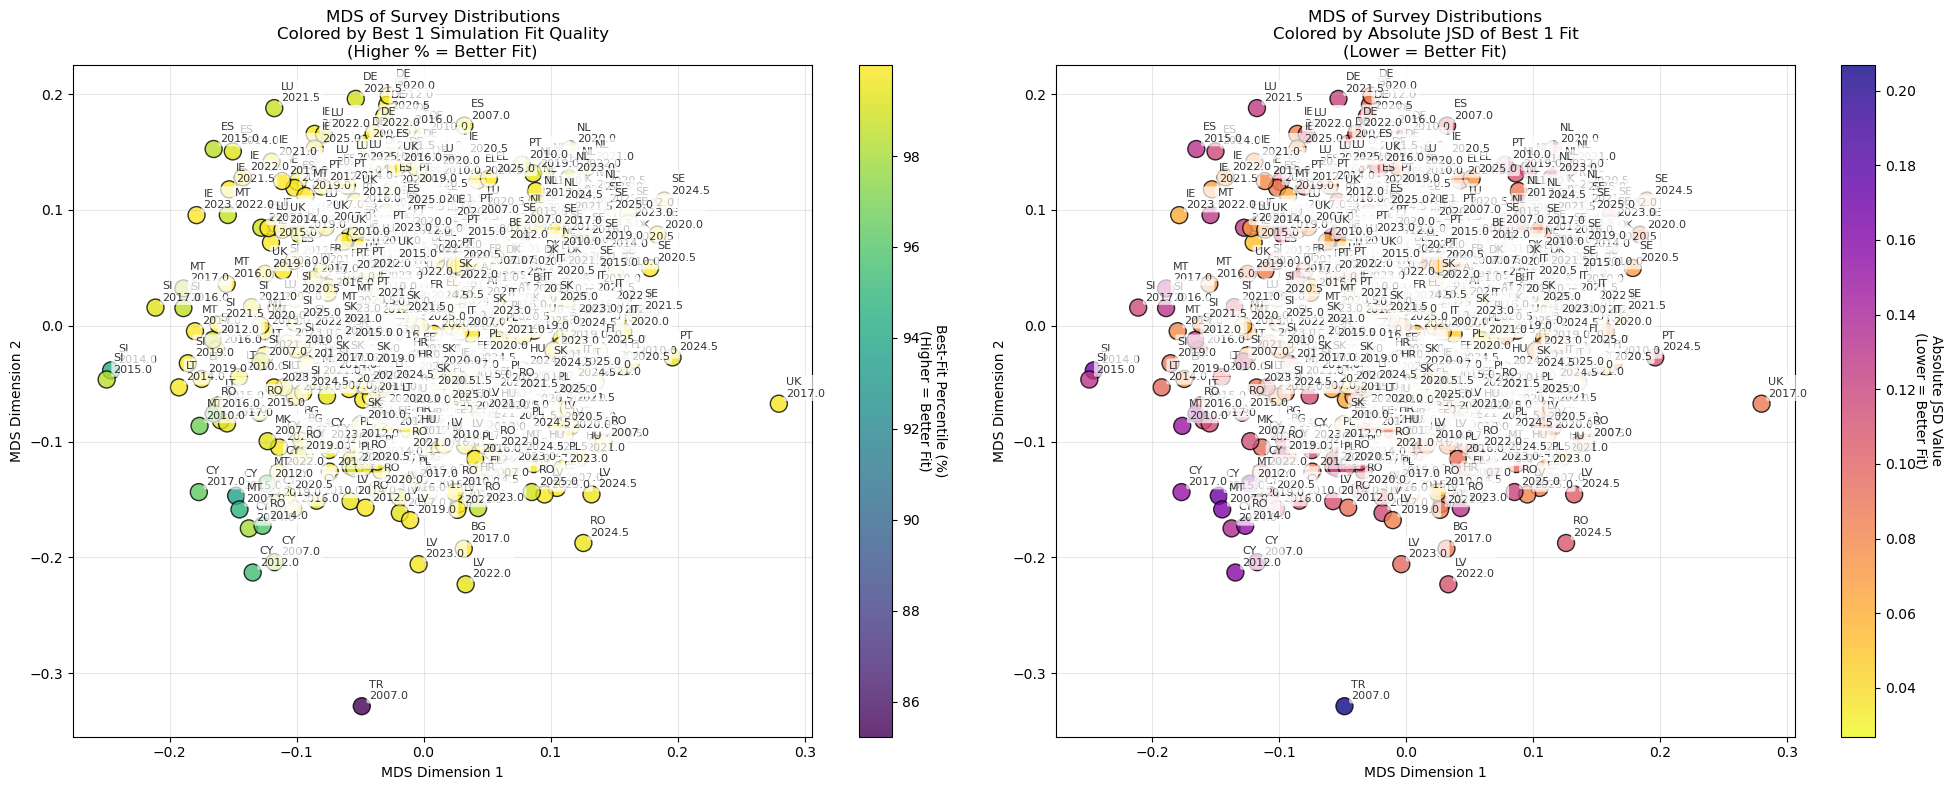

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def calculate_best_fit_percentiles(config, n_best=1):
    """
    For each country-year combination, find the n best-fitting simulations
    and calculate their average percentile (inverted so higher = better)
    """
    print(f"\n{'#'*80}")
    print("CALCULATING BEST-FIT PERCENTILES FOR COUNTRY-YEAR COMBINATIONS")
    print(f"{'#'*80}")
    
    # Load the simulation fits data
    model_idx = config['model_number'] - 1
    fits_df = js_fits_stepwise_with_success[model_idx].copy()
    
    # Load the MDS survey data
    mds_df = pd.read_csv(os.path.join(full_preprocessed_data_folder_path,'mds_survey_distributions_results_ignoring_DK_Refus.csv'))
    
    print(f"Loaded {len(fits_df):,} simulation fits")
    print(f"Loaded {len(mds_df):,} MDS survey points")
    
    # Extract unique country-year combinations from fits data
    # Assuming the fits data has columns that identify the survey being compared
    # Let's assume the structure based on your earlier description
    
    # Get unique survey identifiers - you'll need to adjust this based on your actual column names
    # Common patterns might be: 'country', 'year', 'survey_id', etc.
    survey_columns = [col for col in fits_df.columns if any(keyword in col.lower() 
                     for keyword in ['country', 'year', 'survey'])]
    
    print(f"Potential survey identifier columns: {survey_columns}")
    
    # For this example, I'll assume the structure. You'll need to adjust:
    # Let's assume we have columns like 'target_country' and 'target_year'
    country_col = 'country'  # Adjust based on your actual column name
    year_col = 'year'        # Adjust based on your actual column name
    
    if country_col not in fits_df.columns or year_col not in fits_df.columns:
        # If the expected columns don't exist, let's find alternatives
        print("Looking for alternative column names...")
        # You'll need to specify the actual column names in your data
        raise ValueError("Please specify the actual column names for country and year identifiers")
    
    # Get unique country-year combinations from fits
    unique_combinations = fits_df[[country_col, year_col]].drop_duplicates()
    print(f"Found {len(unique_combinations)} unique country-year combinations")
    
    results = []
    
    for _, combo in unique_combinations.iterrows():
        country = combo[country_col]
        year = combo[year_col]
        
        # Filter simulations for this specific country-year
        mask = (fits_df[country_col] == country) & (fits_df[year_col] == year)
        country_year_fits = fits_df[mask].copy()
        
        if len(country_year_fits) == 0:
            continue
        
        # Sort by JSD (ascending - lower is better)
        country_year_fits = country_year_fits.sort_values('distance_final')
        
        # Take the n best fits
        best_fits = country_year_fits.head(n_best)
        
        # Calculate percentiles (inverted: 1% becomes 99% since lower JSD is better)
        if 'jsd_percentile' in best_fits.columns:
            # If percentile column exists, use it directly
            percentiles = 100 - best_fits['jsd_percentile']
        else:
            # Calculate percentile manually
            all_jsd = fits_df['distance_final']
            percentiles = []
            for jsd in best_fits['distance_final']:
                # Percentile where this JSD is better than X% of all simulations
                better_than = (all_jsd > jsd).sum() / len(all_jsd) * 100
                percentiles.append(better_than)
        
        avg_percentile = np.mean(percentiles)
        
        results.append({
            'country': country,
            'year': year,
            'n_simulations': len(country_year_fits),
            'n_best_used': len(best_fits),
            'best_jsd': best_fits['distance_final'].min(),
            'avg_percentile': avg_percentile,
            'percentile_interpretation': f"Better than {avg_percentile:.1f}% of all simulations"
        })
    
    results_df = pd.DataFrame(results)
    
    print(f"\nProcessed {len(results_df)} country-year combinations")
    print(f"Average best-fit percentile: {results_df['avg_percentile'].mean():.1f}%")
    print(f"Range: {results_df['avg_percentile'].min():.1f}% to {results_df['avg_percentile'].max():.1f}%")
    
    return results_df, mds_df

def create_mds_fit_visualization(results_df, mds_df, n_best=1):
    """
    Create MDS plot colored by best-fit percentiles AND absolute JSD values
    """
    print(f"\n{'#'*80}")
    print("CREATING MDS VISUALIZATION WITH BEST-FIT QUALITY")
    print(f"{'#'*80}")
    
    # Merge the results with MDS data
    merged_df = mds_df.merge(
        results_df, 
        left_on=['country', 'year'], 
        right_on=['country', 'year'], 
        how='inner'
    )
    
    print(f"Merged data points: {len(merged_df)}")
    
    # Create the visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
    
    # Plot 1: Colored by percentile with colorbar (unchanged)
    scatter1 = ax1.scatter(
        merged_df['D1'], 
        merged_df['D2'], 
        c=merged_df['avg_percentile'],
        cmap='viridis', 
        s=150, 
        alpha=0.8,
        edgecolors='black',
        linewidth=1
    )
    
    cbar1 = plt.colorbar(scatter1, ax=ax1)
    cbar1.set_label('Best-Fit Percentile (%)\n(Higher = Better Fit)', rotation=270, labelpad=20)
    
    # Add country-year labels
    for idx, row in merged_df.iterrows():
        ax1.annotate(
            f"{row['country']}\n{row['year']}", 
            (row['D1'], row['D2']),
            xytext=(5, 5),
            textcoords='offset points',
            fontsize=8,
            alpha=0.8,
            bbox=dict(boxstyle="round,pad=0.2", facecolor='white', alpha=0.7, edgecolor='none')
        )
    
    ax1.set_xlabel('MDS Dimension 1')
    ax1.set_ylabel('MDS Dimension 2')
    ax1.set_title(f'MDS of Survey Distributions\nColored by Best {n_best} Simulation Fit Quality\n(Higher % = Better Fit)')
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Colored by ABSOLUTE JSD VALUES (NEW)
    scatter2 = ax2.scatter(
        merged_df['D1'], 
        merged_df['D2'], 
        c=merged_df['best_jsd'],  # Absolute JSD values
        cmap='plasma_r',  # Reversed colormap (darker = worse fit)
        s=150, 
        alpha=0.8,
        edgecolors='black',
        linewidth=1
    )
    
    # Add colorbar for JSD values
    cbar2 = plt.colorbar(scatter2, ax=ax2)
    cbar2.set_label('Absolute JSD Value\n(Lower = Better Fit)', rotation=270, labelpad=20)
    
    # Add country-year labels for plot 2
    for idx, row in merged_df.iterrows():
        ax2.annotate(
            f"{row['country']}\n{row['year']}", 
            (row['D1'], row['D2']),
            xytext=(5, 5),
            textcoords='offset points',
            fontsize=8,
            alpha=0.8,
            bbox=dict(boxstyle="round,pad=0.2", facecolor='white', alpha=0.7, edgecolor='none')
        )
    
    ax2.set_xlabel('MDS Dimension 1')
    ax2.set_ylabel('MDS Dimension 2')
    ax2.set_title(f'MDS of Survey Distributions\nColored by Absolute JSD of Best {n_best} Fit\n(Lower = Better Fit)')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # Enhanced insights with JSD analysis
    print(f"\nINSIGHTS FROM MDS FIT VISUALIZATION:")
    print(f"• Average fit quality: {merged_df['avg_percentile'].mean():.1f}%")
    print(f"• Average absolute JSD: {merged_df['best_jsd'].mean():.4f}")
    print(f"• Best fit: {merged_df['avg_percentile'].max():.1f}% (JSD: {merged_df.loc[merged_df['avg_percentile'].idxmax(), 'best_jsd']:.4f})")
    print(f"• Worst fit: {merged_df['avg_percentile'].min():.1f}% (JSD: {merged_df.loc[merged_df['avg_percentile'].idxmin(), 'best_jsd']:.4f})")
    
    # Analyze spatial patterns with JSD
    good_fit_threshold_jsd = merged_df['best_jsd'].quantile(0.25)  # Best 25% of JSD values
    poor_fit_threshold_jsd = merged_df['best_jsd'].quantile(0.75)  # Worst 25% of JSD values
    
    good_fits = merged_df[merged_df['best_jsd'] <= good_fit_threshold_jsd]
    poor_fits = merged_df[merged_df['best_jsd'] >= poor_fit_threshold_jsd]
    
    print(f"\nJSD-BASED ANALYSIS:")
    print(f"• Good fits (JSD ≤ {good_fit_threshold_jsd:.4f}): {len(good_fits)} points")
    print(f"• Poor fits (JSD ≥ {poor_fit_threshold_jsd:.4f}): {len(poor_fits)} points")
    
    if len(good_fits) > 0:
        print(f"• Good fits cluster around MDS D1: [{good_fits['D1'].min():.2f}, {good_fits['D1'].max():.2f}]")
        print(f"• Good fits cluster around MDS D2: [{good_fits['D2'].min():.2f}, {good_fits['D2'].max():.2f}]")
    
    return fig, merged_df

def plot_filtered_mds_fit(merged_df, country_filter=None, year_range=None, n_best=1):
    """
    Plot filtered MDS with fit percentiles (adapted from your example code)
    """
    # Filter data
    filtered_data = merged_df.copy()
    
    if country_filter:
        filtered_data = filtered_data[filtered_data['country'].isin(country_filter)]
    
    if year_range:
        filtered_data = filtered_data[
            (filtered_data['year'] >= year_range[0]) & 
            (filtered_data['year'] <= year_range[1])
        ]
    
    print(f"Plotting {len(filtered_data)} points after filtering")
    
    # Create figure
    plt.figure(figsize=(16, 12))
    
    # Color by percentile
    scatter = plt.scatter(
        filtered_data['D1'], 
        filtered_data['D2'], 
        c=filtered_data['avg_percentile'],
        cmap='viridis', 
        s=200, 
        alpha=0.8,
        edgecolors='black',
        linewidth=1.5
    )
    
    # Add colorbar
    cbar = plt.colorbar(scatter)
    cbar.set_label('Best-Fit Percentile (%)\n(Higher = Better Fit)', rotation=270, labelpad=25)
    
    # Add labels with careful positioning
    for idx, row in filtered_data.iterrows():
        plt.annotate(
            f"{row['country']}\n{row['year']}", 
            (row['D1'], row['D2']),
            xytext=(0, 0), 
            textcoords='offset points',
            fontsize=9, 
            fontweight='bold',
            ha='center', 
            va='center',
            bbox=dict(
                boxstyle="round,pad=0.3", 
                facecolor='white', 
                alpha=0.9, 
                edgecolor='black', 
                linewidth=0.8
            )
        )
    
    plt.xlabel('MDS Dimension 1')
    plt.ylabel('MDS Dimension 2')
    
    # Build title
    filter_text = ""
    if country_filter:
        filter_text += f"Countries: {', '.join(country_filter)}"
    if year_range:
        if filter_text:
            filter_text += " | "
        filter_text += f"Years: {year_range[0]}-{year_range[1]}"
    
    title = f'MDS Visualization with Best {n_best} Simulation Fit Quality\n(Jensen-Shannon Distance)'
    if filter_text:
        title += f'\n{filter_text}'
    
    plt.title(title, fontsize=14)
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    return plt.gcf()

# Main execution
def run_mds_fit_analysis(config, n_best=1):
    """
    Complete MDS fit analysis pipeline
    """
    print(f"\n{'#'*80}")
    print("MDS BEST-FIT ANALYSIS PIPELINE")
    print(f"{'#'*80}")
    
    # Step 1: Calculate best-fit percentiles
    results_df, mds_df = calculate_best_fit_percentiles(config, n_best=n_best)
    
    # Step 2: Create comprehensive visualization
    fig, merged_df = create_mds_fit_visualization(results_df, mds_df, n_best=n_best)
    
    # Step 3: Show summary statistics
    print(f"\n{'#'*80}")
    print("SUMMARY STATISTICS")
    print(f"{'#'*80}")
    
    print(f"Overall fit quality distribution:")
    print(merged_df['avg_percentile'].describe())
    
    # Top 10 best-fitting country-years
    print(f"\nTop 10 best-fitting country-years:")
    top_10 = merged_df.nlargest(10, 'avg_percentile')[['country', 'year', 'avg_percentile', 'best_jsd']]
    for _, row in top_10.iterrows():
        print(f"  {row['country']} {row['year']}: {row['avg_percentile']:.1f}% (JSD: {row['best_jsd']:.4f})")
    
    # Bottom 10 worst-fitting country-years  
    print(f"\nBottom 10 worst-fitting country-years:")
    bottom_10 = merged_df.nsmallest(10, 'avg_percentile')[['country', 'year', 'avg_percentile', 'best_jsd']]
    for _, row in bottom_10.iterrows():
        print(f"  {row['country']} {row['year']}: {row['avg_percentile']:.1f}% (JSD: {row['best_jsd']:.4f})")
    
    return {
        'results_df': results_df,
        'merged_df': merged_df,
        'mds_df': mds_df,
        'figure': fig
    }

# Execute the analysis
mds_analysis_results = run_mds_fit_analysis(CONFIG, n_best=1)

# You can also create filtered plots like this:
# filtered_plot = plot_filtered_mds_fit(
#     mds_analysis_results['merged_df'],
#     country_filter=['AT', 'DE', 'FR'],  # Example filter
#     year_range=[2020, 2023]  # Example year range
# )

# FINALLY, The (Rather Ambitious) 2-Space Trajectory Analysis

## Creating A Data Structure for Traversal

In [ ]:
def build_traversal_graph(df, active_params, max_param_jump=1):
    """
    Build efficient graph structures for traversal
    Returns: country_year_graph, param_neighbors, success_nodes
    """
    
    # Filter to only successful nodes
    success_df = df[df['success_binary'] == 1].copy()
    print(f"Building graph from {len(success_df):,} successful nodes")
    
    # 1. Create country-year timeline structure
    country_years = {}
    for country in success_df['country'].unique():
        years = sorted(success_df[success_df['country'] == country]['year'].unique())
        country_years[country] = years
        print(f"  {country}: {len(years)} years ({min(years)}-{max(years)})")
    
    # 2. Create parameter value mappings and neighbors
    param_values = {}
    param_neighbors = {}
    
    for param in active_params:
        unique_vals = sorted(success_df[param].unique())
        param_values[param] = unique_vals
        
        # Precompute neighbors for each parameter value
        param_neighbors[param] = {}
        for i, val in enumerate(unique_vals):
            neighbors = set()
            # Include current value
            neighbors.add(val)
            # Include adjacent values within max_param_jump
            if i > 0 and (unique_vals[i] - unique_vals[i-1]) <= max_param_jump:
                neighbors.add(unique_vals[i-1])
            if i < len(unique_vals)-1 and (unique_vals[i+1] - unique_vals[i]) <= max_param_jump:
                neighbors.add(unique_vals[i+1])
            param_neighbors[param][val] = neighbors
    
    # 3. Create efficient lookup of successful nodes
    success_nodes = {}
    node_counter = 0
    
    for _, row in success_df.iterrows():
        node_id = node_counter
        node_counter += 1
        
        # Key by (country, year) for quick access
        country_year_key = (row['country'], row['year'])
        param_tuple = tuple(row[param] for param in active_params)
        
        if country_year_key not in success_nodes:
            success_nodes[country_year_key] = []
        
        success_nodes[country_year_key].append({
            'node_id': node_id,
            'params': param_tuple,
            'param_dict': {param: row[param] for param in active_params},
            'jsd': row['distance_final'],
            'percentile': row['jsd_percentile'],
            'sim_index': row['cumulative_simulation_index'],
            'random_seed': row['RandomSeed']
        })
    
    print(f"Created {node_counter:,} graph nodes")
    print(f"Average nodes per country-year: {node_counter / len(success_nodes):.1f}")
    
    return country_years, param_neighbors, success_nodes, success_df

# Build the graph for Model 5 (more manageable)
print("Building traversal graph for Model 5...")
model_5_df = js_fits_stepwise_with_success[4]  # Index 4 = Model 5
active_params_5 = all_results[5]['active_params']  # From your earlier analysis

country_years, param_neighbors, success_nodes, success_df_5 = build_traversal_graph(
    model_5_df, active_params_5, max_param_jump=1
)

## Analyzing Specific Countries -- Brute forcing so it takes forever

In [ ]:
# Complete analysis for NL and PL
print(f"{'#'*80}")
print("TRAJECTORY ANALYSIS FOR NETHERLANDS (NL) AND POLAND (PL)")
print(f"{'#'*80}")

# Build the graph for Model 5
print("Building traversal graph for Model 5...")
model_5_df = js_fits_stepwise_with_success[4]  # Index 4 = Model 5
active_params_5 = all_results[5]['active_params']  # From your earlier analysis

country_years, param_neighbors, success_nodes, success_df_5 = build_traversal_graph(
    model_5_df, active_params_5, max_param_jump=1
)

# Select specific countries
target_countries = df['country'].unique()
print(f"\nTarget countries: {target_countries}")

# Verify these countries exist in our data
available_countries = list(country_years.keys())
print(f"Available countries: {len(available_countries)}")
print(f"Countries with data: {sorted(available_countries)}")

for country in target_countries:
    if country in country_years:
        years = country_years[country]
        print(f"  {country}: {len(years)} years ({min(years)}-{max(years)})")
        # Show node counts per year
        for year in years:
            key = (country, year)
            if key in success_nodes:
                print(f"    {year}: {len(success_nodes[key])} nodes")
    else:
        print(f"  {country}: No data found")

# Enhanced traversal algorithm with better logging
def find_trajectories_for_country_detailed(country, country_years, success_nodes, param_neighbors, active_params, max_paths_per_start=20):
    """
    Find trajectories with detailed progress reporting
    """
    if country not in country_years:
        return []
    
    years = country_years[country]
    if len(years) < 2:
        print(f"  {country}: Only 1 year, skipping")
        return []
    
    print(f"\n  {country}: Searching trajectories across {len(years)} years ({years[0]} to {years[-1]})")
    
    all_trajectories = []
    start_year = years[0]
    
    # Get starting nodes for first year
    start_key = (country, start_year)
    start_nodes = success_nodes[start_key]
    print(f"    Starting with {len(start_nodes)} nodes in {start_year}")
    
    paths_explored = 0
    for i, start_node in enumerate(start_nodes[:max_paths_per_start]):
        if i % 5 == 0:  # Progress reporting
            print(f"      Processing start node {i+1}/{min(len(start_nodes), max_paths_per_start)}...")
        
        trajectories = dfs_traverse_detailed(
            start_node=start_node,
            current_year_idx=0,
            years=years,
            country=country,
            success_nodes=success_nodes,
            param_neighbors=param_neighbors,
            active_params=active_params,
            current_path=[start_node]
        )
        all_trajectories.extend(trajectories)
        paths_explored += len(trajectories)
    
    print(f"    Explored {paths_explored} total paths, found {len(all_trajectories)} complete trajectories")
    return all_trajectories

def dfs_traverse_detailed(start_node, current_year_idx, years, country, success_nodes, param_neighbors, active_params, current_path, max_depth=15):
    """
    Enhanced DFS with better progress tracking
    """
    if current_year_idx >= len(years) - 1:
        return [current_path]  # Reached the end
    
    if len(current_path) > max_depth:
        return []
    
    current_year = years[current_year_idx]
    next_year = years[current_year_idx + 1]
    next_key = (country, next_year)
    
    if next_key not in success_nodes:
        return []
    
    trajectories = []
    next_candidates = success_nodes[next_key]
    
    valid_transitions = 0
    for candidate in next_candidates:
        if is_valid_transition(start_node, candidate, param_neighbors, active_params):
            valid_transitions += 1
            new_path = current_path + [candidate]
            next_trajectories = dfs_traverse_detailed(
                start_node=candidate,
                current_year_idx=current_year_idx + 1,
                years=years,
                country=country,
                success_nodes=success_nodes,
                param_neighbors=param_neighbors,
                active_params=active_params,
                current_path=new_path,
                max_depth=max_depth
            )
            trajectories.extend(next_trajectories)
    
    return trajectories

def is_valid_transition(node1, node2, param_neighbors, active_params):
    """
    Check if transition between nodes is valid (max 1 parameter change of size 1)
    """
    changes = 0
    for param in active_params:
        val1 = node1['param_dict'][param]
        val2 = node2['param_dict'][param]
        
        if val1 != val2:
            # Check if val2 is in neighbors of val1
            if val2 not in param_neighbors[param][val1]:
                return False
            changes += 1
    
    # Allow staying same or changing exactly 1 parameter
    return changes <= 1

# Run analysis for NL and PL
print(f"\n{'#'*80}")
print("EXECUTING TRAJECTORY SEARCH")
print(f"{'#'*80}")

all_trajectories = {}
for country in target_countries:
    if country in country_years:
        trajectories = find_trajectories_for_country_detailed(
            country, country_years, success_nodes, param_neighbors, active_params_5,
            max_paths_per_start=30  # Increased for better coverage
        )
        all_trajectories[country] = trajectories
    else:
        print(f"Skipping {country} - no data")

# Enhanced pattern analysis
def analyze_trajectory_patterns_detailed(all_trajectories, active_params):
    """
    Detailed analysis of trajectory patterns
    """
    print(f"\n{'#'*80}")
    print("DETAILED TRAJECTORY PATTERN ANALYSIS")
    print(f"{'#'*80}")
    
    all_traj_list = []
    for country, trajectories in all_trajectories.items():
        for traj in trajectories:
            all_traj_list.append({'country': country, 'trajectory': traj})
    
    print(f"Total trajectories found: {len(all_traj_list)}")
    
    if not all_traj_list:
        print("No trajectories found to analyze")
        return None
    
    # Analyze by country
    for country in all_trajectories:
        trajectories = all_trajectories[country]
        if trajectories:
            lengths = [len(traj) for traj in trajectories]
            print(f"\n{country}:")
            print(f"  Trajectories: {len(trajectories)}")
            print(f"  Avg length: {np.mean(lengths):.1f} years")
            print(f"  Min length: {min(lengths)} years")
            print(f"  Max length: {max(lengths)} years")
            
            # Parameter analysis for this country
            param_changes_country = {param: 0 for param in active_params}
            for traj in trajectories:
                for param in active_params:
                    values = [node['param_dict'][param] for node in traj]
                    if len(set(values)) > 1:
                        param_changes_country[param] += 1
            
            print(f"  Parameter change frequency:")
            for param, count in param_changes_country.items():
                if count > 0:
                    pct = count / len(trajectories) * 100
                    print(f"    {param}: {count}/{len(trajectories)} ({pct:.1f}%)")
    
    # Overall parameter change analysis
    param_changes = {param: [] for param in active_params}
    traj_lengths = []
    
    for traj_data in all_traj_list:
        traj = traj_data['trajectory']
        traj_lengths.append(len(traj))
        
        for param in active_params:
            values = [node['param_dict'][param] for node in traj]
            unique_values = set(values)
            if len(unique_values) > 1:
                param_changes[param].append({
                    'country': traj_data['country'],
                    'values': values,
                    'start_value': values[0],
                    'end_value': values[-1],
                    'num_changes': len([1 for i in range(1, len(values)) if values[i] != values[i-1]])
                })
    
    print(f"\nOVERALL SUMMARY:")
    print(f"Average trajectory length: {np.mean(traj_lengths):.1f} ± {np.std(traj_lengths):.1f} years")
    
    print(f"\nPARAMETER CHANGE ANALYSIS:")
    for param in active_params:
        changes = param_changes[param]
        if changes:
            change_count = len(changes)
            total_trajs = len(all_traj_list)
            pct = change_count / total_trajs * 100
            
            # Analyze direction of changes
            increases = sum(1 for c in changes if c['end_value'] > c['start_value'])
            decreases = sum(1 for c in changes if c['end_value'] < c['start_value'])
            same = sum(1 for c in changes if c['end_value'] == c['start_value'])
            
            print(f"  {param}:")
            print(f"    Changed in {change_count}/{total_trajs} trajectories ({pct:.1f}%)")
            print(f"    Direction: ↑{increases} ↑ {decreases} ↓ {same} →")
            
            # Most common value sequences
            if changes:
                sequences = [tuple(c['values']) for c in changes]
                from collections import Counter
                common_sequences = Counter(sequences).most_common(3)
                print(f"    Common sequences: {common_sequences}")
    
    return param_changes

# Run detailed analysis
param_changes = analyze_trajectory_patterns_detailed(all_trajectories, active_params_5)

# Export trajectories for further analysis
def export_trajectories(all_trajectories, active_params, filename_suffix=""):
    """
    Export trajectory data to CSV for further analysis
    """
    export_data = []
    
    for country, trajectories in all_trajectories.items():
        for traj_idx, trajectory in enumerate(trajectories):
            for node_idx, node in enumerate(trajectory):
                row_data = {
                    'country': country,
                    'trajectory_id': f"{country}_{traj_idx}",
                    'year': list(country_years[country])[node_idx],
                    'year_index': node_idx,
                    'jsd': node['jsd'],
                    'jsd_percentile': node['percentile'],
                    'sim_index': node['sim_index'],
                    'random_seed': node['random_seed']
                }
                # Add parameter values
                for param in active_params:
                    row_data[param] = node['param_dict'][param]
                
                export_data.append(row_data)
    
    if export_data:
        export_df = pd.DataFrame(export_data)
        filename = f'trajectories_NL_PL{filename_suffix}.csv'
        export_df.to_csv(filename, index=False)
        print(f"\nExported {len(export_df)} trajectory points to {filename}")
        return export_df
    else:
        print("\nNo trajectories to export")
        return None

# Export the results
trajectories_df = export_trajectories(all_trajectories, active_params_5)

# Show some example trajectories
def print_example_trajectories(all_trajectories, active_params, num_examples=3):
    """
    Print detailed examples of found trajectories
    """
    print(f"\n{'#'*80}")
    print(f"EXAMPLE TRAJECTORIES")
    print(f"{'#'*80}")
    
    example_count = 0
    for country, trajectories in all_trajectories.items():
        if trajectories:
            print(f"\n{country} examples:")
            for i, traj in enumerate(trajectories[:num_examples]):
                print(f"\nExample {i+1} (Length: {len(traj)} years):")
                years = country_years[country][:len(traj)]
                
                for j, (node, year) in enumerate(zip(traj, years)):
                    param_str = ", ".join([f"{param}={node['param_dict'][param]}" for param in active_params])
                    print(f"  Year {year}: {param_str} (JSD: {node['jsd']:.3f})")
                
                # Show parameter changes
                changes = []
                for param in active_params:
                    values = [node['param_dict'][param] for node in traj]
                    if len(set(values)) > 1:
                        changes.append(f"{param}: {values[0]}→{values[-1]}")
                
                if changes:
                    print(f"  Parameter changes: {', '.join(changes)}")
                else:
                    print(f"  No parameter changes")
                
                example_count += 1
                if example_count >= num_examples * len(all_trajectories):
                    break

# Print examples
print_example_trajectories(all_trajectories, active_params_5, num_examples=2)

print(f"\n{'#'*80}")
print("ANALYSIS COMPLETE!")
print(f"{'#'*80}")

 ## Some Heuristics from DeepSeek

In [ ]:
# =============================================================================
# IMPROVED CONFIGURATION
# =============================================================================
countries_of_interest = list_countries  # Define this first

CONFIG = {
    'target_countries': countries_of_interest,
    'model_number': 6,
    'success_percentile': 0.5,
    'max_param_jump': 1,
    'min_trajectory_years': 5,
    'random_seed_consistency_threshold': 0.8,
    'silence_by_boundary_value': True,
    'brute_force_enabled': True,
    
    # Improved deduplication settings
    'max_trajectories_per_country': 50,
    'min_parameter_change': 0.01,
    'store_trajectory_data': True,
    
    'sampling': {
        'nodes_per_year': 200,
        'transition_samples': 200,
        'max_starting_nodes': 500,
        'brute_force_max_starts': 50
    }
}

print(f"{'#'*80}")
print("IMPROVED TRAJECTORY ANALYSIS CONFIGURATION")
print(f"{'#'*80}")
print(f"Model: {CONFIG['model_number']}")
print(f"Countries: {CONFIG['target_countries']}")
print(f"Success threshold: Top {CONFIG['success_percentile']}% of fits")
print(f"Deduplication: Remove trajectories with identical start AND end nodes")
print(f"Display: Prioritize parameter diversity in examples")
print(f"{'#'*80}")

# =============================================================================
# IMPROVED DEDUPLICATION STRATEGY
# =============================================================================
def deduplicate_trajectories_improved(trajectories, active_params, config):
    """
    Improved deduplication: Remove trajectories with identical start AND end nodes
    but preserve diversity in parameter evolution patterns
    """
    if not trajectories:
        return []
    
    print(f"  Improved deduplication of {len(trajectories)} trajectories...")
    
    # Group trajectories by their start and end node signatures
    trajectory_groups = {}
    
    for traj in trajectories:
        start_node = traj[0]
        end_node = traj[-1]
        
        # Create signature based on start and end parameter values
        start_signature = tuple(start_node['param_dict'][param] for param in active_params)
        end_signature = tuple(end_node['param_dict'][param] for param in active_params)
        group_key = (start_signature, end_signature)
        
        if group_key not in trajectory_groups:
            trajectory_groups[group_key] = []
        trajectory_groups[group_key].append(traj)
    
    # For each group, select the most representative trajectory
    unique_trajectories = []
    
    for group_key, group_trajectories in trajectory_groups.items():
        if group_trajectories:
            # Select the trajectory that best represents this start-end pattern
            best_traj = select_most_representative_trajectory(group_trajectories, active_params)
            unique_trajectories.append(best_traj)
    
    print(f"  After deduplication: {len(unique_trajectories)} unique start-end patterns")
    
    # Further filter by significance but preserve diversity
    significant_trajectories = filter_significant_trajectories_preserve_diversity(
        unique_trajectories, active_params, config
    )
    
    return significant_trajectories

def select_most_representative_trajectory(trajectory_group, active_params):
    """
    Select the most representative trajectory from a group with same start/end
    Prefer trajectories with smooth evolution and good consistency
    """
    if len(trajectory_group) == 1:
        return trajectory_group[0]
    
    # Score trajectories based on quality metrics
    scored_trajectories = []
    
    for traj in trajectory_group:
        score = 0
        
        # Prefer trajectories with consistent year coverage (no gaps)
        years = [node['year'] for node in traj]
        year_gaps = [years[i+1] - years[i] for i in range(len(years)-1)]
        avg_gap = np.mean(year_gaps) if year_gaps else 0
        score -= avg_gap * 10  # Penalize large gaps
        
        # Prefer trajectories with smooth parameter evolution
        changing_param = identify_changing_parameter(traj, active_params)
        if changing_param:
            values = [node['param_dict'][changing_param] for node in traj]
            # Calculate smoothness (small, consistent changes)
            changes = [abs(values[i+1] - values[i]) for i in range(len(values)-1) if values[i+1] != values[i]]
            if changes:
                change_std = np.std(changes) if len(changes) > 1 else 0
                score -= change_std * 100  # Penalize erratic changes
        
        # Prefer trajectories with better average JSD
        avg_jsd = np.mean([node['avg_jsd'] for node in traj])
        score -= avg_jsd * 50
        
        # Prefer trajectories with higher consistency
        avg_consistency = np.mean([node['consistency_score'] for node in traj])
        score += avg_consistency * 100
        
        scored_trajectories.append((score, traj))
    
    # Return the trajectory with the highest score
    scored_trajectories.sort(key=lambda x: x[0], reverse=True)
    return scored_trajectories[0][1]

def filter_significant_trajectories_preserve_diversity(trajectories, active_params, config):
    """
    Filter trajectories while preserving parameter diversity
    """
    if not trajectories:
        return []
    
    # First, ensure minimum significance
    significant = []
    for traj in trajectories:
        changing_param = identify_changing_parameter(traj, active_params)
        if not changing_param:
            continue
            
        # Check minimum parameter change requirement
        values = [node['param_dict'][changing_param] for node in traj]
        total_change = abs(values[-1] - values[0])
        if total_change < config['min_parameter_change']:
            continue
        
        significant.append(traj)
    
    # Group by changing parameter to preserve diversity
    trajectories_by_param = {}
    for traj in significant:
        changing_param = identify_changing_parameter(traj, active_params)
        if changing_param not in trajectories_by_param:
            trajectories_by_param[changing_param] = []
        trajectories_by_param[changing_param].append(traj)
    
    # Select top trajectories from each parameter group
    final_trajectories = []
    max_per_param = max(1, config['max_trajectories_per_country'] // len(trajectories_by_param))
    
    for param, param_trajectories in trajectories_by_param.items():
        # Sort by significance (length and change magnitude)
        param_trajectories.sort(key=lambda t: (
            -len(t),  # Longer trajectories first
            -abs(get_parameter_change_magnitude(t, active_params))
        ))
        
        # Take top N from this parameter group
        final_trajectories.extend(param_trajectories[:max_per_param])
    
    # If we still have too many, take the overall best
    if len(final_trajectories) > config['max_trajectories_per_country']:
        final_trajectories.sort(key=lambda t: (
            -len(t),
            -abs(get_parameter_change_magnitude(t, active_params))
        ))
        final_trajectories = final_trajectories[:config['max_trajectories_per_country']]
    
    print(f"  After diversity preservation: {len(final_trajectories)} trajectories "
          f"across {len(trajectories_by_param)} parameters")
    
    return final_trajectories

# =============================================================================
# IMPROVED TRAJECTORY DISPLAY WITH DIVERSITY
# =============================================================================
def analyze_and_display_trajectories_diverse(trajectories, country_years, active_params, country):
    """
    Display trajectories with emphasis on parameter diversity
    """
    if not trajectories:
        print(f"  No trajectories to display")
        return
    
    print(f"\n  DETAILED TRAJECTORY ANALYSIS FOR {country}")
    print(f"  {'='*50}")
    
    # Group trajectories by changing parameter
    trajectories_by_param = {}
    for traj in trajectories:
        changing_param = identify_changing_parameter(traj, active_params)
        if changing_param not in trajectories_by_param:
            trajectories_by_param[changing_param] = []
        trajectories_by_param[changing_param].append(traj)
    
    print(f"  Trajectories by changing parameter:")
    for param, trajs in trajectories_by_param.items():
        directions = []
        change_magnitudes = []
        
        for traj in trajs:
            start_val = traj[0]['param_dict'][param]
            end_val = traj[-1]['param_dict'][param]
            direction = "↑" if end_val > start_val else "↓"
            directions.append(direction)
            change_magnitudes.append(abs(end_val - start_val))
        
        up_count = directions.count("↑")
        down_count = directions.count("↓")
        avg_change = np.mean(change_magnitudes) if change_magnitudes else 0
        
        print(f"    {param}: {len(trajs)} trajectories "
              f"({up_count}↑ {down_count}↓, avg Δ: {avg_change:.3f})")
    
    # Show diverse examples - one from each parameter group
    print(f"\n  DIVERSE EXAMPLE TRAJECTORIES:")
    
    # Get best trajectory from each parameter group
    exemplary_trajectories = []
    for param, param_trajectories in trajectories_by_param.items():
        if param_trajectories:
            # Select the most significant trajectory for this parameter
            best_traj = max(param_trajectories, 
                           key=lambda t: abs(get_parameter_change_magnitude(t, active_params)))
            exemplary_trajectories.append(best_traj)
    
    # Also include some long trajectories regardless of parameter
    long_trajectories = sorted(trajectories, key=lambda t: -len(t))[:3]
    for long_traj in long_trajectories:
        if long_traj not in exemplary_trajectories:
            exemplary_trajectories.append(long_traj)
    
    # Display diverse examples
    for i, traj in enumerate(exemplary_trajectories[:8]):  # Show up to 8 diverse examples
        print(f"\n    Example {i+1} - {identify_changing_parameter(traj, active_params)} evolution:")
        print(f"      Length: {len(traj)} years ({get_year_span(traj)})")
        print(f"      JSD: {traj[0]['avg_jsd']:.3f} → {traj[-1]['avg_jsd']:.3f} "
              f"(Δ: {traj[-1]['avg_jsd'] - traj[0]['avg_jsd']:+.3f})")
        print(f"      RS Consistency: {np.mean([n['consistency_score'] for n in traj]):.1%}")
        
        changing_param = identify_changing_parameter(traj, active_params)
        if changing_param:
            start_val = traj[0]['param_dict'][changing_param]
            end_val = traj[-1]['param_dict'][changing_param]
            change_pct = ((end_val - start_val) / abs(start_val) * 100) if start_val != 0 else float('inf')
            print(f"      Parameter evolution: {changing_param}: {start_val} → {end_val} "
                  f"(Δ: {end_val - start_val:+.3f}, {change_pct:+.1f}%)")
        
        # Show key transition points (where parameters actually change)
        print(f"      Key transitions:")
        changing_param = identify_changing_parameter(traj, active_params)
        if changing_param:
            for j in range(1, len(traj)):
                current_val = traj[j]['param_dict'][changing_param]
                prev_val = traj[j-1]['param_dict'][changing_param]
                if current_val != prev_val:
                    year_prev = traj[j-1]['year']
                    year_current = traj[j]['year']
                    print(f"        {year_prev} → {year_current}: {prev_val} → {current_val} "
                          f"(JSD: {traj[j]['avg_jsd']:.3f})")

# =============================================================================
# UPDATED MAIN ANALYSIS WITH IMPROVED DEDUPLICATION
# =============================================================================
def run_improved_analysis_with_deduplication(config):
    """Run analysis with improved deduplication and diversity preservation"""
    print(f"\n{'#'*80}")
    print("IMPROVED TRAJECTORY ANALYSIS WITH DIVERSITY PRESERVATION")
    print(f"{'#'*80}")
    
    # Initialize trajectory database
    trajectory_db = TrajectoryDatabase()
    
    # Data preparation
    success_df, active_params = prepare_analysis_data_advanced(config)
    country_years, param_neighbors, success_nodes, supernodes = build_consistency_graph(
        success_df, active_params, config
    )
    
    results = {}
    total_trajectories_found = 0
    
    # Run analysis for each target country
    for country in config['target_countries']:
        if country not in country_years:
            print(f"\nSkipping {country} - no data available")
            continue
            
        print(f"\n{'='*60}")
        print(f"ANALYZING {country}")
        print(f"{'='*60}")
        
        # Find consistent trajectories
        print(f"Searching for trajectories in {country}...")
        raw_trajectories = find_consistent_trajectories(
            country, country_years, success_nodes, param_neighbors, active_params, config
        )
        
        if not raw_trajectories:
            print(f"  No trajectories found for {country}")
            results[country] = {
                'raw_trajectories': 0,
                'unique_trajectories': 0,
                'supernode_count': len([n for n in supernodes if n['country'] == country]),
                'year_count': len(country_years[country])
            }
            continue
        
        print(f"  Found {len(raw_trajectories)} raw trajectories")
        
        # Improved deduplication
        unique_trajectories = deduplicate_trajectories_improved(raw_trajectories, active_params, config)
        
        if not unique_trajectories:
            print(f"  No unique trajectories after deduplication for {country}")
            results[country] = {
                'raw_trajectories': len(raw_trajectories),
                'unique_trajectories': 0,
                'supernode_count': len([n for n in supernodes if n['country'] == country]),
                'year_count': len(country_years[country])
            }
            continue
        
        # Store trajectories in database
        for traj in unique_trajectories:
            trajectory_db.add_trajectory(traj, country, active_params)
        
        total_trajectories_found += len(unique_trajectories)
        
        # Improved display with diversity
        analyze_and_display_trajectories_diverse(unique_trajectories, country_years, active_params, country)
        
        results[country] = {
            'raw_trajectories': len(raw_trajectories),
            'unique_trajectories': len(unique_trajectories),
            'supernode_count': len([n for n in supernodes if n['country'] == country]),
            'year_count': len(country_years[country])
        }
    
    # Final summary
    print(f"\n{'#'*80}")
    print("FINAL SUMMARY")
    print(f"{'#'*80}")
    
    stats = trajectory_db.get_summary_statistics()
    
    if stats['total_trajectories'] > 0:
        print(f"✓ Successfully found {stats['total_trajectories']} unique trajectories")
        print(f"  Countries: {stats['countries']}")
        print(f"  Parameters with evolution: {stats['changing_parameters']}")
        print(f"  Average trajectory length: {stats['avg_length_years']:.1f} years")
        
        # Export data
        if config['store_trajectory_data']:
            trajectory_df = trajectory_db.export_to_dataframe()
            filename = f'trajectory_database_model{config["model_number"]}_improved.csv'
            trajectory_df.to_csv(filename, index=False)
            print(f"  Exported to: {filename}")
    else:
        print("✗ No trajectories found. Consider relaxing constraints.")
    
    return trajectory_db, results

# =============================================================================
# EXECUTE THE IMPROVED ANALYSIS
# =============================================================================
try:
    trajectory_db, results = run_improved_analysis_with_deduplication(CONFIG)
    
    print(f"\n{'#'*80}")
    print("ANALYSIS COMPLETE!")
    print(f"{'#'*80}")
    
except Exception as e:
    print(f"\n{'!'*80}")
    print("ANALYSIS FAILED:")
    print(f"{'!'*80}")
    print(f"Error: {e}")
    import traceback
    traceback.print_exc()